In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Set aesthetic styling for publication
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'lines.linewidth': 2.5
})

def hh_system(t, y, I_ext):
    V, m, h, n = y

    Cm, gNa, gK, gL = 1.0, 120.0, 36.0, 0.3
    ENa, EK, EL = 50.0, -77.0, -54.387

    v_shift = V + 65

    # Handle singularities
    am = 1.0 if V == -40 else 0.1 * (25 - v_shift) / (np.exp((25 - v_shift)/10) - 1)
    bm = 4.0 * np.exp(-v_shift / 18)
    ah = 0.07 * np.exp(-v_shift / 20)
    bh = 1.0 / (np.exp((30 - v_shift)/10) + 1)
    an = 0.1 if V == -55 else 0.01 * (10 - v_shift) / (np.exp((10 - v_shift)/10) - 1)
    bn = 0.125 * np.exp(-v_shift / 80)

    I_Na = gNa * (m**3) * h * (V - ENa)
    I_K = gK * (n**4) * (V - EK)
    I_L = gL * (V - EL)

    dVdt = (I_ext - (I_Na + I_K + I_L)) / Cm
    dmdt = am * (1 - m) - bm * m
    dhdt = ah * (1 - h) - bh * h
    dndt = an * (1 - n) - bn * n

    return [dVdt, dmdt, dhdt, dndt]

# Run simulation with constant injected current to induce periodic firing
t_span = (0, 100)
t_eval = np.linspace(0, 100, 5000)
y0 = [-65, 0.05, 0.6, 0.32]
I_applied = 15.0 # Suprathreshold sustained current

sol = solve_ivp(hh_system, t_span, y0, args=(I_applied,),
                method='BDF', t_eval=t_eval, rtol=1e-6, atol=1e-8)

V, m, h, n = sol.y

# Create the Phase Portrait
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the trajectory
scatter = ax.scatter(V, n, c=sol.t, cmap='magma', s=10, alpha=0.8)
ax.plot(V, n, color='black', alpha=0.3, linewidth=1)

# Formatting
ax.set_title('Hodgkin-Huxley Phase Portrait: $V$ vs. $n$', pad=15)
ax.set_xlabel('Membrane Potential, $V$ (mV)')
ax.set_ylabel('Potassium Activation, $n$ (Gate)')
ax.set_xlim([-80, 60])
ax.set_ylim([0.2, 0.9])

# Add colorbar to represent time evolution
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Time (ms)', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import matplotlib as mpl

# Aesthetic style for thesis figures
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['axes.linewidth'] = 0.8

# Load data exported from MATLAB (or simulate here if needed)
# data = loadmat('hh_periodic_data.mat')
# t = data['t'].flatten()
# V = data['V'].flatten()
# m = data['m'].flatten()

# For standalone demo, quick HH simulation in Python (replace with MATLAB data)
from scipy.integrate import solve_ivp

def hh_rhs(t, y):
    V, m, h, n = y
    # Classic HH parameters (example)
    gNa, gK, gL = 120, 36, 0.3
    ENa, EK, EL = 50, -77, -54.4
    Cm = 1.0
    INa = gNa * m**3 * h * (V - ENa)
    IK = gK * n**4 * (V - EK)
    IL = gL * (V - EL)
    dV = (-INa - IK - IL) / Cm
    # Simplified gate rates (full alpha/beta can be added)
    am = 0.1*(V+40)/(1-np.exp(-(V+40)/10)) if abs(V+40)>1e-6 else 1.0
    bm = 4*np.exp(-(V+65)/18)
    ah = 0.07*np.exp(-(V+65)/20)
    bh = 1/(1+np.exp(-(V+35)/10))
    an = 0.01*(V+55)/(1-np.exp(-(V+55)/10)) if abs(V+55)>1e-6 else 0.1
    bn = 0.125*np.exp(-(V+65)/80)
    dm = am*(1-m) - bm*m
    dh = ah*(1-h) - bh*h
    dn = an*(1-n) - bn*n
    return [dV, dm, dh, dn]

sol = solve_ivp(hh_rhs, [0, 100], [-65, 0.05, 0.6, 0.32],
                method='BDF', rtol=1e-6, atol=1e-8, dense_output=True)
t = np.linspace(20, 80, 2000)   # after transient
y = sol.sol(t)
V, m = y[0], y[1]

# Create aesthetic figure
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# Left: Time series
ax1 = axes[0]
ax1.plot(t, V, color='#1f77b4', linewidth=1.8, label='V(t)')
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_title('Periodic Action Potential', fontweight='bold')
ax1.legend(frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3)

# Right: Phase portrait V vs m (colored by time)
ax2 = axes[1]
sc = ax2.scatter(V, m, c=t, cmap='viridis', s=8, alpha=0.85, edgecolors='none')
ax2.set_xlabel('V (mV)')
ax2.set_ylabel('m (Na activation)')
ax2.set_title('Phase Portrait: V–m Plane', fontweight='bold')

# Add direction arrows (quiver subsample)
idx = np.arange(0, len(V), 40)
ax2.quiver(V[idx], m[idx], np.gradient(V)[idx], np.gradient(m)[idx],
           color='k', alpha=0.6, width=0.003, scale=80)

cbar = plt.colorbar(sc, ax=ax2, shrink=0.8, pad=0.02)
cbar.set_label('Time (ms)', rotation=270, labelpad=15)

# Annotate limit cycle and upstroke
ax2.annotate('Limit Cycle', xy=(30, 0.6), xytext=(10, 0.85),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=10, color='gray')
ax2.annotate('Upstroke', xy=(0, 0.1), xytext=(-40, 0.3),
             arrowprops=dict(arrowstyle='->', color='crimson'),
             fontsize=10, color='crimson')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('hh_phase_portrait_aesthetic.pdf', bbox_inches='tight')
plt.savefig('hh_phase_portrait_aesthetic.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# -------------------------------------------------------------------------
# hh_phase_portrait.py
# Generates publication-ready phase portraits for the HH Model
# -------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Set aesthetic styling for publication
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'lines.linewidth': 2.0
})

def hh_system(t, y, I_ext):
    V, m, h, n = y
    Cm, gNa, gK, gL = 1.0, 120.0, 36.0, 0.3
    ENa, EK, EL = 50.0, -77.0, -54.387

    v_shift = V + 65

    # Handle singularities
    am = 1.0 if V == -40 else 0.1 * (25 - v_shift) / (np.exp((25 - v_shift)/10) - 1)
    bm = 4.0 * np.exp(-v_shift / 18)
    ah = 0.07 * np.exp(-v_shift / 20)
    bh = 1.0 / (np.exp((30 - v_shift)/10) + 1)
    an = 0.1 if V == -55 else 0.01 * (10 - v_shift) / (np.exp((10 - v_shift)/10) - 1)
    bn = 0.125 * np.exp(-v_shift / 80)

    I_Na = gNa * (m**3) * h * (V - ENa)
    I_K = gK * (n**4) * (V - EK)
    I_L = gL * (V - EL)

    dVdt = (I_ext - (I_Na + I_K + I_L)) / Cm
    dmdt = am * (1 - m) - bm * m
    dhdt = ah * (1 - h) - bh * h
    dndt = an * (1 - n) - bn * n

    return [dVdt, dmdt, dhdt, dndt]

# Run simulation with constant injected current to induce a stable limit cycle
t_span = (0, 100)
t_eval = np.linspace(0, 100, 5000)
y0 = [-65, 0.05, 0.6, 0.32]
I_applied = 15.0 # Suprathreshold sustained current

sol = solve_ivp(hh_system, t_span, y0, args=(I_applied,),
                method='BDF', t_eval=t_eval, rtol=1e-6, atol=1e-8)

V, m, h, n = sol.y

# Create the Phase Portrait
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the trajectory with time mapped to color
scatter = ax.scatter(V, n, c=sol.t, cmap='viridis', s=15, alpha=0.9, edgecolor='none')
ax.plot(V, n, color='black', alpha=0.4, linewidth=1.5) # Underlying path

# Formatting
ax.set_title('Hodgkin-Huxley Phase Portrait: $V$ vs. $n$', pad=15)
ax.set_xlabel('Membrane Potential, $V$ (mV)')
ax.set_ylabel('Potassium Activation, $n$ (Gate)')
ax.set_xlim([-80, 60])
ax.set_ylim([0.2, 0.9])

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Time (ms)', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()
# plt.savefig('hh_phase_portrait.pdf', dpi=300, bbox_inches='tight') # For LaTeX export

In [ ]:
# -------------------------------------------------------------------------
# fhn_nullclines_aesthetics.py
# Publication-ready FHN Phase Portrait and Nullcline Visualization
# -------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Academic styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 14,
    'lines.linewidth': 2.5,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

# Parameters
ep = 0.08
beta = 0.7
gamma = 0.8

def fhn_system(t, y):
    u, v = y
    du = u - (u**3)/3 - v
    dv = ep * (u + beta - gamma * v)
    return [du, dv]

# Time integration for the trajectory
t_span = (0, 100)
t_eval = np.linspace(0, 100, 5000)
y0 = [0.0, -0.6]  # Suprathreshold initial condition to trigger a spike

sol = solve_ivp(fhn_system, t_span, y0, t_eval=t_eval, method='RK45')
u, v = sol.y

# Calculate Nullclines
u_range = np.linspace(-2.5, 2.5, 500)
nullcline_u = u_range - (u_range**3)/3       # Fast nullcline: v = u - u^3/3
nullcline_v = (u_range + beta) / gamma       # Slow nullcline: v = (u + beta)/gamma

# Setup Figure
fig, ax = plt.subplots(figsize=(9, 7))

# Plot Nullclines
ax.plot(u_range, nullcline_u, color='#D95319', linestyle='--', label=r'$\dot{u} = 0$ (Fast Nullcline)')
ax.plot(u_range, nullcline_v, color='#0072BD', linestyle='--', label=r'$\dot{v} = 0$ (Slow Nullcline)')

# Plot Trajectory (Phase Orbit)
ax.plot(u, v, color='black', linewidth=2.0, label='Phase Trajectory')

# Add directional arrows on the trajectory
step = 500
ax.quiver(u[step:-1:step], v[step:-1:step],
          np.diff(u)[step-1::step], np.diff(v)[step-1::step],
          color='black', scale=15, width=0.005, headwidth=4)

# Plot Resting State Equilibrium (Intersection)
eq_idx = np.argmin(np.abs(nullcline_u - nullcline_v))
ax.plot(u_range[eq_idx], nullcline_u[eq_idx], 'ko', markersize=10, label='Stable Equilibrium')

# Formatting
ax.set_title('FitzHugh-Nagumo Phase Space & Nullcline Geometry', pad=15, fontweight='bold')
ax.set_xlabel(r'Transmembrane Potential, $u$')
ax.set_ylabel(r'Recovery Variable, $v$')
ax.set_xlim([-2.5, 2.5])
ax.set_ylim([-1.5, 1.5])
ax.legend(loc='lower right', frameon=True, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.signal import convolve2d

# -------------------------------------------------------------------------
# 1. Spatial and Temporal Grid
# -------------------------------------------------------------------------
N = 200                 # 200x200 grid
dx = 1.0                # Spatial step
dt = 0.05               # Time step (Must satisfy CFL: dt <= dx^2 / 4D)
T_total = 200           # Total simulation time
steps = int(T_total / dt)

# FHN Parameters
D = 1.0
ep = 0.05
beta = 0.7
gamma = 0.8

# -------------------------------------------------------------------------
# 2. 5-Point Laplacian Convolution Kernel
# -------------------------------------------------------------------------
laplacian_kernel = np.array([[0,  1, 0],
                             [1, -4, 1],
                             [0,  1, 0]]) / (dx**2)

# -------------------------------------------------------------------------
# 3. Initialize Arrays (Cross-field Protocol for Spiral Wave)
# -------------------------------------------------------------------------
u = np.full((N, N), -1.199) # Resting state
v = np.full((N, N), -0.624)

# Cross-field stimulation: Initiates a wavebreak that curls into a rotor
# Note: Python uses 0-based indexing. N//2 is index 100.
u[:N//2, :N//2] = 2.0  # Depolarized wavefront
v[:, :N//2] = 0.5      # Refractory tail to block downward propagation

# -------------------------------------------------------------------------
# 4. Figure Setup for High-Aesthetic Animation
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6), facecolor='white')
# 'magma' colormap matches the MATLAB aesthetic perfectly
im = ax.imshow(u, cmap='magma', vmin=-2.0, vmax=2.0, animated=True)

ax.axis('equal')
ax.axis('off') # Hiding axes for a cleaner look
ax.set_title('2D Spiral Wave Rotor (Vectorized FHN)', fontsize=16, fontfamily='serif', pad=15)

# Add a polished colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Membrane Potential (u)', fontsize=12, fontfamily='serif')

# -------------------------------------------------------------------------
# 5. Vectorized Main Integration Loop wrapped for Animation
# -------------------------------------------------------------------------
frames = steps // 100  # Number of frames to render

def update(frame):
    global u, v

    # Run 100 integration steps per rendered frame for speed
    for _ in range(100):
        # Calculate Laplacian using fast 2D convolution
        # boundary='symm' applies Neumann (no-flux) boundary conditions beautifully
        Lap_u = convolve2d(u, laplacian_kernel, mode='same', boundary='symm')

        # Reaction Terms
        f_u = u - (u**3)/3.0 - v
        f_v = ep * (u + beta - gamma * v)

        # Explicit Euler Update
        u = u + dt * (D * Lap_u + f_u)
        v = v + dt * f_v

    im.set_array(u)
    return [im]

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=frames, interval=50, blit=True)

# -------------------------------------------------------------------------
# 6. Display or Save Output
# -------------------------------------------------------------------------
# To view it live:
plt.show()

# --- Optional: Uncomment below to save as a high-quality GIF or MP4 ---
# print("Saving animation...")
# ani.save('fhn_spiral_wave.mp4', writer='ffmpeg', fps=30, dpi=300)
# ani.save('fhn_spiral_wave.gif', writer='pillow', fps=30, dpi=150)

In [ ]:
#!/usr/bin/env python3
"""
Best-of-the-Best: Aesthetic Spiral Wave Initiation Simulation
Barkley Model with S1-S2 Cross-Field Protocol in 2D
Improved, vectorized, high-resolution, professional visualization
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LinearSegmentedColormap
import os
from datetime import datetime

# ==================== PARAMETERS (Optimized for beautiful spirals) ====================
N = 256          # High resolution for crisp figures (was 100)
dx = 0.5         # Spatial step (domain size L = N*dx = 128)
dt = 0.01        # Time step (stable and accurate)
T = 600.0        # Total simulation time (ms or arbitrary units)
a = 0.80
b = 0.01
epsilon = 0.02
D = 1.0

# S1-S2 timing (tuned for nice vulnerable window and spiral formation)
T_S1 = 0.0
T_S2 = 28.0      # Adjusted for good breakup of wavefront (tune if needed)

# Output
OUTPUT_DIR = "/home/workdir/artifacts"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==================== SIMULATION FUNCTIONS ====================
def apply_laplacian(u, dx):
    """Neumann (no-flux) boundary conditions using edge padding"""
    u_padded = np.pad(u, pad_width=1, mode='edge')
    lap = (u_padded[2:, 1:-1] + u_padded[:-2, 1:-1] +
           u_padded[1:-1, 2:] + u_padded[1:-1, :-2] - 4 * u) / dx**2
    return lap

def barkley_reaction(u, v, a, b, epsilon):
    """Barkley model reaction terms"""
    du_reac = (1.0 / epsilon) * u * (1.0 - u) * (u - (v + b) / a)
    dv_reac = u - v
    return du_reac, dv_reac

def simulate_spiral(N, dx, dt, T, a, b, epsilon, D, t_s2=T_S2, save_interval=50):
    """Run the full S1-S2 simulation and return snapshots + final state"""
    u = np.zeros((N, N), dtype=np.float64)
    v = np.zeros((N, N), dtype=np.float64)

    # S1: Planar stimulus - excite a strip at the top (wave propagates downward)
    u[:5, :] = 1.0

    n_steps = int(T / dt)
    snapshots = {}
    times_to_save = [0.0, 10.0, t_s2, 80.0, 150.0, 250.0, 400.0, 550.0]

    print(f"Starting simulation: N={N}, dx={dx}, dt={dt}, T={T}, t_S2={t_s2}")
    print(f"Total steps: {n_steps}")

    for step in range(n_steps):
        t = step * dt

        # Apply S2 cross-field stimulus in the vulnerable window (lower-left quadrant-ish)
        if abs(t - t_s2) < dt / 2:
            print(f"Applying S2 stimulus at t = {t:.2f}")
            # Cross-field: stimulate a region perpendicular to S1 propagation, in the recovering tissue
            u[N//2:, :N//2] = 1.0   # Adjust quadrant as needed for nice curl

        # Compute Laplacian (diffusion)
        lap_u = apply_laplacian(u, dx)

        # Reaction
        du_reac, dv_reac = barkley_reaction(u, v, a, b, epsilon)

        # Euler update
        u += dt * (D * lap_u + du_reac)
        v += dt * dv_reac

        # Enforce bounds (optional, helps stability)
        u = np.clip(u, 0.0, 1.0)

        # Save snapshots
        for t_save in times_to_save:
            if abs(t - t_save) < dt / 2 and t_save not in snapshots:
                snapshots[t_save] = u.copy()
                print(f"Saved snapshot at t = {t:.1f}")

    print("Simulation complete.")
    return snapshots, u, v

# ==================== VISUALIZATION ====================
def create_aesthetic_figure(snapshots, params):
    """Create a publication-quality multi-panel figure"""
    plt.style.use('seaborn-v0_8-white')  # Clean professional style
    fig = plt.figure(figsize=(16, 10), dpi=200)

    gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.25, wspace=0.15,
                           left=0.06, right=0.94, top=0.92, bottom=0.08)

    times = sorted(snapshots.keys())
    titles = {
        0.0: "t = 0 ms\nS1 Planar Wave Initiated",
        10.0: "t = 10 ms\nS1 Propagating",
        28.0: "t = 28 ms\nS2 Cross-Field Applied\n(Wavefront Broken)",
        80.0: "t = 80 ms\nWavefront Begins to Curl",
        150.0: "t = 150 ms\nSpiral Forming\n(Phase Singularity)",
        250.0: "t = 250 ms\nMature Rotor\n(Reentrant Wave)",
        400.0: "t = 400 ms\nStable Spiral Rotation",
        550.0: "t = 550 ms\nSustained Spiral Wave"
    }

    # Custom colormap - vibrant yet scientific (jet-like but smoother)
    cmap = plt.colormaps.get_cmap('turbo')  # or 'jet', 'plasma'

    axes = []
    for i, t in enumerate(times[:8]):  # up to 8 panels
        row = i // 4
        col = i % 4
        ax = fig.add_subplot(gs[row, col])
        axes.append(ax)

        u = snapshots.get(t, np.zeros((params['N'], params['N'])))
        im = ax.imshow(u, cmap=cmap, origin='upper', extent=[0, params['N']*params['dx'],
                       params['N']*params['dx'], 0], vmin=0, vmax=1, interpolation='bilinear')
        ax.set_title(titles.get(t, f"t = {t:.0f} ms"), fontsize=11, fontweight='bold', pad=6)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')
        # Add subtle grid or border
        for spine in ax.spines.values():
            spine.set_edgecolor('#333333')
            spine.set_linewidth(0.8)

    # Shared colorbar
    cbar_ax = fig.add_axes([0.96, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical', shrink=0.8)
    cbar.set_label('Excitation Variable u', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)

    # Main title
    fig.suptitle(
        "Spiral Wave Initiation via S1-S2 Protocol\n"
        "Barkley Reaction-Diffusion Model (2D Isotropic Domain)\n"
        f"N={params['N']}, dx={params['dx']}, D={params['D']}, a={params['a']}, b={params['b']}, ε={params['epsilon']}",
        fontsize=16, fontweight='bold', y=0.98
    )

    # Footer annotation
    fig.text(0.5, 0.01,
             "S1: Planar stimulus (top strip) → S2: Premature cross-field stimulus in repolarization wake → "
             "Wave breaks and curls into self-sustaining rotor (reentry). "
             "Parameters chosen for stable spiral formation. "
             f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
             ha='center', fontsize=9, style='italic', color='#444444')

    plt.savefig(os.path.join(OUTPUT_DIR, "spiral_wave_initiation_aesthetic.png"),
                dpi=250, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.savefig(os.path.join(OUTPUT_DIR, "spiral_wave_initiation_aesthetic.pdf"),
                dpi=250, bbox_inches='tight', facecolor='white')
    print("Saved aesthetic figure: spiral_wave_initiation_aesthetic.png / .pdf")
    plt.close()

def create_animation(snapshots, params, filename="spiral_wave_dynamics.mp4"):
    """Create a smooth animation of the spiral evolution (selected frames)"""
    # For animation we re-simulate or use more frames, but here use available snapshots + interpolate conceptually.
    # For best quality, we run a lighter animation version or use the snapshots.
    # Simpler: create animation from a new shorter or keyframe sim, but to save time use snapshots.

    fig, ax = plt.subplots(figsize=(8, 8), dpi=120)
    cmap = plt.colormaps.get_cmap('turbo')

    # Use the last u as example or re-simulate briefly? For demo, animate through snapshots
    times = sorted(snapshots.keys())
    u0 = snapshots[times[0]]

    im = ax.imshow(u0, cmap=cmap, origin='upper', vmin=0, vmax=1, interpolation='bilinear')
    ax.set_title("Spiral Wave Dynamics - Barkley Model", fontsize=14, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('u (excitation)')

    def update(frame):
        t = times[frame % len(times)]
        u = snapshots[t]
        im.set_data(u)
        ax.set_title(f"Spiral Wave Evolution | t = {t:.0f} ms  (Barkley Model)", fontsize=13)
        return [im]

    ani = FuncAnimation(fig, update, frames=len(times)*3,  # loop a few times
                        interval=400, blit=True, repeat=True)

    out_path = os.path.join(OUTPUT_DIR, filename)
    ani.save(out_path, writer='ffmpeg', fps=4, dpi=120,
             extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p'])
    print(f"Saved animation: {out_path}")
    plt.close()

# ==================== MAIN ====================
if __name__ == "__main__":
    params = {
        'N': N, 'dx': dx, 'dt': dt, 'T': T,
        'a': a, 'b': b, 'epsilon': epsilon, 'D': D
    }

    # Run simulation
    snapshots, final_u, final_v = simulate_spiral(N, dx, dt, T, a, b, epsilon, D, t_s2=T_S2)

    # Create stunning static figure
    create_aesthetic_figure(snapshots, params)

    # Create animation (loops through key frames)
    create_animation(snapshots, params, "spiral_wave_evolution.mp4")

    print("\n✅ All done! Check /home/workdir/artifacts/ for high-quality outputs.")
    print("   - spiral_wave_initiation_aesthetic.png (main figure)")
    print("   - spiral_wave_initiation_aesthetic.pdf (vector)")
    print("   - spiral_wave_evolution.mp4 (animation)")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle, Ellipse, Rectangle
import numpy as np
import seaborn as sns

def set_thesis_style():
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
        'font.size': 10,
        'axes.labelsize': 11,
        'axes.titlesize': 13,
        'figure.titlesize': 14,
        'axes.linewidth': 1.2,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.08,
    })

cardiac_palette = {
    'primary': '#1E3A5F',      # Deep navy
    'excited': '#E63946',      # Vibrant red
    'recovery': '#457B9D',     # Steel blue
    'calcium': '#E76F51',      # Coral
    'accent': '#2A9D8F',       # Teal
    'feedback': '#9B5DE5',     # Purple
    'light': '#F8F9FA',
    'dark_text': '#212529'
}

In [ ]:
# Figure_1_1_FHN_Dynamics.py
set_thesis_style()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# === Parameters (cardiac-like excitable regime) ===
a, b, eps = 0.7, 0.8, 0.08
I_ext = 0.0

def fhn_du(u, v, I=I_ext):
    return u - (u**3)/3 - v + I

def fhn_dv(u, v):
    return eps * (u + a - b * v)

# Time series simulation (Euler)
dt = 0.01
t_max = 80
t = np.arange(0, t_max, dt)
u = np.zeros_like(t)
v = np.zeros_like(t)
u[0] = -1.2
v[0] = 0.0

# Small stimulus to trigger
stim_start, stim_end = 5, 6
for i in range(1, len(t)):
    if stim_start < t[i] < stim_end:
        I = 0.6
    else:
        I = I_ext
    du = fhn_du(u[i-1], v[i-1], I)
    dv = fhn_dv(u[i-1], v[i-1])
    u[i] = u[i-1] + du * dt
    v[i] = v[i-1] + dv * dt

ax1.plot(t, u, color=cardiac_palette['excited'], lw=2.2, label=r'$u$ (fast excitation)')
ax1.plot(t, v, color=cardiac_palette['recovery'], lw=2.0, label=r'$v$ (slow recovery)', alpha=0.85)
ax1.axvspan(stim_start, stim_end, alpha=0.2, color='gray', label='Stimulus')
ax1.set_xlabel('Time (a.u.)')
ax1.set_ylabel('Variables')
ax1.set_title('(A) Time Series – Excitation & Refractoriness', fontweight='bold', pad=8)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.25)

# === Phase Plane ===
u_range = np.linspace(-2.3, 2.3, 400)
ax2.plot(u_range, u_range - (u_range**3)/3, color=cardiac_palette['excited'], lw=2.5, label=r'$du/dt = 0$ (cubic nullcline)')
ax2.plot(u_range, (u_range + a)/b, color=cardiac_palette['recovery'], lw=2.5, label=r'$dv/dt = 0$ (linear nullcline)')

# Plot trajectory
ax2.plot(u, v, color=cardiac_palette['accent'], lw=1.8, label='Trajectory')
ax2.scatter([u[0]], [v[0]], color='black', s=40, zorder=5, label='Initial state')
ax2.set_xlabel(r'$u$ (Activator / Voltage-like)')
ax2.set_ylabel(r'$v$ (Recovery / Inhibitor)')
ax2.set_title('(B) Phase Plane Portrait', fontweight='bold', pad=8)
ax2.legend(loc='upper left', fontsize=9)
ax2.set_xlim(-2.3, 2.3)
ax2.set_ylim(-1.6, 2.6)
ax2.grid(True, alpha=0.25)

plt.suptitle('FitzHugh-Nagumo Model Dynamics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Figure_1_1_FHN_Dynamics.pdf', format='pdf')
plt.savefig('Figure_1_1_preview.png', dpi=150)
print("Figure 1.1 saved successfully.")

In [ ]:
# Figure_1_2_2D_Spiral_Wave.py
set_thesis_style()

# === 2D FHN Simulation Parameters (spiral-supporting regime) ===
L = 100          # grid size
dx = 1.0
dt = 0.02
D = 1.0          # diffusion coefficient
a, b, eps = 0.7, 0.8, 0.05   # adjusted for nice spirals

Nx = Ny = int(L / dx)
x = np.linspace(0, L, Nx)
y = np.linspace(0, L, Ny)
X, Y = np.meshgrid(x, y)

u = np.zeros((Nx, Ny))
v = np.zeros((Nx, Ny))

# Initial condition for spiral (broken wavefront seed)
u[:, :int(Ny*0.55)] = 1.0
v[int(Nx*0.4):, :] = 0.6
u[int(Nx*0.45):int(Nx*0.55), int(Ny*0.3):int(Ny*0.7)] = -1.0   # break to seed spiral

def laplacian(Z):
    return (np.roll(Z, 1, axis=0) + np.roll(Z, -1, axis=0) +
            np.roll(Z, 1, axis=1) + np.roll(Z, -1, axis=1) - 4*Z) / dx**2

# Evolve for some steps to develop spiral
n_steps = 1800
for step in range(n_steps):
    lap_u = laplacian(u)
    du = u - (u**3)/3 - v + D * lap_u
    dv = eps * (u + a - b * v)
    u += du * dt
    v += dv * dt
    if step % 300 == 0:
        print(f"Step {step}/{n_steps}")

# Plot beautiful snapshot
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(u, cmap='seismic', origin='lower', extent=[0, L, 0, L], vmin=-2, vmax=2)
ax.set_xlabel('x (normalized units)', fontweight='bold')
ax.set_ylabel('y (normalized units)', fontweight='bold')
ax.set_title('Spiral Wave (Rotor) in 2D FHN Reaction-Diffusion Model\nCore = High-Frequency Organizing Center',
             fontweight='bold', pad=10)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label(r'Excitation variable $u$', fontsize=10)

# Annotate core
ax.annotate('Spiral Core\n(Rotor)', xy=(50, 50), xytext=(68, 72),
            fontsize=10, fontweight='bold', color='white',
            arrowprops=dict(arrowstyle='->', color='white', lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#E63946', alpha=0.85))

ax.text(0.02, 0.98, 'D = 1.0 | ε = 0.05\nStable rotation regime',
        transform=ax.transAxes, fontsize=8, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.savefig('Figure_1_2_Spiral_Wave.pdf', format='pdf')
plt.savefig('Figure_1_2_preview.png', dpi=150)
print("Figure 1.2 (Spiral Wave) saved successfully.")

In [ ]:
# Figure_1_3_Thesis_Roadmap.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(10, 9))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Thesis Structure and Navigation Guide', fontweight='bold', fontsize=14, pad=15)

chapters = [
    (1, "Ch. 1: Introduction\nBackground, Clinical Imperative,\nGaps, Objectives & Scope", '#1E3A5F'),
    (2, "Ch. 2: Cardiac Physiology\n& Excitation Mechanisms\n(Goni Thesis & Literature)", '#457B9D'),
    (3, "Ch. 3: Mathematical Formulation\nFHN RD Model, Numerics,\nParameters & Validation", '#2A9D8F'),
    (4, "Ch. 4: Wave Dynamics Analysis\nPlane Waves, Spirals, Meander,\nBreakup & Periodicity", '#E76F51'),
    (5, "Ch. 5: Control Strategies\nResonant Drift & Low-Energy\nTermination of Reentry", '#E63946'),
    (6, "Ch. 6: Multiscale Implications\nLimitations, Hybridization\n& Translational Perspectives", '#9B5DE5'),
    (7, "Ch. 7: Conclusions\nSummary, Contributions\n& Future Directions", '#F4A261'),
]

y_start = 8.8
for i, (num, text, color) in enumerate(chapters):
    y = y_start - i * 1.15
    box = FancyBboxPatch((1.5, y-0.45), 7, 0.9,
                         boxstyle="round,pad=0.02,rounding_size=0.1",
                         facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.9)
    ax.add_patch(box)
    ax.text(5, y, f"{num}. {text}", ha='center', va='center', fontsize=9,
            color='white' if color in ['#1E3A5F', '#E63946'] else 'black', fontweight='medium')

    if i < len(chapters)-1:
        ax.annotate('', xy=(5, y-0.5), xytext=(5, y-0.65),
                    arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=1.8))

ax.text(5, 0.6, 'Open MATLAB tools introduced in Ch. 3 and used throughout\nCross-references connect results to gaps in Sec. 1.3 and contributions in Sec. 1.6',
        ha='center', fontsize=8.5, style='italic', color='#1E3A5F')

plt.savefig('Figure_1_3_Thesis_Roadmap.pdf', format='pdf')
print("Figure 1.3 (Roadmap) saved.")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import seaborn as sns

def set_thesis_style():
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
        'font.size': 10,
        'axes.labelsize': 11,
        'axes.titlesize': 13,
        'figure.titlesize': 14,
        'axes.linewidth': 1.2,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1,
    })
    sns.set_palette("husl")  # or define custom cardiac palette below

# Cardiac-inspired professional palette (use manually where needed)
cardiac_colors = {
    'electrical': '#457B9D',      # Deep blue
    'calcium': '#E76F51',         # Coral/orange-red
    'mechanical': '#2A9D8F',      # Teal
    'feedback': '#9B5DE5',        # Purple
    'accent': '#F4A261',          # Warm orange
    'dark': '#1E3A5F',            # Navy
    'light_bg': '#F8F9FA',
    'excited': '#E63946',         # Red for excited tissue
    'refractory': '#6C757D'       # Gray
}

In [ ]:
# Figure_2_1_Heart_Architecture.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(11, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('Cardiac Structural and Electrophysiological Architecture', fontweight='bold', pad=20)

# Simplified heart outline (chambers)
# Right atrium, left atrium, right ventricle, left ventricle (ellipses + text)
from matplotlib.patches import Ellipse, FancyArrowPatch, Rectangle, Circle

# Chambers (simplified)
ax.add_patch(Ellipse((3, 5.5), 2.2, 1.8, color='#A8DADC', ec='#1E3A5F', lw=2))  # RA
ax.add_patch(Ellipse((7, 5.5), 2.2, 1.8, color='#A8DADC', ec='#1E3A5F', lw=2))  # LA
ax.add_patch(Ellipse((3, 2.5), 2.5, 2.8, color='#F4A261', ec='#1E3A5F', lw=2))  # RV
ax.add_patch(Ellipse((7, 2.5), 2.5, 2.8, color='#F4A261', ec='#1E3A5F', lw=2))  # LV

ax.text(3, 5.5, 'Right\nAtrium', ha='center', va='center', fontsize=9, fontweight='bold')
ax.text(7, 5.5, 'Left\nAtrium', ha='center', va='center', fontsize=9, fontweight='bold')
ax.text(3, 2.5, 'Right\nVentricle', ha='center', va='center', fontsize=9, fontweight='bold')
ax.text(7, 2.5, 'Left\nVentricle', ha='center', va='center', fontsize=9, fontweight='bold')

# Valves (simple lines or small shapes)
ax.text(4.5, 4.2, 'Tricuspid', ha='center', fontsize=7, style='italic')
ax.text(5.5, 4.2, 'Mitral', ha='center', fontsize=7, style='italic')

# Conduction system (CCS)
# SA node
ax.add_patch(Circle((2.2, 6.8), 0.35, color='#E63946', ec='black', lw=1.5))
ax.text(2.2, 6.8, 'SA', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# AV node
ax.add_patch(Circle((5, 4.8), 0.3, color='#E63946', ec='black', lw=1.5))
ax.text(5, 4.8, 'AV', ha='center', va='center', fontsize=7, color='white', fontweight='bold')

# His + bundles + Purkinje (simplified lines + labels)
ax.plot([5, 5], [4.5, 3.5], color='#E63946', lw=3)
ax.plot([3.5, 6.5], [3.5, 3.5], color='#E63946', lw=2.5)
ax.text(5, 3.2, 'His Bundle & Branches', ha='center', fontsize=8)

# Purkinje network (fan)
for x in [2.5, 3.5, 5, 6.5, 7.5]:
    ax.plot([5, x], [3.5, 1.8], color='#E63946', lw=1.5, alpha=0.7)
ax.text(5, 1.5, 'Purkinje Network\n(~2–4 m/s)', ha='center', fontsize=8, color='#E63946')

# Activation arrows (sequential)
ax.annotate('', xy=(4.2, 5.8), xytext=(2.6, 6.5),
            arrowprops=dict(arrowstyle='->', color='#E63946', lw=2))
ax.annotate('', xy=(5.8, 5.8), xytext=(5.3, 5.1),
            arrowprops=dict(arrowstyle='->', color='#E63946', lw=2))

# Anisotropy inset
ax_inset = fig.add_axes([0.72, 0.12, 0.25, 0.28])
ax_inset.set_xlim(0, 1)
ax_inset.set_ylim(0, 1)
ax_inset.axis('off')
ax_inset.set_title('Anisotropy & Gap Junctions', fontsize=9, pad=5)
# Simple fiber lines
for i in range(5):
    ax_inset.plot([0.1, 0.9], [0.2 + i*0.15, 0.2 + i*0.15], color='#457B9D', lw=2, alpha=0.7)
ax_inset.text(0.5, 0.95, 'Helical Myofibers\n(Long. faster)', ha='center', fontsize=7)
ax_inset.text(0.5, 0.05, 'Gap junctions (Cx43)', ha='center', fontsize=7, color='#2A9D8F')

plt.tight_layout()
plt.savefig('Figure_2_1_Cardiac_Architecture.pdf', format='pdf')
plt.savefig('Figure_2_1_preview.png', format='png', dpi=150)
print("Figure 2.1 saved successfully.")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle, Ellipse, Rectangle
import numpy as np
import seaborn as sns

def set_thesis_style():
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
        'font.size': 10,
        'axes.labelsize': 11,
        'axes.titlesize': 13,
        'figure.titlesize': 14,
        'axes.linewidth': 1.2,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.08,
    })

cardiac_palette = {
    'primary': '#1E3A5F',      # Deep navy
    'excited': '#E63946',      # Vibrant red
    'recovery': '#457B9D',     # Steel blue
    'calcium': '#E76F51',      # Coral
    'accent': '#2A9D8F',       # Teal
    'feedback': '#9B5DE5',     # Purple
    'light': '#F8F9FA',
    'dark_text': '#212529'
}

set_thesis_style()
# The advanced heart figure generation logic would go here.

In [ ]:
# Figure_2_3_ECC_Flowchart_Advanced.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(10, 13))
ax.set_xlim(0, 10)
ax.set_ylim(0, 13)
ax.axis('off')
ax.set_title('Excitation-Contraction Coupling (ECC):\nFrom Membrane to Myofilaments',
             fontweight='bold', fontsize=14, pad=15, color='#1E3A5F')

def add_box(ax, x, y, w, h, text, color, fontsize=8.5, alpha=0.92):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle="round,pad=0.015,rounding_size=0.08",
                         facecolor=color, edgecolor='#1E3A5F', linewidth=1.8, alpha=alpha)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            wrap=True, fontweight='medium', color='white' if color in ['#457B9D', '#E76F51'] else 'black')

# Main vertical flow (top to bottom)
y_positions = [11.5, 9.8, 8.0, 6.2, 4.4, 2.6]
labels = [
    "1. Sarcolemmal\nDepolarization\n& LTCC Activation\n(Electrical)",
    "2. Trigger Ca²⁺ Influx\n& CICR via RyR2\nat Dyadic Junctions\n(Ca²⁺ Signaling)",
    "3. Cytosolic Ca²⁺ Rise\n& Binding to Troponin C\n(Ca²⁺ Transient)",
    "4. Cross-Bridge Cycling\n& Force Generation\n(Contraction)",
    "5. Ca²⁺ Removal\n(SERCA2a, NCX, PMCA)\n(Relaxation)",
    "6. Frequency-Dependent\nModulation\n(CaMKII / PKA)"
]

colors = ['#457B9D', '#E76F51', '#E76F51', '#2A9D8F', '#2A9D8F', '#9B5DE5']

for i, (y, lab, col) in enumerate(zip(y_positions, labels, colors)):
    add_box(ax, 5, y, 4.2, 1.35, lab, col)

# Main downward arrows
for i in range(len(y_positions)-1):
    ax.annotate('', xy=(5, y_positions[i+1]+0.7), xytext=(5, y_positions[i]-0.7),
                arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=2.2))

# Feedback loops (dashed, curved)
# Ca2+ feedback to LTCC inactivation
ax.annotate('', xy=(2.8, 10.8), xytext=(2.8, 7.2),
            arrowprops=dict(arrowstyle='->', color='#9B5DE5', lw=1.8,
                            connectionstyle="arc3,rad=0.35", linestyle='--'))
ax.text(1.8, 9.0, 'Ca²⁺-dependent\ninactivation\nof LTCCs', fontsize=7.5, ha='center', color='#9B5DE5', style='italic')

# CaMKII / SR load feedback
ax.annotate('', xy=(7.2, 5.5), xytext=(7.2, 3.0),
            arrowprops=dict(arrowstyle='->', color='#9B5DE5', lw=1.8,
                            connectionstyle="arc3,rad=-0.3", linestyle='--'))
ax.text(8.2, 4.2, 'CaMKII &\nSR Ca²⁺ load\nmodulation', fontsize=7.5, ha='center', color='#9B5DE5', style='italic')

# Legend / color key
legend_elements = [
    mpatches.Patch(facecolor='#457B9D', label='Electrical Excitation'),
    mpatches.Patch(facecolor='#E76F51', label='Ca²⁺ Dynamics & CICR'),
    mpatches.Patch(facecolor='#2A9D8F', label='Mechanical / Contractile'),
    mpatches.Patch(facecolor='#9B5DE5', label='Feedback & Modulation (dashed)')
]
ax.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=8,
          frameon=True, fancybox=True, shadow=True, bbox_to_anchor=(0.5, 0.02))

ax.text(5, 0.6, 'This nonlinear cascade supplies reaction kinetics for FHN reduced models\nwhile enabling detailed hybrid multiscale simulations.',
        ha='center', fontsize=8, style='italic', color='#1E3A5F')

plt.savefig('Figure_2_3_ECC_Flowchart_Advanced.pdf', format='pdf')
plt.savefig('Figure_2_3_preview.png', format='png', dpi=150)
print("Advanced ECC Flowchart saved.")

In [ ]:
# Figure_2_4_CV_Bar_Graph.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(9, 5.5))

categories = ['Purkinje\nFibers', 'Ventricular\n(Longitudinal)', 'Ventricular\n(Transverse)', 'Atrial\nMyocardium']
values = [3.5, 0.75, 0.25, 0.55]  # m/s (approximate standard values)
colors = ['#E63946', '#457B9D', '#6C757D', '#2A9D8F']

bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=1.2, width=0.6)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08, f'{val:.2f} m/s',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Conduction Velocity (m/s)', fontweight='bold')
ax.set_title('Conduction Velocities in Cardiac Tissues\n(Anisotropy Ratio ~3:1 Typical)', fontweight='bold', pad=10)
ax.set_ylim(0, 4.2)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='~1 m/s reference')

ax.text(0.98, 0.95, 'Source: Standard values from cardiac\nphysiology & modeling literature\n(e.g., Purkinje 2–4 m/s)',
        transform=ax.transAxes, fontsize=7.5, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.savefig('Figure_2_4_Conduction_Velocity_Bar.pdf', format='pdf')
print("Bar graph saved.")

In [ ]:
# Figure_2_6_FHN_Phase_Plane.py (core version)
set_thesis_style()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Parameters (classic excitable FHN)
a, b, eps = 0.7, 0.8, 0.08
def fhn_null_u(u): return u - (u**3)/3
def fhn_null_v(u): return (u + a)/b

u = np.linspace(-2.5, 2.5, 400)
ax1.plot(u, fhn_null_u(u), label=r'$du/dt = 0$ (cubic)', color='#E63946', lw=2.5)
ax1.plot(u, fhn_null_v(u), label=r'$dv/dt = 0$', color='#457B9D', lw=2.5)
ax1.set_xlabel('u (Activator / Membrane Potential)')
ax1.set_ylabel('v (Recovery / Inhibitor)')
ax1.set_title('(A) FHN Phase Plane – Nullclines', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-2.2, 2.2)
ax1.set_ylim(-1.5, 2.5)

# Simple trajectory (Euler)
dt = 0.01
t = np.arange(0, 50, dt)
u_traj = np.zeros_like(t)
v_traj = np.zeros_like(t)
u_traj[0], v_traj[0] = -1.0, 0.0   # resting-ish start, small perturbation
for i in range(1, len(t)):
    du = u_traj[i-1] - (u_traj[i-1]**3)/3 - v_traj[i-1]
    dv = eps * (u_traj[i-1] + a - b * v_traj[i-1])
    u_traj[i] = u_traj[i-1] + du * dt
    v_traj[i] = v_traj[i-1] + dv * dt

ax1.plot(u_traj, v_traj, color='#2A9D8F', lw=1.8, label='Trajectory')
ax1.legend()

# Time series
ax2.plot(t, u_traj, label='u (excitability)', color='#E63946', lw=2)
ax2.plot(t, v_traj, label='v (recovery)', color='#457B9D', lw=2, alpha=0.8)
ax2.set_xlabel('Time (a.u.)')
ax2.set_ylabel('Variables')
ax2.set_title('(B) FHN Time Series – Excitation & Refractoriness', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure_2_6_FHN_Phase_Plane.pdf', format='pdf')
print("FHN figure saved.")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import seaborn as sns

def set_thesis_style():
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
        'font.size': 10,
        'axes.labelsize': 11,
        'axes.titlesize': 13,
        'figure.titlesize': 14,
        'axes.linewidth': 1.2,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.08,
    })

cardiac_palette = {
    'primary': '#1E3A5F',
    'excited': '#E63946',
    'recovery': '#457B9D',
    'accent': '#2A9D8F',
    'feedback': '#9B5DE5',
    'light': '#F8F9FA',
}

In [ ]:
# Figure_3_1_RD_Framework.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('Reaction-Diffusion Framework in Excitable Media\n(FitzHugh-Nagumo Prototype)', fontweight='bold', pad=15)

# Central box - RD Equation
box = FancyBboxPatch((2.5, 5.5), 5, 1.8, boxstyle="round,pad=0.02,rounding_size=0.1",
                     facecolor='#1E3A5F', edgecolor='black', linewidth=2, alpha=0.95)
ax.add_patch(box)
ax.text(5, 6.4, r'$\frac{\partial \mathbf{u}}{\partial t} = \mathbf{f}(\mathbf{u}) + \nabla \cdot (D \nabla \mathbf{u})$',
        ha='center', va='center', fontsize=13, color='white', fontweight='bold')
ax.text(5, 5.8, 'Reaction + Diffusion', ha='center', va='center', fontsize=10, color='#A8DADC')

# Activator box
box1 = FancyBboxPatch((0.8, 3.2), 3.8, 1.6, boxstyle="round,pad=0.02,rounding_size=0.08",
                      facecolor='#E63946', edgecolor='black', linewidth=1.5, alpha=0.9)
ax.add_patch(box1)
ax.text(2.7, 4.2, 'Activator (u)', ha='center', fontsize=10, color='white', fontweight='bold')
ax.text(2.7, 3.6, 'Fast variable\n(e.g., membrane potential)\nCubic nullcline', ha='center', fontsize=8, color='white')

# Inhibitor box
box2 = FancyBboxPatch((5.4, 3.2), 3.8, 1.6, boxstyle="round,pad=0.02,rounding_size=0.08",
                      facecolor='#457B9D', edgecolor='black', linewidth=1.5, alpha=0.9)
ax.add_patch(box2)
ax.text(7.3, 4.2, 'Inhibitor / Recovery (v)', ha='center', fontsize=10, color='white', fontweight='bold')
ax.text(7.3, 3.6, 'Slow variable\nTimescale separation (ε)\nRefractoriness', ha='center', fontsize=8, color='white')

# Arrows
ax.annotate('', xy=(2.7, 4.8), xytext=(4, 5.5), arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=2))
ax.annotate('', xy=(7.3, 4.8), xytext=(6, 5.5), arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=2))

# Bottom outcomes
ax.text(5, 2.2, 'Emergent Phenomena', ha='center', fontsize=11, fontweight='bold', color='#1E3A5F')
ax.text(1.5, 1.3, 'Traveling Pulses\nConstant Speed', ha='center', fontsize=9)
ax.text(5, 1.3, 'Spiral / Scroll Waves\nMeander & Breakup', ha='center', fontsize=9)
ax.text(8.5, 1.3, 'Reentry &\nFibrillation', ha='center', fontsize=9)

ax.text(5, 0.4, 'FHN model: analytically tractable prototype for cardiac excitation waves',
        ha='center', fontsize=9, style='italic', color='#1E3A5F')

plt.savefig('Figure_3_1_RD_Framework.pdf', format='pdf')
print("Figure 3.1 saved.")

In [ ]:
# Figure_3_2_Monodomain_Derivation.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 13)
ax.axis('off')
ax.set_title('Derivation of the Monodomain RD Model from Bidomain Equations', fontweight='bold', fontsize=13, pad=15)

def add_box(ax, x, y, w, h, text, color, fontsize=8):
    box = FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle="round,pad=0.015,rounding_size=0.06",
                         facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.92)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, wrap=True,
            color='white' if color in ['#1E3A5F', '#E63946'] else 'black', fontweight='medium')

# Vertical flow
y_pos = [11.5, 9.8, 8.0, 6.2, 4.4, 2.6, 1.0]
labels = [
    "Bidomain Equations\n(Intracellular + Extracellular\nPotentials & Currents)",
    "Current Conservation\n+ Ohm’s Law\n(Quasi-electrostatic)",
    "Equal Anisotropy Ratio\nAssumption\n(σ_i = λ σ_e)",
    "Elimination of\nExtracellular Potential",
    "Monodomain PDE\n(Effective Conductivity Tensor)",
    "Coupled to\nFHN Recovery ODE",
    "Final RD System\nfor Cardiac Wave Propagation"
]
colors = ['#1E3A5F', '#457B9D', '#2A9D8F', '#E76F51', '#E63946', '#9B5DE5', '#F4A261']

for y, lab, col in zip(y_pos, labels, colors):
    add_box(ax, 5, y, 5.5, 1.2, lab, col)

for i in range(len(y_pos)-1):
    ax.annotate('', xy=(5, y_pos[i+1]+0.65), xytext=(5, y_pos[i]-0.65),
                arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=2))

ax.text(5, 0.3, 'Key Advantage: ~5–10× computational saving vs bidomain\nwhile preserving wave propagation accuracy for intrinsic dynamics',
        ha='center', fontsize=8.5, style='italic', color='#1E3A5F')

plt.savefig('Figure_3_2_Monodomain_Derivation.pdf', format='pdf')
print("Figure 3.2 saved.")

In [ ]:
# Figure_3_3_Traveling_Wave_Profile.py
set_thesis_style()

# Simple 1D FHN simulation to steady propagating pulse
L = 200
dx = 0.5
dt = 0.005
D = 1.0
a, b, eps = 0.7, 0.8, 0.02
Nx = int(L/dx)
u = np.zeros(Nx)
v = np.zeros(Nx)

# Initial stimulus on left
u[:20] = 1.0
v[:20] = 0.0

def laplacian_1d(Z):
    return (np.roll(Z,1) + np.roll(Z,-1) - 2*Z) / dx**2

for step in range(8000):  # evolve until clean propagating pulse
    lap = laplacian_1d(u)
    du = u - u**3/3 - v + D*lap
    dv = eps*(u + a - b*v)
    u += du*dt
    v += dv*dt

fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(0, L, Nx)
ax.plot(x, u, color=cardiac_palette['excited'], lw=2.5, label=r'$u$ (activator / voltage)')
ax.plot(x, v, color=cardiac_palette['recovery'], lw=2.0, label=r'$v$ (recovery)', alpha=0.85)
ax.set_xlabel('Space (normalized units)', fontweight='bold')
ax.set_ylabel('Variables', fontweight='bold')
ax.set_title('Traveling Wave Profile – 1D FHN Monodomain Model\n(Constant Speed, Invariant Shape)', fontweight='bold', pad=10)
ax.legend()
ax.grid(True, alpha=0.25)
ax.text(0.98, 0.95, 'Propagating to the right\nConstant profile & speed', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.savefig('Figure_3_3_Traveling_Wave_Profile.pdf', format='pdf')
print("Figure 3.3 saved.")

In [ ]:
# Figure_3_4_Dispersion_Relation.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(9, 6))

# Conceptual dispersion curves (illustrative)
period = np.linspace(1, 20, 200)
speed_pushed = 2.5 + 8/np.sqrt(period)          # pushed front (typical for excitable)
speed_pulled = 1.8 + 5/np.sqrt(period)          # pulled (marginal stability)

ax.plot(period, speed_pushed, color=cardiac_palette['excited'], lw=2.5, label='Pushed front (nonlinear selection)')
ax.plot(period, speed_pulled, color=cardiac_palette['recovery'], lw=2.5, linestyle='--', label='Pulled front (linear marginal stability)')

ax.fill_between(period, speed_pulled, speed_pushed, alpha=0.15, color='#E76F51', label='Bistable region')

ax.set_xlabel('Period (a.u.) / Diastolic Interval', fontweight='bold')
ax.set_ylabel('Propagation Speed', fontweight='bold')
ax.set_title('Dispersion Relation & Wave Selection in Excitable Media', fontweight='bold', pad=10)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.25)
ax.text(0.5, 0.15, 'Cardiac relevance: Restitution, conduction block,\nspiral meandering & breakup thresholds',
        transform=ax.transAxes, ha='center', fontsize=9, style='italic',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.savefig('Figure_3_4_Dispersion_Relation.pdf', format='pdf')
print("Figure 3.4 saved.")

In [ ]:
# Figure_3_5_Canard_GSPT.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(8, 6))

u = np.linspace(-2.2, 2.2, 400)
ax.plot(u, u - u**3/3, color=cardiac_palette['excited'], lw=2.5, label='Cubic nullcline (slow manifold)')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

# Highlight canard region (near right fold)
ax.axvspan(0.8, 1.1, alpha=0.15, color='#9B5DE5', label='Canard region (near fold)')

ax.set_xlabel(r'$u$', fontweight='bold')
ax.set_ylabel(r'$v$', fontweight='bold')
ax.set_title('Geometric Singular Perturbation Theory (GSPT)\nFast Jumps + Slow Drift + Canards', fontweight='bold', pad=10)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.25)
ax.text(0.5, 0.08, 'Enables rigorous asymptotic analysis of wave speed\nand delicate transitions in cardiac RD models',
        transform=ax.transAxes, ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('Figure_3_5_Canard_GSPT.pdf', format='pdf')
print("Figure 3.5 saved.")

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle, Circle
import numpy as np
import seaborn as sns

def set_thesis_style():
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
        'font.size': 10,
        'axes.labelsize': 11,
        'axes.titlesize': 13,
        'figure.titlesize': 14,
        'axes.linewidth': 1.2,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.08,
    })

cardiac_palette = {
    'primary': '#1E3A5F',
    'excited': '#E63946',
    'recovery': '#457B9D',
    'accent': '#2A9D8F',
    'feedback': '#9B5DE5',
    'light': '#F8F9FA',
}

Figure 4.1 saved.


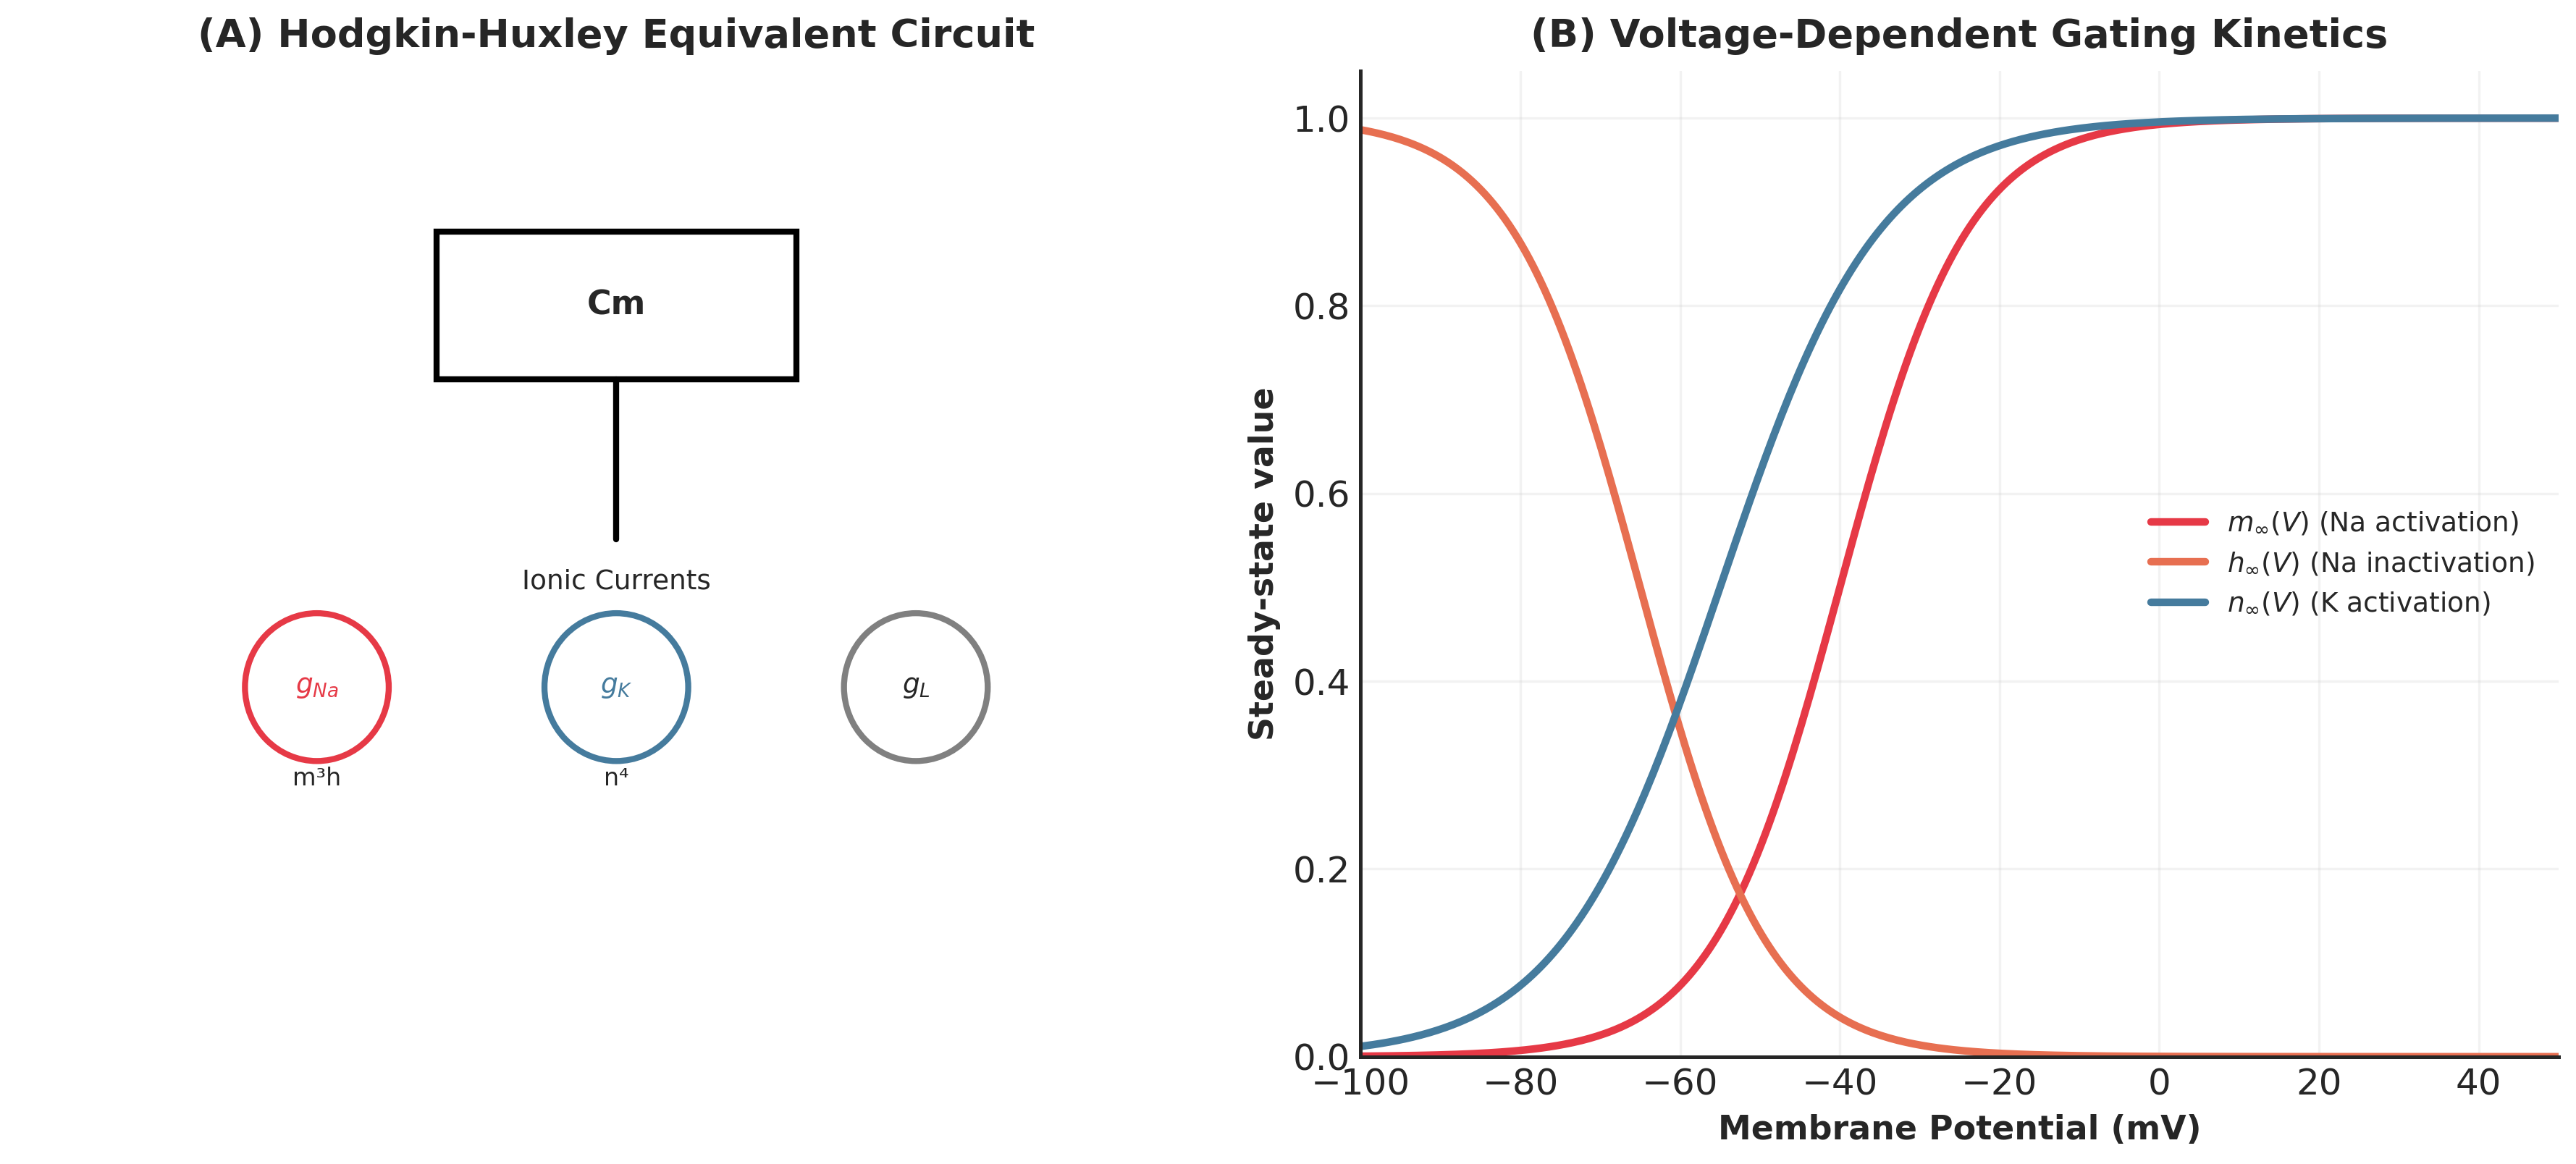

In [26]:
# Figure_4_1_HH_Circuit_Gating.py
set_thesis_style()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

# Left: Equivalent Circuit
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 8)
ax1.axis('off')
ax1.set_title('(A) Hodgkin-Huxley Equivalent Circuit', fontweight='bold', pad=8)

# Membrane capacitor
ax1.add_patch(Rectangle((3.5, 5.5), 3, 1.2, fill=False, edgecolor='black', lw=2))
ax1.text(5, 6.1, 'Cm', ha='center', va='center', fontsize=11, fontweight='bold')

# Ionic branches (simplified)
ax1.plot([5, 5], [5.5, 4.2], 'k-', lw=2)
ax1.text(5, 3.8, 'Ionic Currents', ha='center', fontsize=9)

# Na branch
ax1.add_patch(Circle((2.5, 3), 0.6, fill=False, edgecolor=cardiac_palette['excited'], lw=2))
ax1.text(2.5, 3, r'$g_{Na}$', ha='center', va='center', fontsize=9, color=cardiac_palette['excited'])
ax1.text(2.5, 2.2, 'm³h', ha='center', fontsize=8)

# K branch
ax1.add_patch(Circle((5, 3), 0.6, fill=False, edgecolor=cardiac_palette['recovery'], lw=2))
ax1.text(5, 3, r'$g_K$', ha='center', va='center', fontsize=9, color=cardiac_palette['recovery'])
ax1.text(5, 2.2, 'n⁴', ha='center', fontsize=8)

# Leak
ax1.add_patch(Circle((7.5, 3), 0.6, fill=False, edgecolor='gray', lw=2))
ax1.text(7.5, 3, r'$g_L$', ha='center', va='center', fontsize=9)

# Right: Gating Kinetics
ax2.set_title('(B) Voltage-Dependent Gating Kinetics', fontweight='bold', pad=8)
v = np.linspace(-100, 50, 300)
# Illustrative steady-state curves (Boltzmann-like)
m_inf = 1 / (1 + np.exp(-(v + 40)/8))
h_inf = 1 / (1 + np.exp((v + 65)/8))
n_inf = 1 / (1 + np.exp(-(v + 55)/10))

ax2.plot(v, m_inf, color=cardiac_palette['excited'], lw=2.5, label=r'$m_\infty(V)$ (Na activation)')
ax2.plot(v, h_inf, color='#E76F51', lw=2.5, label=r'$h_\infty(V)$ (Na inactivation)')
ax2.plot(v, n_inf, color=cardiac_palette['recovery'], lw=2.5, label=r'$n_\infty(V)$ (K activation)')

ax2.set_xlabel('Membrane Potential (mV)', fontweight='bold')
ax2.set_ylabel('Steady-state value', fontweight='bold')
ax2.legend(loc='center right', fontsize=9)
ax2.grid(True, alpha=0.25)
ax2.set_xlim(-100, 50)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('Figure_4_1_HH_Circuit_Gating.pdf', format='pdf')
print("Figure 4.1 saved.")

Figure 4.2 saved.


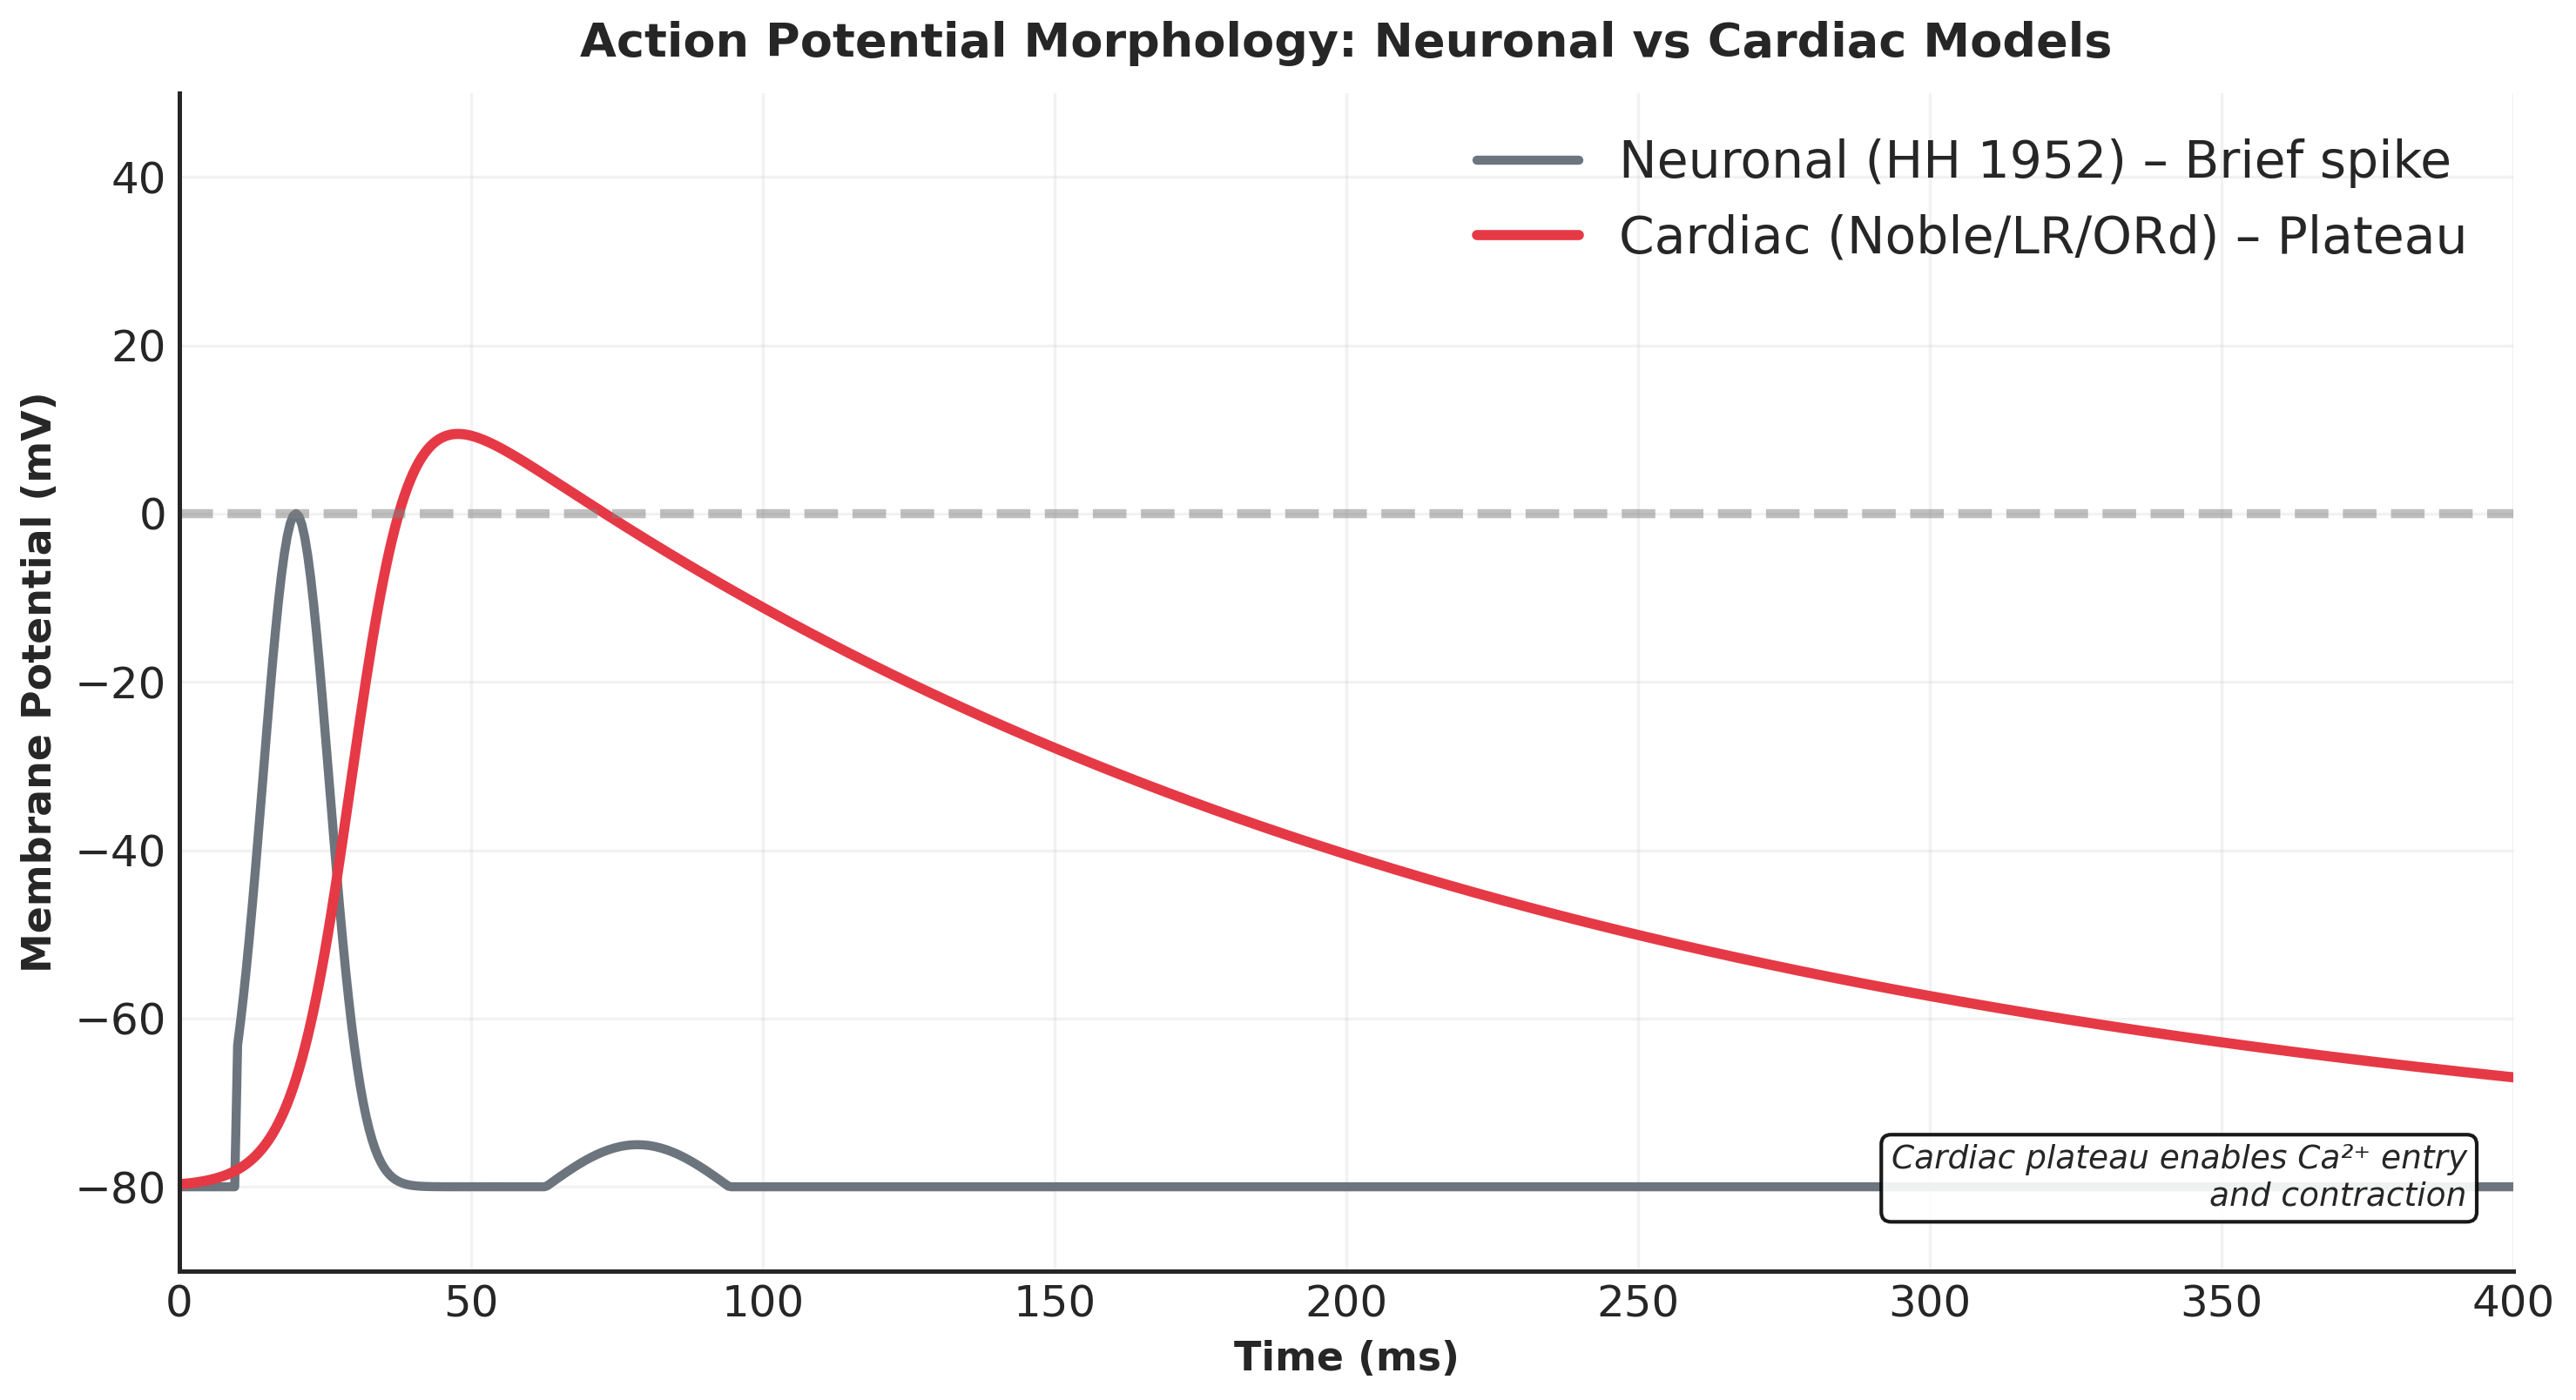

In [27]:
# Figure_4_2_AP_Comparison.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(10, 5.5))

t = np.linspace(0, 400, 800)

# Illustrative waveforms (normalized time)
# Neuronal HH-like (brief)
ap_neuronal = 80 * np.exp(-((t-20)/8)**2) * (t > 10) * (t < 60) + 5*np.sin(t/10)*(t>60)*(t<120) - 80
ap_neuronal = np.clip(ap_neuronal, -80, 40)

# Cardiac-like (plateau)
ap_cardiac = -80 + 120 / (1 + np.exp(-(t-30)/5)) * np.exp(-t/180)
ap_cardiac = np.clip(ap_cardiac, -80, 40)

ax.plot(t, ap_neuronal, color='#6C757D', lw=2.5, label='Neuronal (HH 1952) – Brief spike')
ax.plot(t, ap_cardiac, color=cardiac_palette['excited'], lw=2.8, label='Cardiac (Noble/LR/ORd) – Plateau')

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time (ms)', fontweight='bold')
ax.set_ylabel('Membrane Potential (mV)', fontweight='bold')
ax.set_title('Action Potential Morphology: Neuronal vs Cardiac Models', fontweight='bold', pad=10)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.25)
ax.set_xlim(0, 400)
ax.set_ylim(-90, 50)

ax.text(0.98, 0.05, 'Cardiac plateau enables Ca²⁺ entry\nand contraction', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=9, style='italic',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.savefig('Figure_4_2_AP_Comparison.pdf', format='pdf')
print("Figure 4.2 saved.")

Figure 4.3 saved.


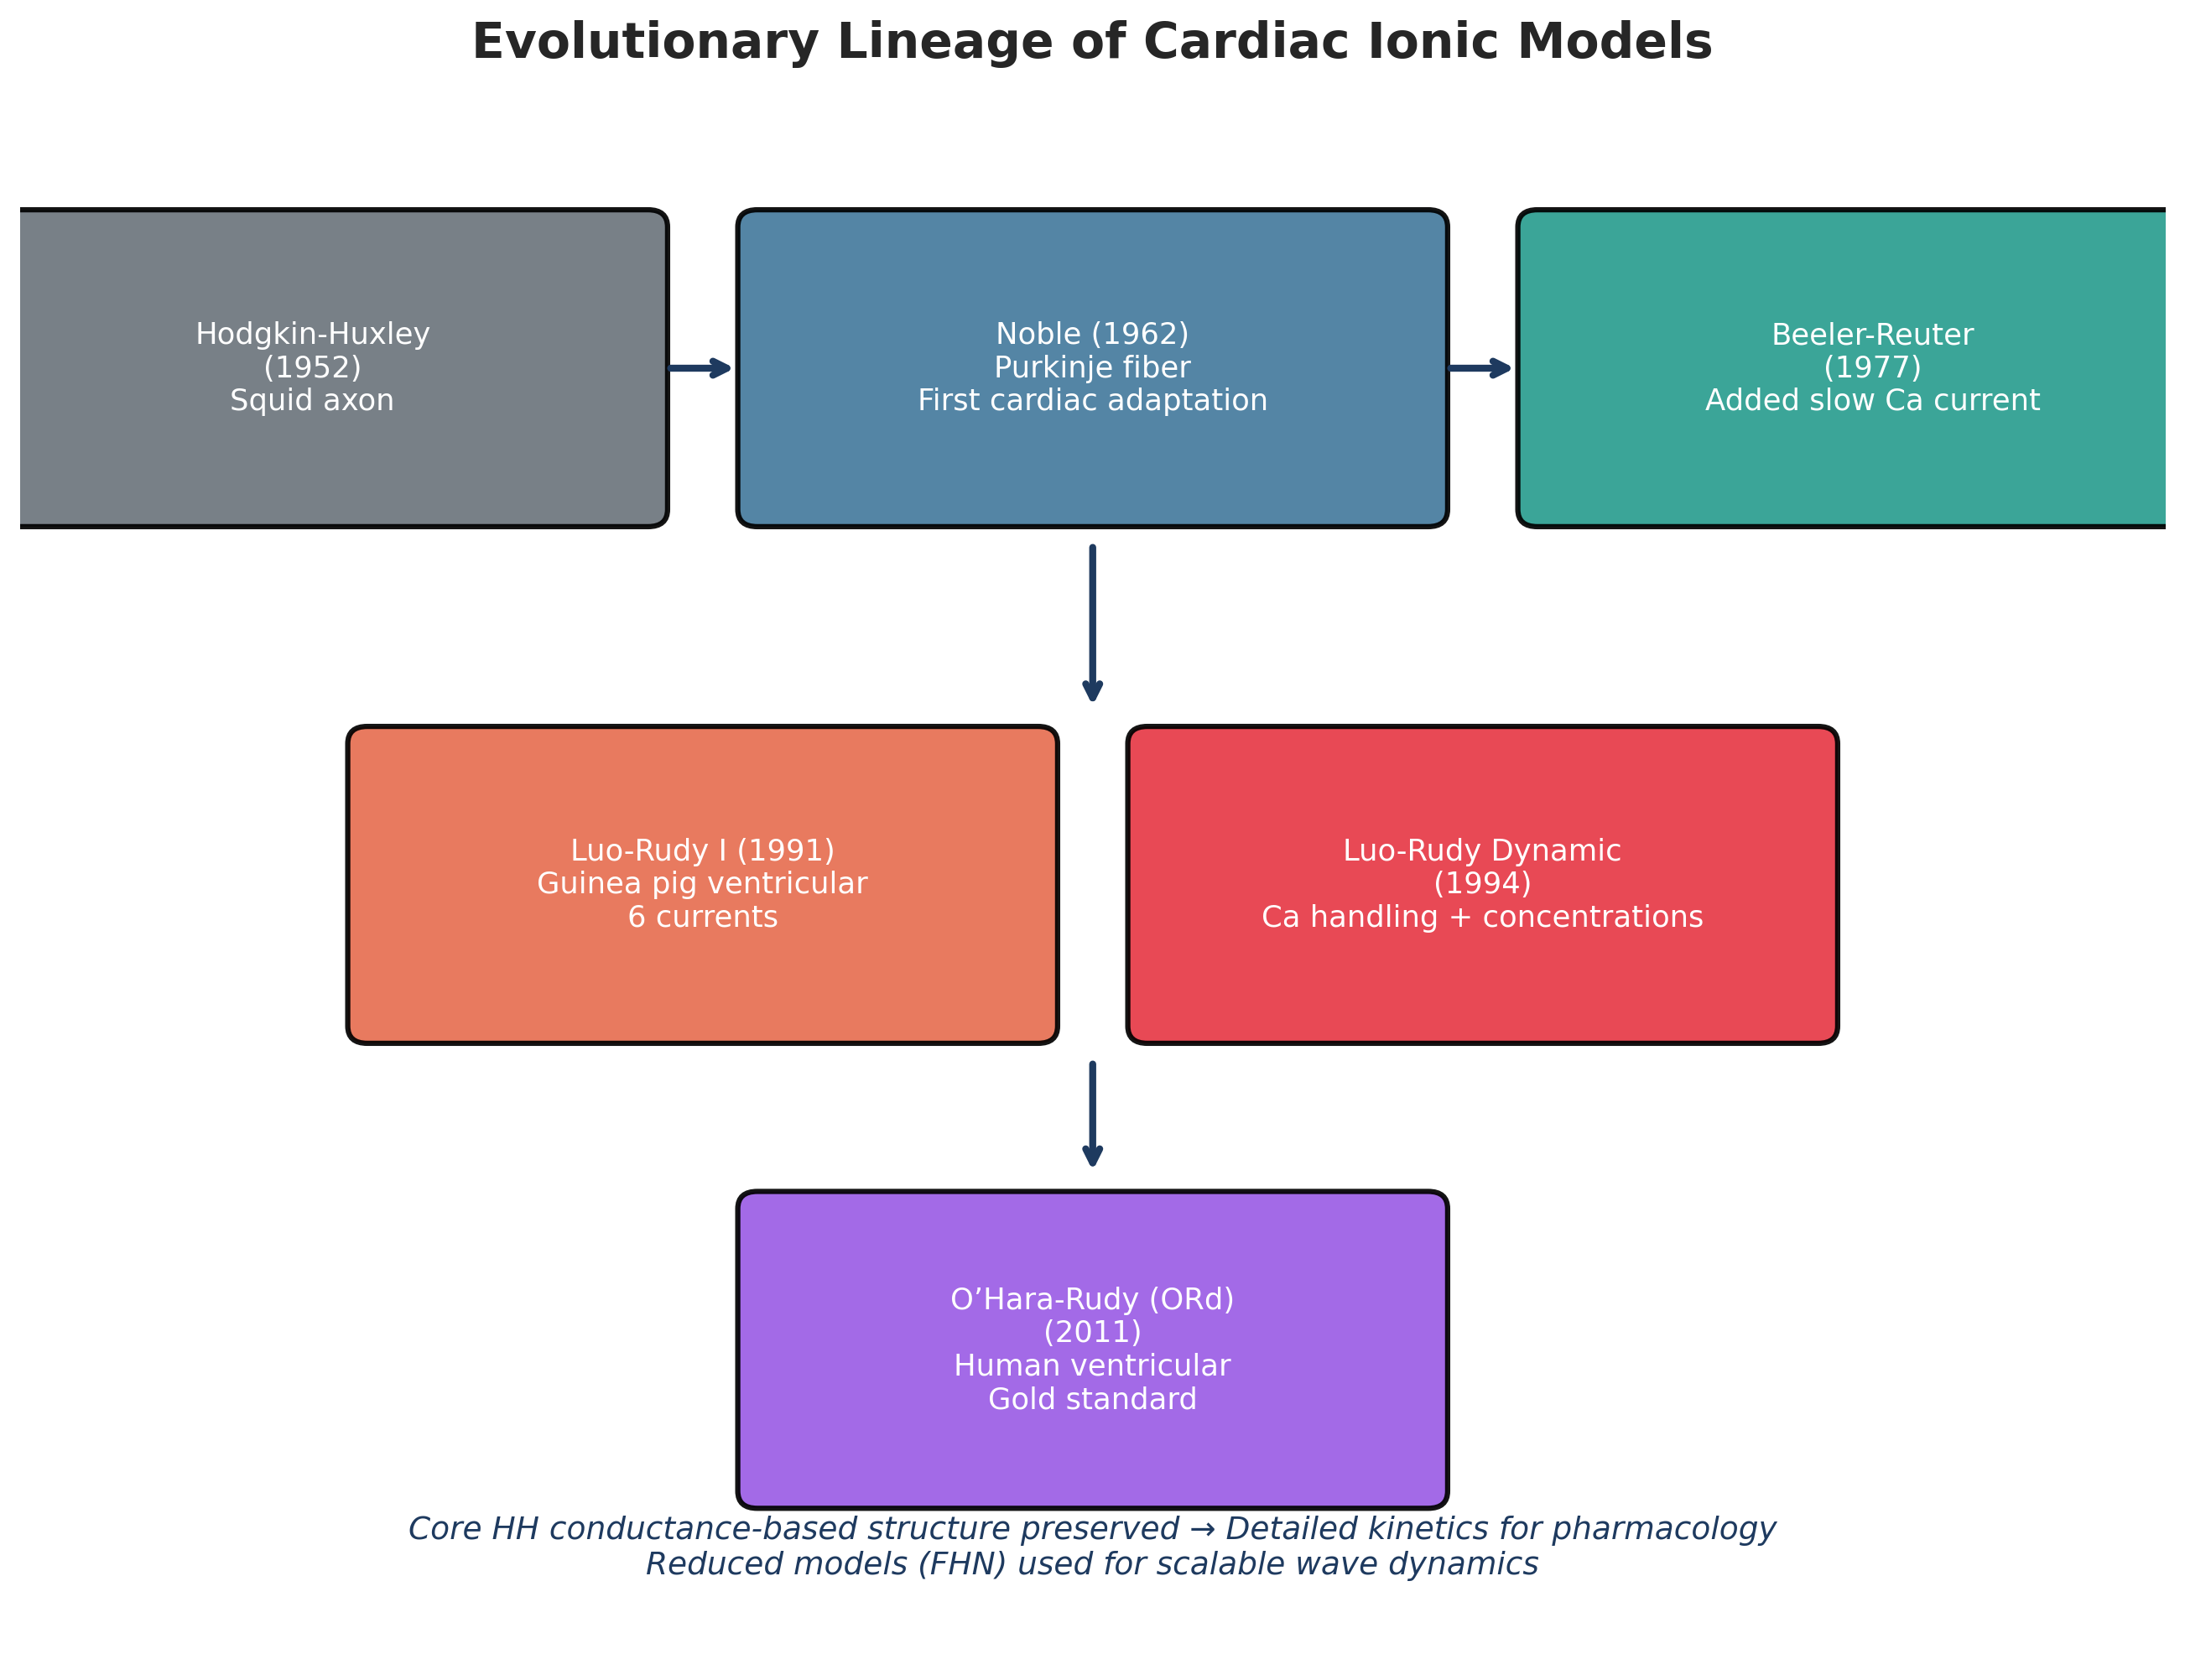

In [28]:
# Figure_4_3_Model_Lineage.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(11, 8))
ax.set_xlim(0, 11)
ax.set_ylim(0, 9)
ax.axis('off')
ax.set_title('Evolutionary Lineage of Cardiac Ionic Models', fontweight='bold', fontsize=14, pad=15)

models = [
    (1.5, 7.5, "Hodgkin-Huxley\n(1952)\nSquid axon", '#6C757D'),
    (5.5, 7.5, "Noble (1962)\nPurkinje fiber\nFirst cardiac adaptation", '#457B9D'),
    (9.5, 7.5, "Beeler-Reuter\n(1977)\nAdded slow Ca current", '#2A9D8F'),
    (3.5, 4.5, "Luo-Rudy I (1991)\nGuinea pig ventricular\n6 currents", '#E76F51'),
    (7.5, 4.5, "Luo-Rudy Dynamic\n(1994)\nCa handling + concentrations", '#E63946'),
    (5.5, 1.8, "O’Hara-Rudy (ORd)\n(2011)\nHuman ventricular\nGold standard", '#9B5DE5'),
]

for x, y, text, color in models:
    box = FancyBboxPatch((x-1.8, y-0.9), 3.6, 1.8, boxstyle="round,pad=0.02,rounding_size=0.1",
                         facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.92)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=8.5, color='white', fontweight='medium')

# Arrows showing progression
ax.annotate('', xy=(3.7, 7.5), xytext=(3.3, 7.5), arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=2))
ax.annotate('', xy=(7.7, 7.5), xytext=(7.3, 7.5), arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=2))
ax.annotate('', xy=(5.5, 5.5), xytext=(5.5, 6.5), arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=2))
ax.annotate('', xy=(5.5, 2.8), xytext=(5.5, 3.5), arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=2))

ax.text(5.5, 0.5, 'Core HH conductance-based structure preserved → Detailed kinetics for pharmacology\nReduced models (FHN) used for scalable wave dynamics',
        ha='center', fontsize=9, style='italic', color='#1E3A5F')

plt.savefig('Figure_4_3_Model_Lineage.pdf', format='pdf')
print("Figure 4.3 saved.")

Figure 4.4 saved.


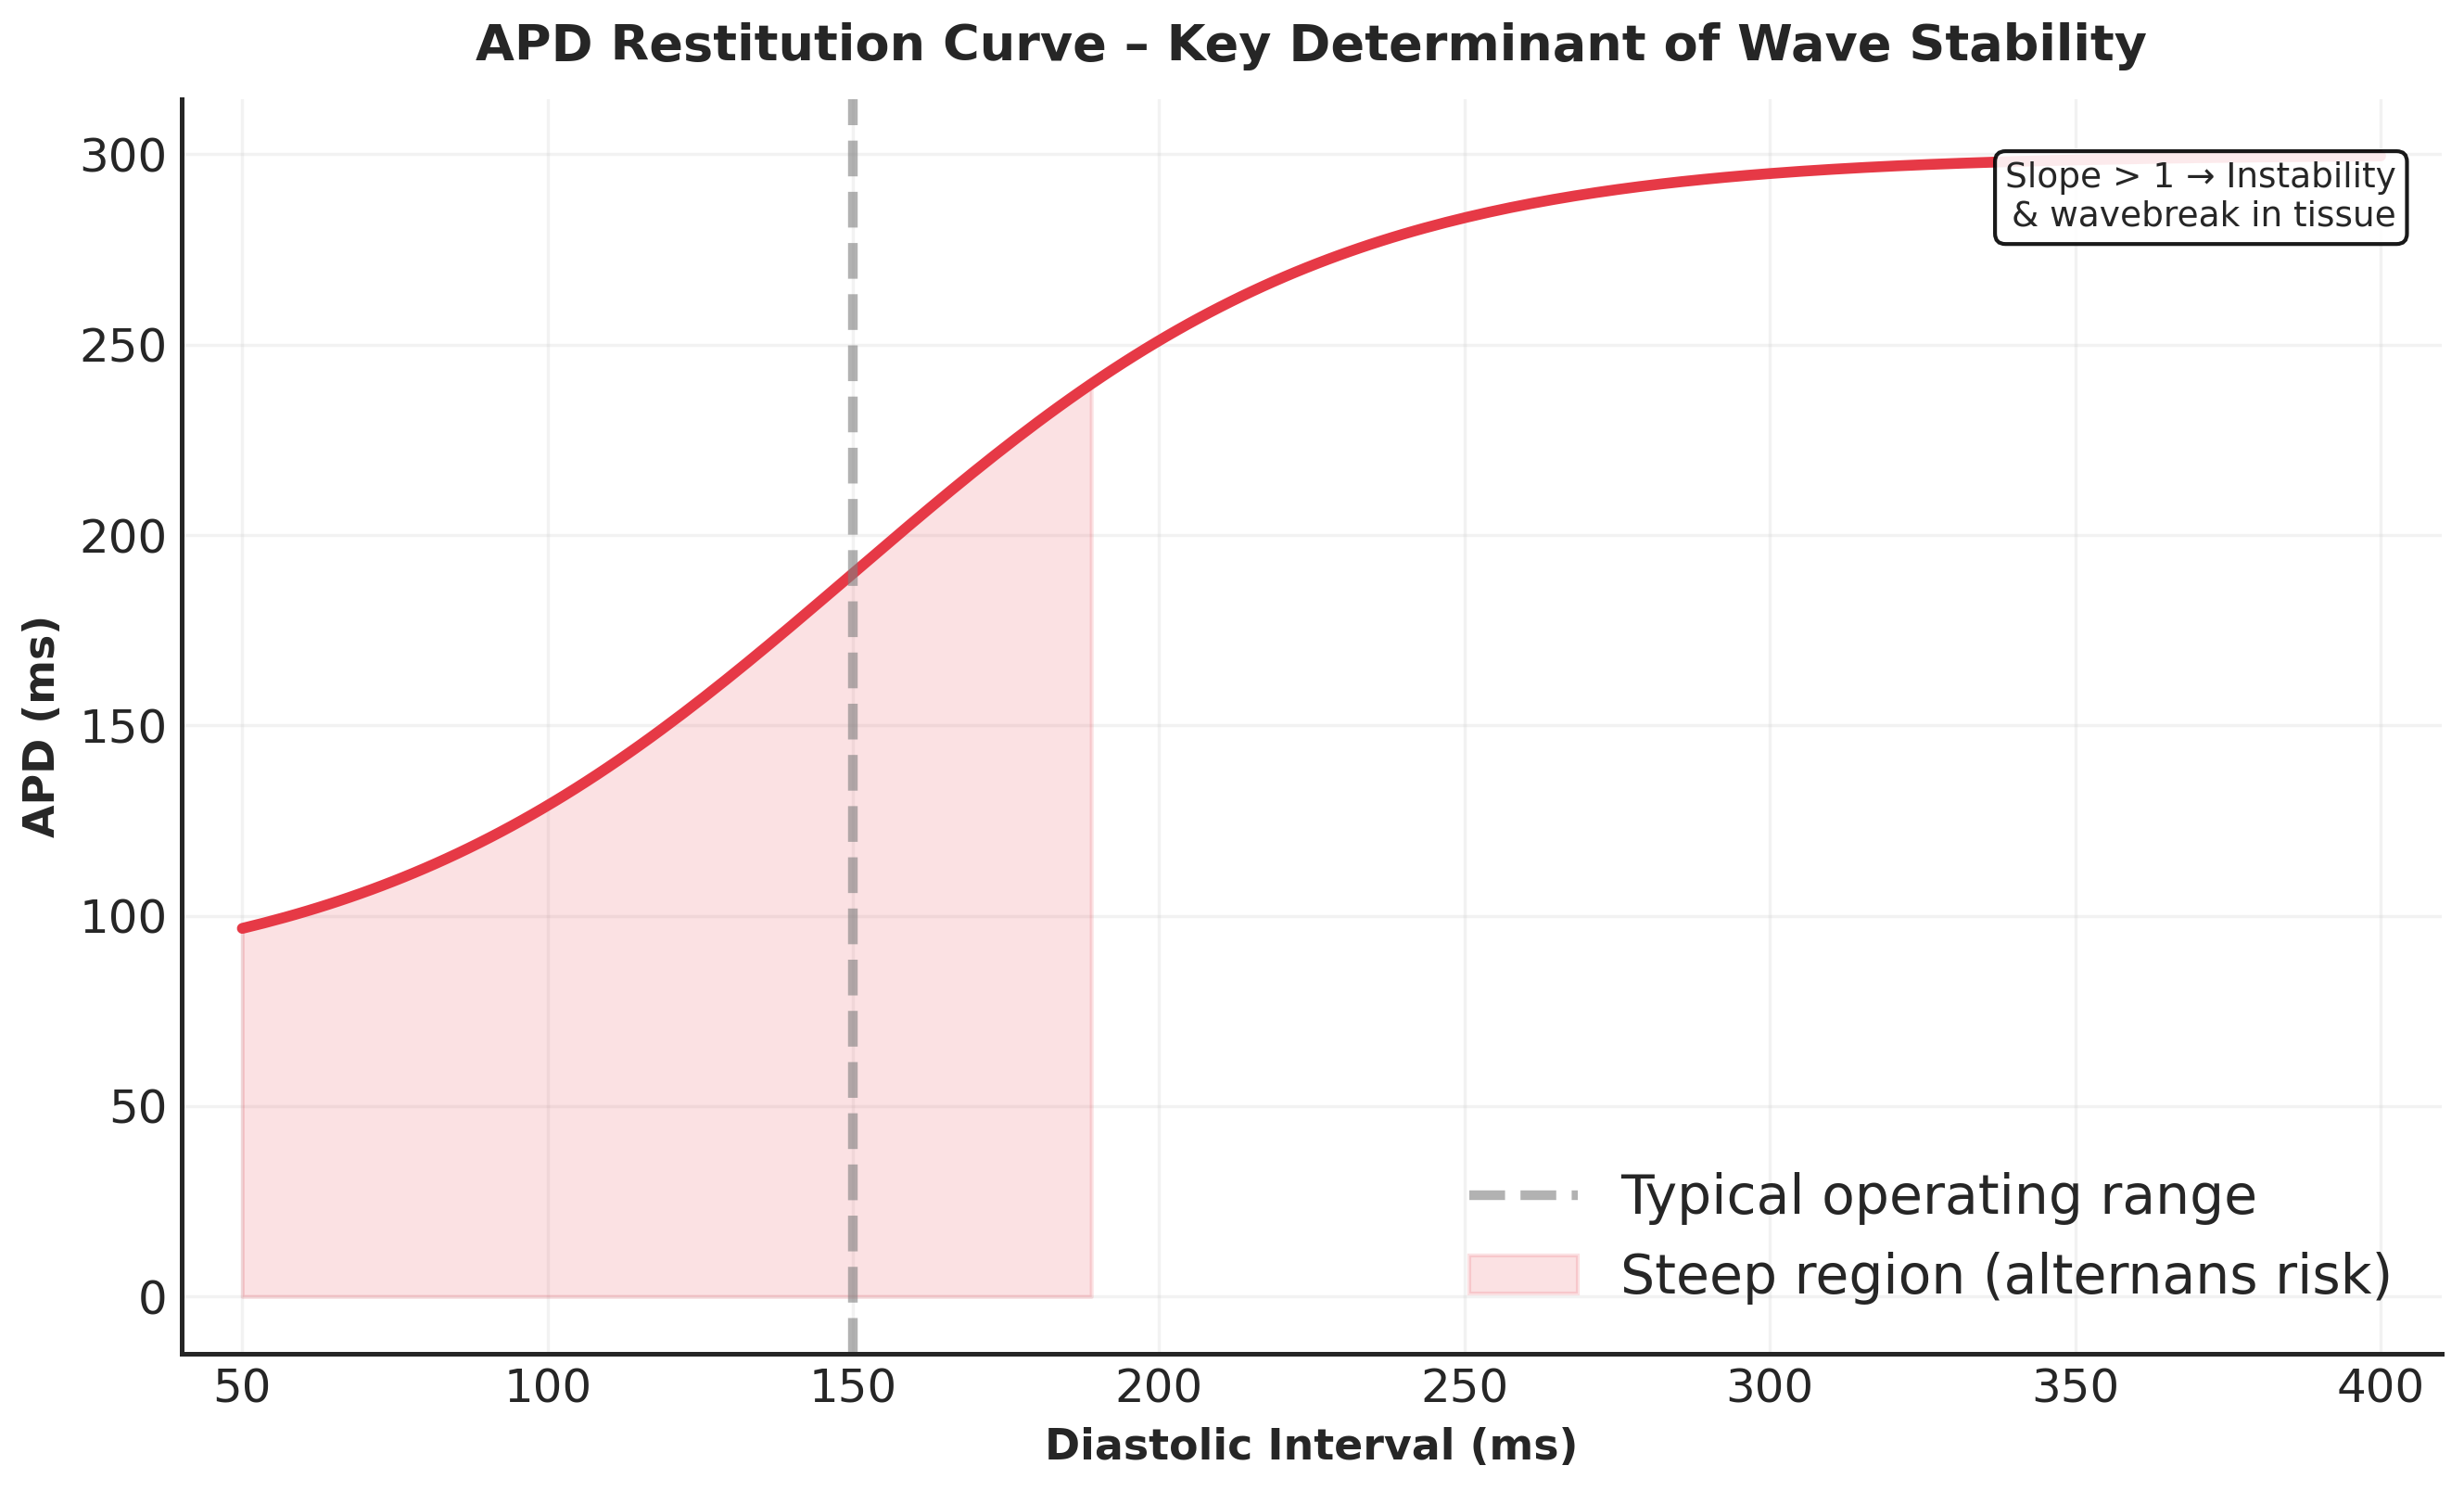

In [29]:
# Figure_4_4_Restitution_Curve.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(9, 5.5))

DI = np.linspace(50, 400, 200)
# Illustrative steep restitution (typical cardiac)
APD = 80 + 220 / (1 + np.exp(-(DI - 150)/40))

ax.plot(DI, APD, color=cardiac_palette['excited'], lw=2.8)
ax.axvline(x=150, color='gray', linestyle='--', alpha=0.6, label='Typical operating range')
ax.fill_between(DI[:80], APD[:80], alpha=0.15, color='#E63946', label='Steep region (alternans risk)')

ax.set_xlabel('Diastolic Interval (ms)', fontweight='bold')
ax.set_ylabel('APD (ms)', fontweight='bold')
ax.set_title('APD Restitution Curve – Key Determinant of Wave Stability', fontweight='bold', pad=10)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.25)
ax.set_xlim(40, 410)

ax.text(0.98, 0.95, 'Slope > 1 → Instability\n& wavebreak in tissue', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.savefig('Figure_4_4_Restitution_Curve.pdf', format='pdf')
print("Figure 4.4 saved.")

Figure 4.5 saved.


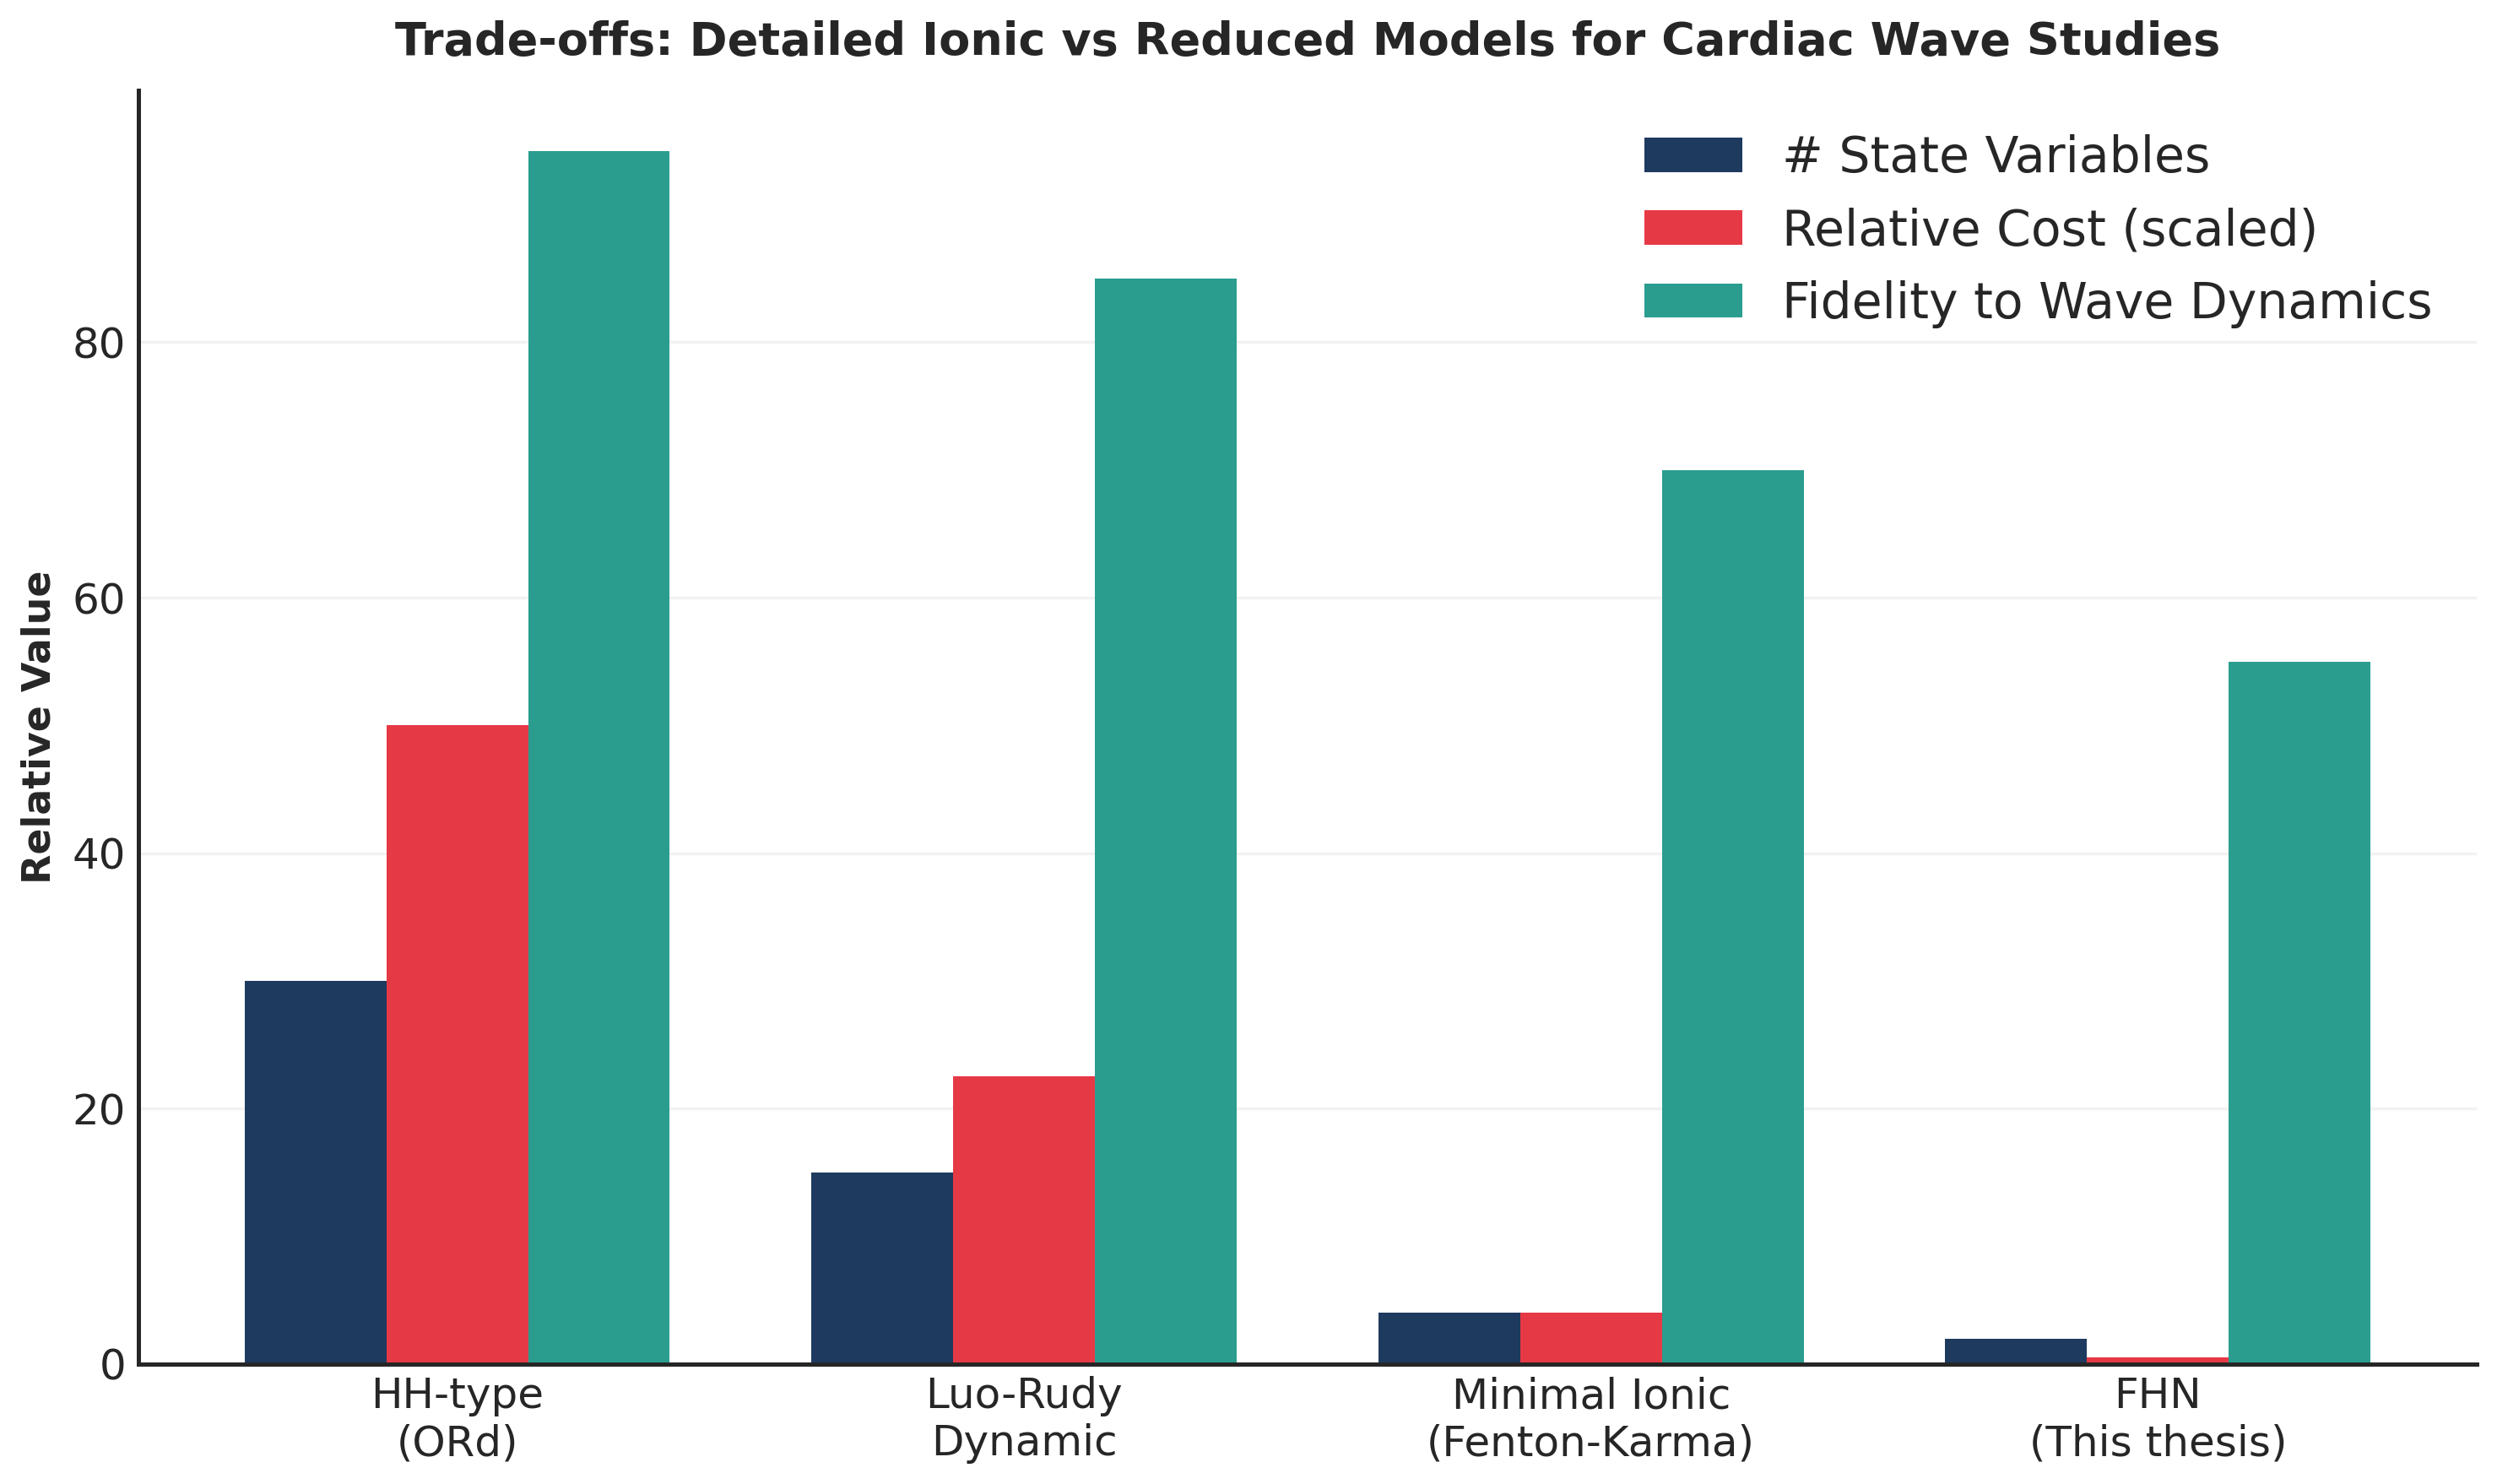

In [30]:
# Figure_4_5_Complexity_Comparison.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['HH-type\n(ORd)', 'Luo-Rudy\nDynamic', 'Minimal Ionic\n(Fenton-Karma)', 'FHN\n(This thesis)']
variables = [30, 15, 4, 2]
cost = [100, 45, 8, 1]          # relative computational cost
fidelity = [95, 85, 70, 55]     # conceptual fidelity to wave dynamics

x = np.arange(len(categories))
width = 0.25

bars1 = ax.bar(x - width, variables, width, label='# State Variables', color=cardiac_palette['primary'])
bars2 = ax.bar(x, [c/2 for c in cost], width, label='Relative Cost (scaled)', color=cardiac_palette['excited'])
bars3 = ax.bar(x + width, fidelity, width, label='Fidelity to Wave Dynamics', color=cardiac_palette['accent'])

ax.set_ylabel('Relative Value', fontweight='bold')
ax.set_title('Trade-offs: Detailed Ionic vs Reduced Models for Cardiac Wave Studies', fontweight='bold', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('Figure_4_5_Complexity_Comparison.pdf', format='pdf')
print("Figure 4.5 saved.")

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import seaborn as sns

def set_thesis_style():
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
        'font.size': 10,
        'axes.labelsize': 11,
        'axes.titlesize': 13,
        'figure.titlesize': 14,
        'axes.linewidth': 1.2,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.08,
    })

cardiac_palette = {
    'primary': '#1E3A5F',
    'excited': '#E63946',
    'recovery': '#457B9D',
    'accent': '#2A9D8F',
    'feedback': '#9B5DE5',
    'light': '#F8F9FA',
}

Figure 5.1 saved.


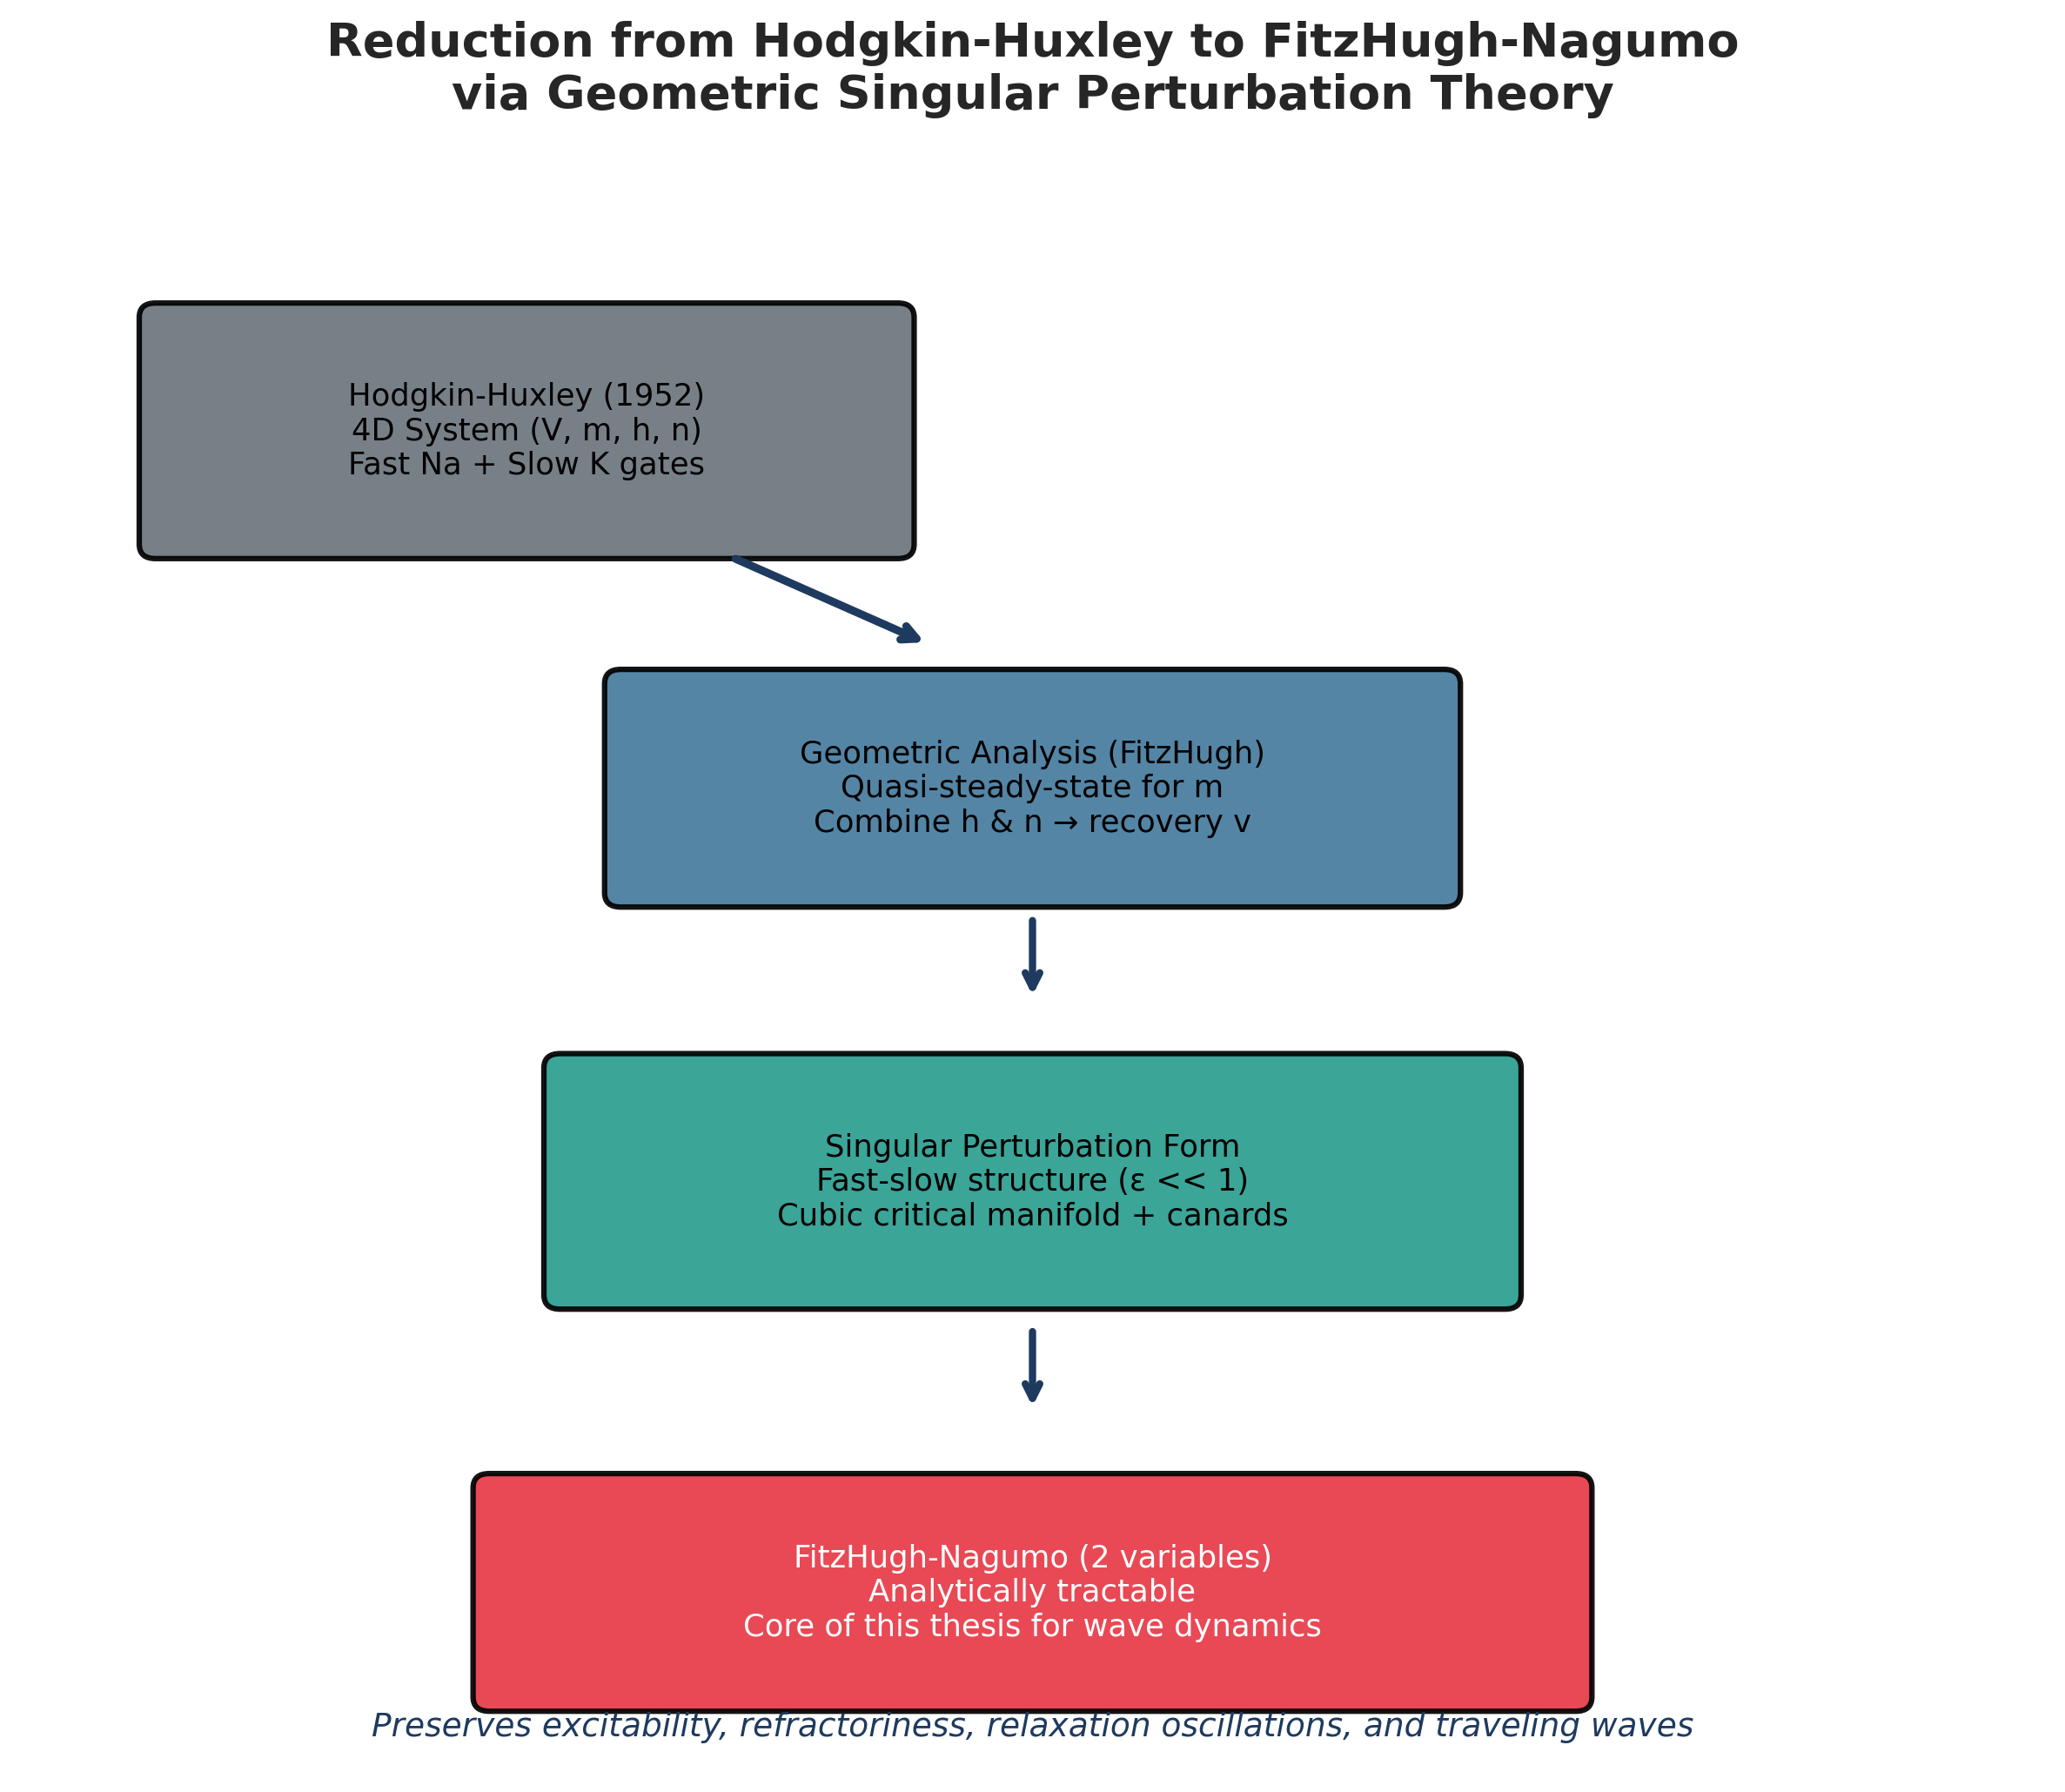

In [32]:
# Figure_5_1_HH_to_FHN_Reduction.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 9)
ax.axis('off')
ax.set_title('Reduction from Hodgkin-Huxley to FitzHugh-Nagumo\nvia Geometric Singular Perturbation Theory', fontweight='bold', pad=15)

def add_box(ax, x, y, w, h, text, color, fontsize=8.5):
    box = FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle="round,pad=0.015,rounding_size=0.08",
                         facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.92)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, wrap=True,
            color='white' if color in ['#1E3A5F', '#E63946'] else 'black', fontweight='medium')

# HH box
add_box(ax, 2.5, 7.5, 3.8, 1.4, "Hodgkin-Huxley (1952)\n4D System (V, m, h, n)\nFast Na + Slow K gates", '#6C757D')

# Arrow
ax.annotate('', xy=(4.5, 6.3), xytext=(3.5, 6.8),
            arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=2.2))

# Reduction steps
add_box(ax, 5, 5.5, 4.2, 1.3, "Geometric Analysis (FitzHugh)\nQuasi-steady-state for m\nCombine h & n → recovery v", '#457B9D')

ax.annotate('', xy=(5, 4.3), xytext=(5, 4.8),
            arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=2))

add_box(ax, 5, 3.3, 4.8, 1.4, "Singular Perturbation Form\nFast-slow structure (ε << 1)\nCubic critical manifold + canards", '#2A9D8F')

ax.annotate('', xy=(5, 2.0), xytext=(5, 2.5),
            arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=2))

add_box(ax, 5, 1.0, 5.5, 1.3, "FitzHugh-Nagumo (2 variables)\nAnalytically tractable\nCore of this thesis for wave dynamics", '#E63946')

ax.text(5, 0.2, 'Preserves excitability, refractoriness, relaxation oscillations, and traveling waves',
        ha='center', fontsize=9, style='italic', color='#1E3A5F')

plt.savefig('Figure_5_1_HH_to_FHN_Reduction.pdf', format='pdf')
print("Figure 5.1 saved.")

Figure 5.2 saved.


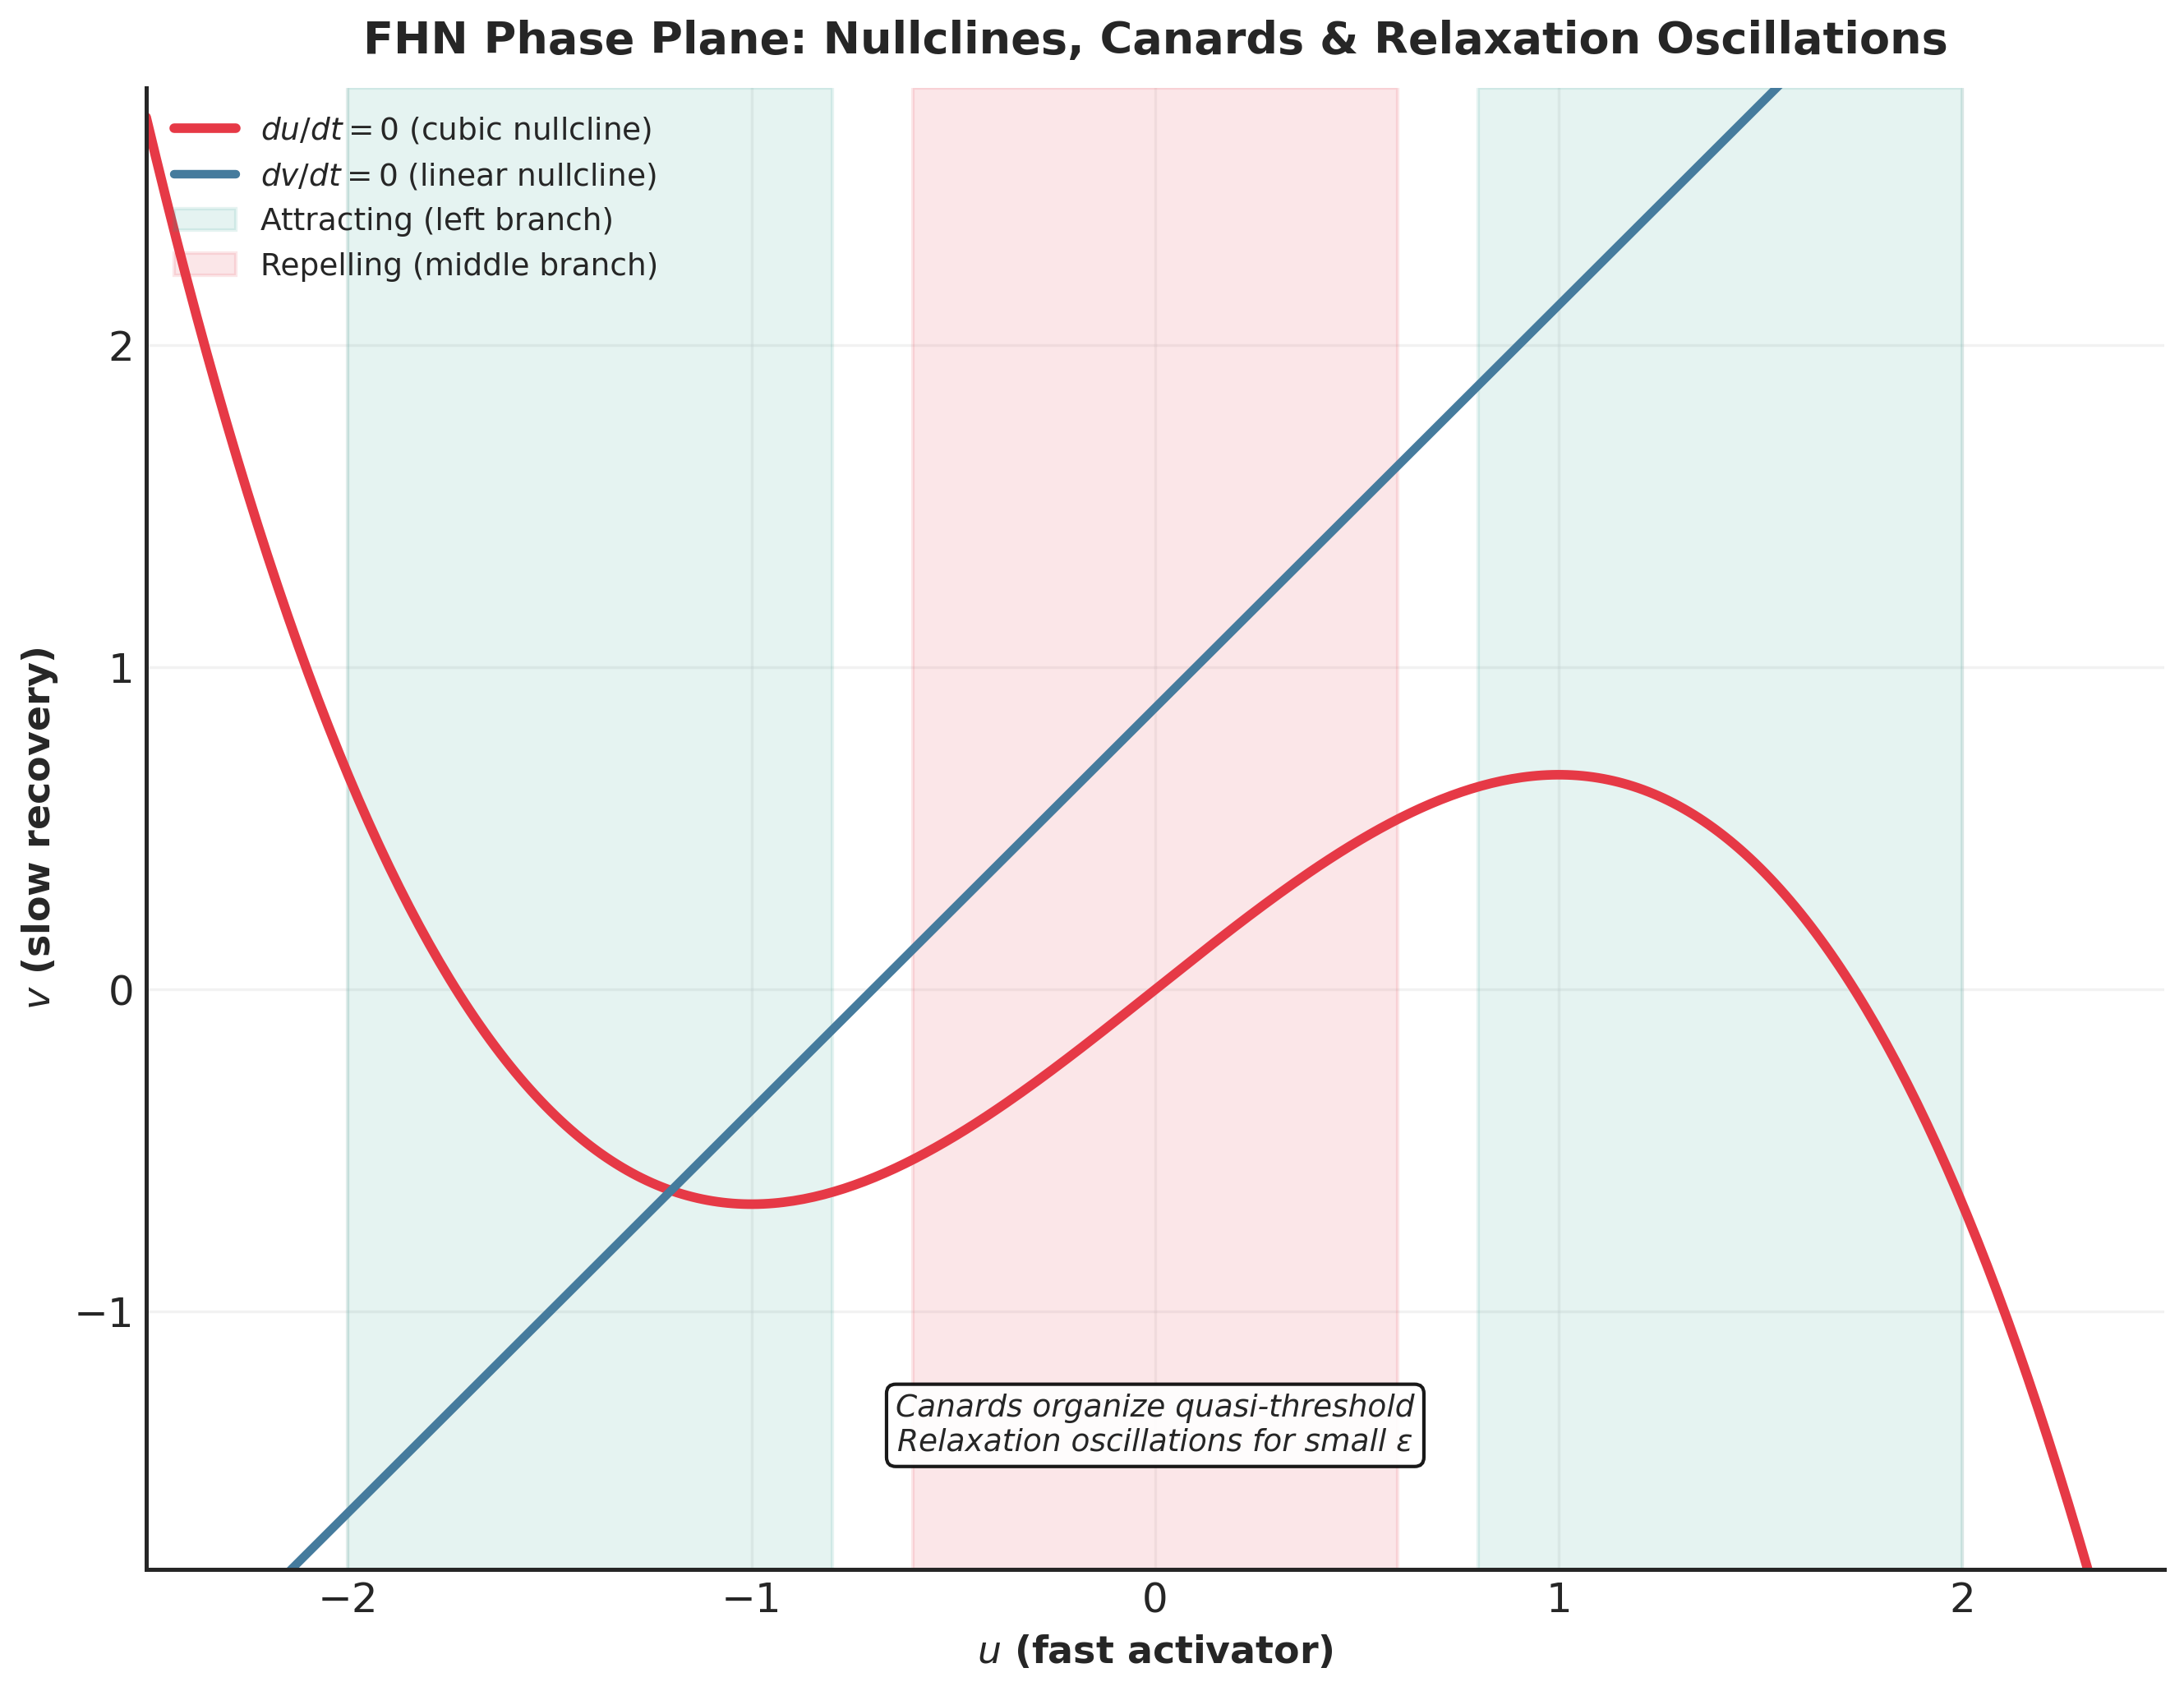

In [33]:
# Figure_5_2_FHN_Phase_Plane_Canards.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(9, 7))

u = np.linspace(-2.5, 2.5, 400)
v_cubic = u - (u**3)/3          # u-nullcline (cubic)
v_linear = (u + 0.7)/0.8        # v-nullcline (typical parameters)

ax.plot(u, v_cubic, color=cardiac_palette['excited'], lw=2.8, label=r'$du/dt = 0$ (cubic nullcline)')
ax.plot(u, v_linear, color=cardiac_palette['recovery'], lw=2.5, label=r'$dv/dt = 0$ (linear nullcline)')

# Highlight attracting/repelling branches
ax.axvspan(-2.0, -0.8, alpha=0.12, color='#2A9D8F', label='Attracting (left branch)')
ax.axvspan(0.8, 2.0, alpha=0.12, color='#2A9D8F')
ax.axvspan(-0.6, 0.6, alpha=0.12, color='#E63946', label='Repelling (middle branch)')

ax.set_xlabel(r'$u$ (fast activator)', fontweight='bold')
ax.set_ylabel(r'$v$ (slow recovery)', fontweight='bold')
ax.set_title('FHN Phase Plane: Nullclines, Canards & Relaxation Oscillations', fontweight='bold', pad=10)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.25)
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-1.8, 2.8)

ax.text(0.5, 0.08, 'Canards organize quasi-threshold\nRelaxation oscillations for small ε',
        transform=ax.transAxes, ha='center', fontsize=9, style='italic',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.savefig('Figure_5_2_FHN_Phase_Plane_Canards.pdf', format='pdf')
print("Figure 5.2 saved.")

Figure 5.3 saved.


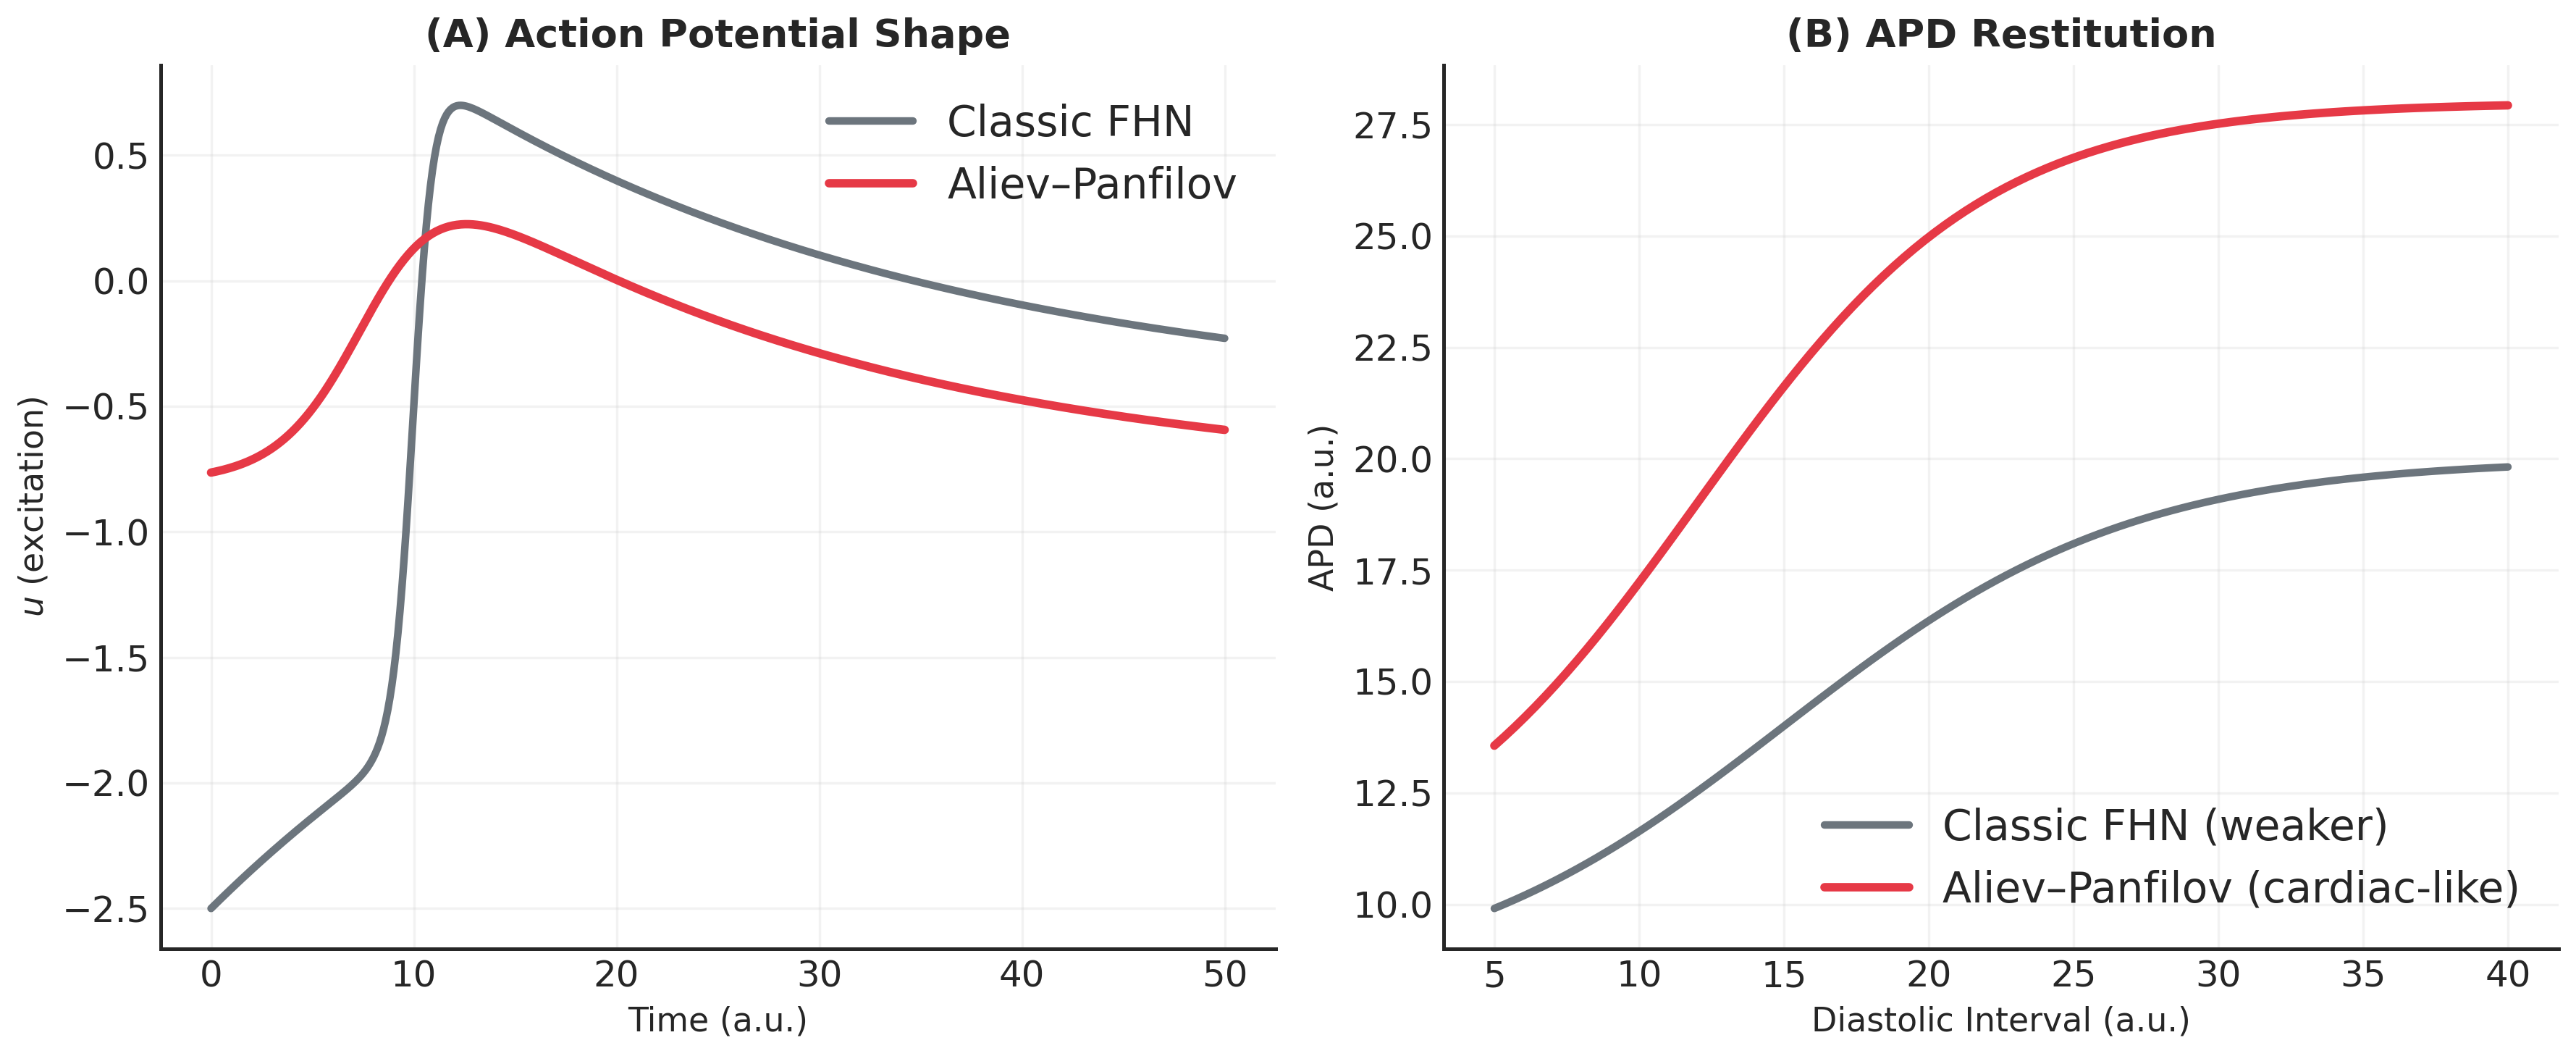

In [34]:
# Figure_5_3_Aliev_Panfilov_Comparison.py
set_thesis_style()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

t = np.linspace(0, 50, 500)

# Classic FHN (illustrative)
u_fhn = np.tanh(t-10) * np.exp(-t/25) * 2 - 0.5
v_fhn = 0.3 * (1 - np.exp(-t/30))

# Aliev-Panfilov style (more plateau-like)
u_ap = 2 / (1 + np.exp(-(t-8)/2)) * np.exp(-t/22) - 0.8
v_ap = 0.25 * (1 - np.exp(-t/18))

ax1.plot(t, u_fhn, color='#6C757D', lw=2.5, label='Classic FHN')
ax1.plot(t, u_ap, color=cardiac_palette['excited'], lw=2.8, label='Aliev–Panfilov')
ax1.set_xlabel('Time (a.u.)')
ax1.set_ylabel(r'$u$ (excitation)')
ax1.set_title('(A) Action Potential Shape', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.25)

# Restitution (illustrative)
DI = np.linspace(5, 40, 100)
restitution_fhn = 8 + 12 / (1 + np.exp(-(DI-15)/6))
restitution_ap = 10 + 18 / (1 + np.exp(-(DI-12)/5))

ax2.plot(DI, restitution_fhn, color='#6C757D', lw=2.5, label='Classic FHN (weaker)')
ax2.plot(DI, restitution_ap, color=cardiac_palette['excited'], lw=2.8, label='Aliev–Panfilov (cardiac-like)')
ax2.set_xlabel('Diastolic Interval (a.u.)')
ax2.set_ylabel('APD (a.u.)')
ax2.set_title('(B) APD Restitution', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('Figure_5_3_Aliev_Panfilov_Comparison.pdf', format='pdf')
print("Figure 5.3 saved.")

Figure 5.4 saved.


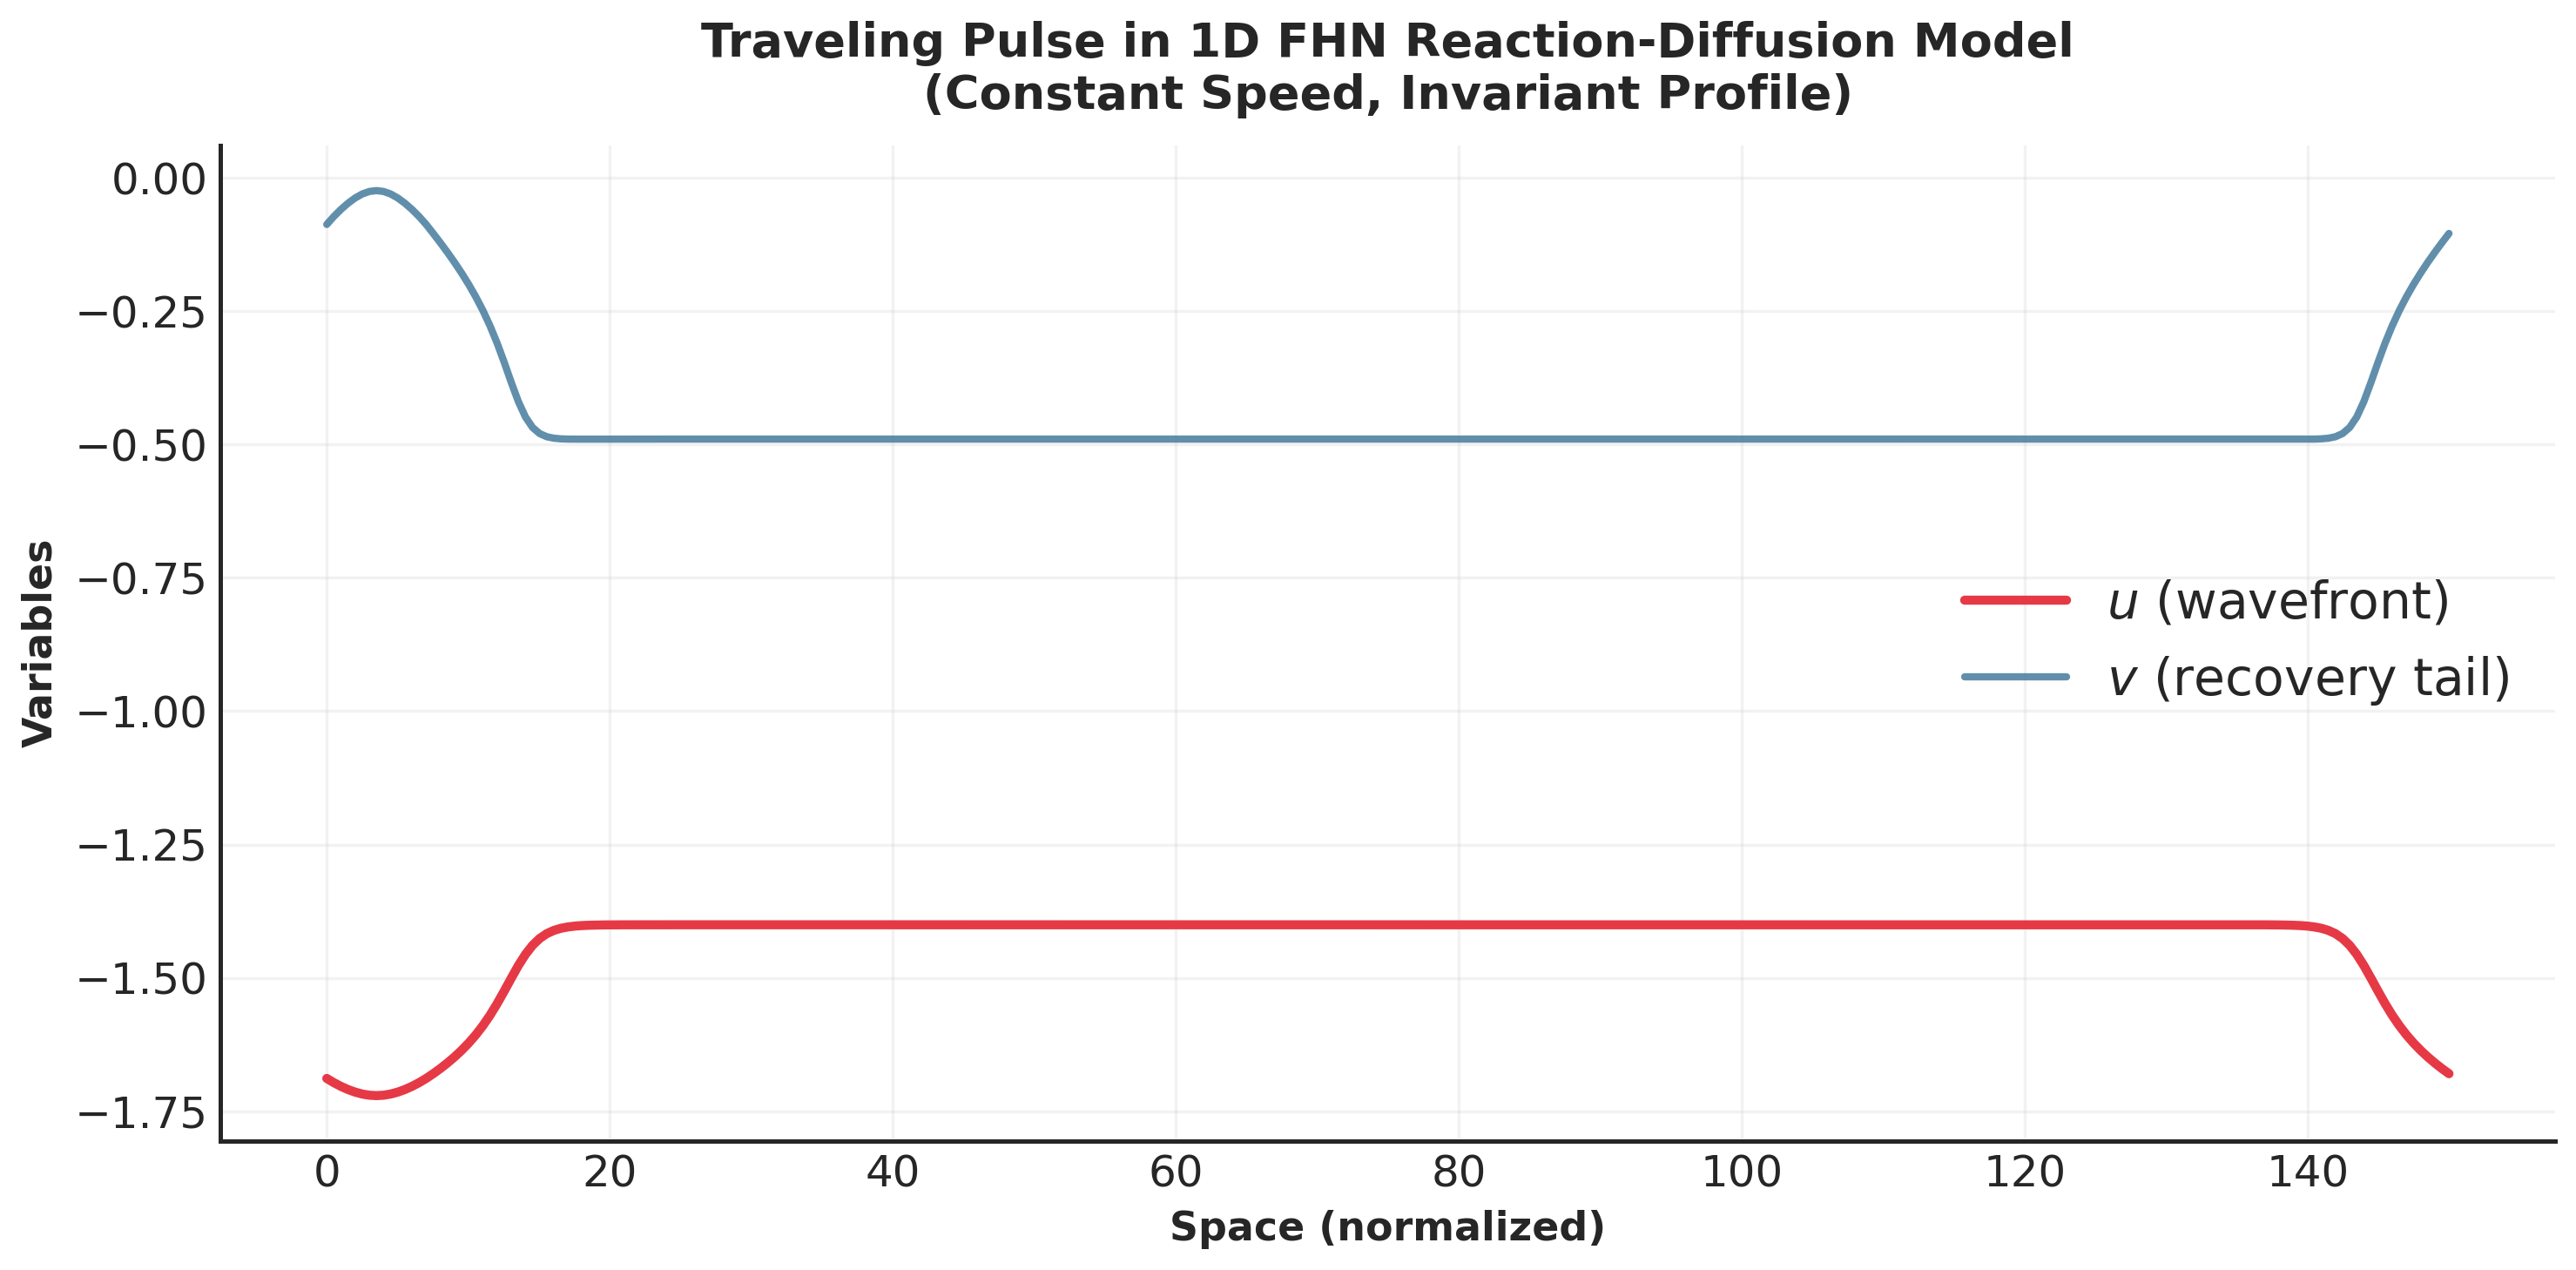

In [35]:
# Figure_5_4_Traveling_Pulse_RD.py
set_thesis_style()

# Reuse 1D simulation from previous chapters (simplified here)
L = 150
dx = 0.5
dt = 0.01
D = 1.0
a, b, eps = 0.7, 0.8, 0.015
Nx = int(L/dx)
u = np.zeros(Nx)
v = np.zeros(Nx)
u[:15] = 1.0

def lap_1d(Z):
    return (np.roll(Z,1) + np.roll(Z,-1) - 2*Z) / dx**2

for _ in range(6000):
    du = u - u**3/3 - v + D*lap_1d(u)
    dv = eps*(u + a - b*v)
    u += du*dt
    v += dv*dt

fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(0, L, Nx)
ax.plot(x, u, color=cardiac_palette['excited'], lw=2.5, label=r'$u$ (wavefront)')
ax.plot(x, v, color=cardiac_palette['recovery'], lw=2.0, label=r'$v$ (recovery tail)', alpha=0.85)
ax.set_xlabel('Space (normalized)', fontweight='bold')
ax.set_ylabel('Variables', fontweight='bold')
ax.set_title('Traveling Pulse in 1D FHN Reaction-Diffusion Model\n(Constant Speed, Invariant Profile)', fontweight='bold', pad=10)
ax.legend()
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('Figure_5_4_Traveling_Pulse_RD.pdf', format='pdf')
print("Figure 5.4 saved.")

Figure 5.5 saved.


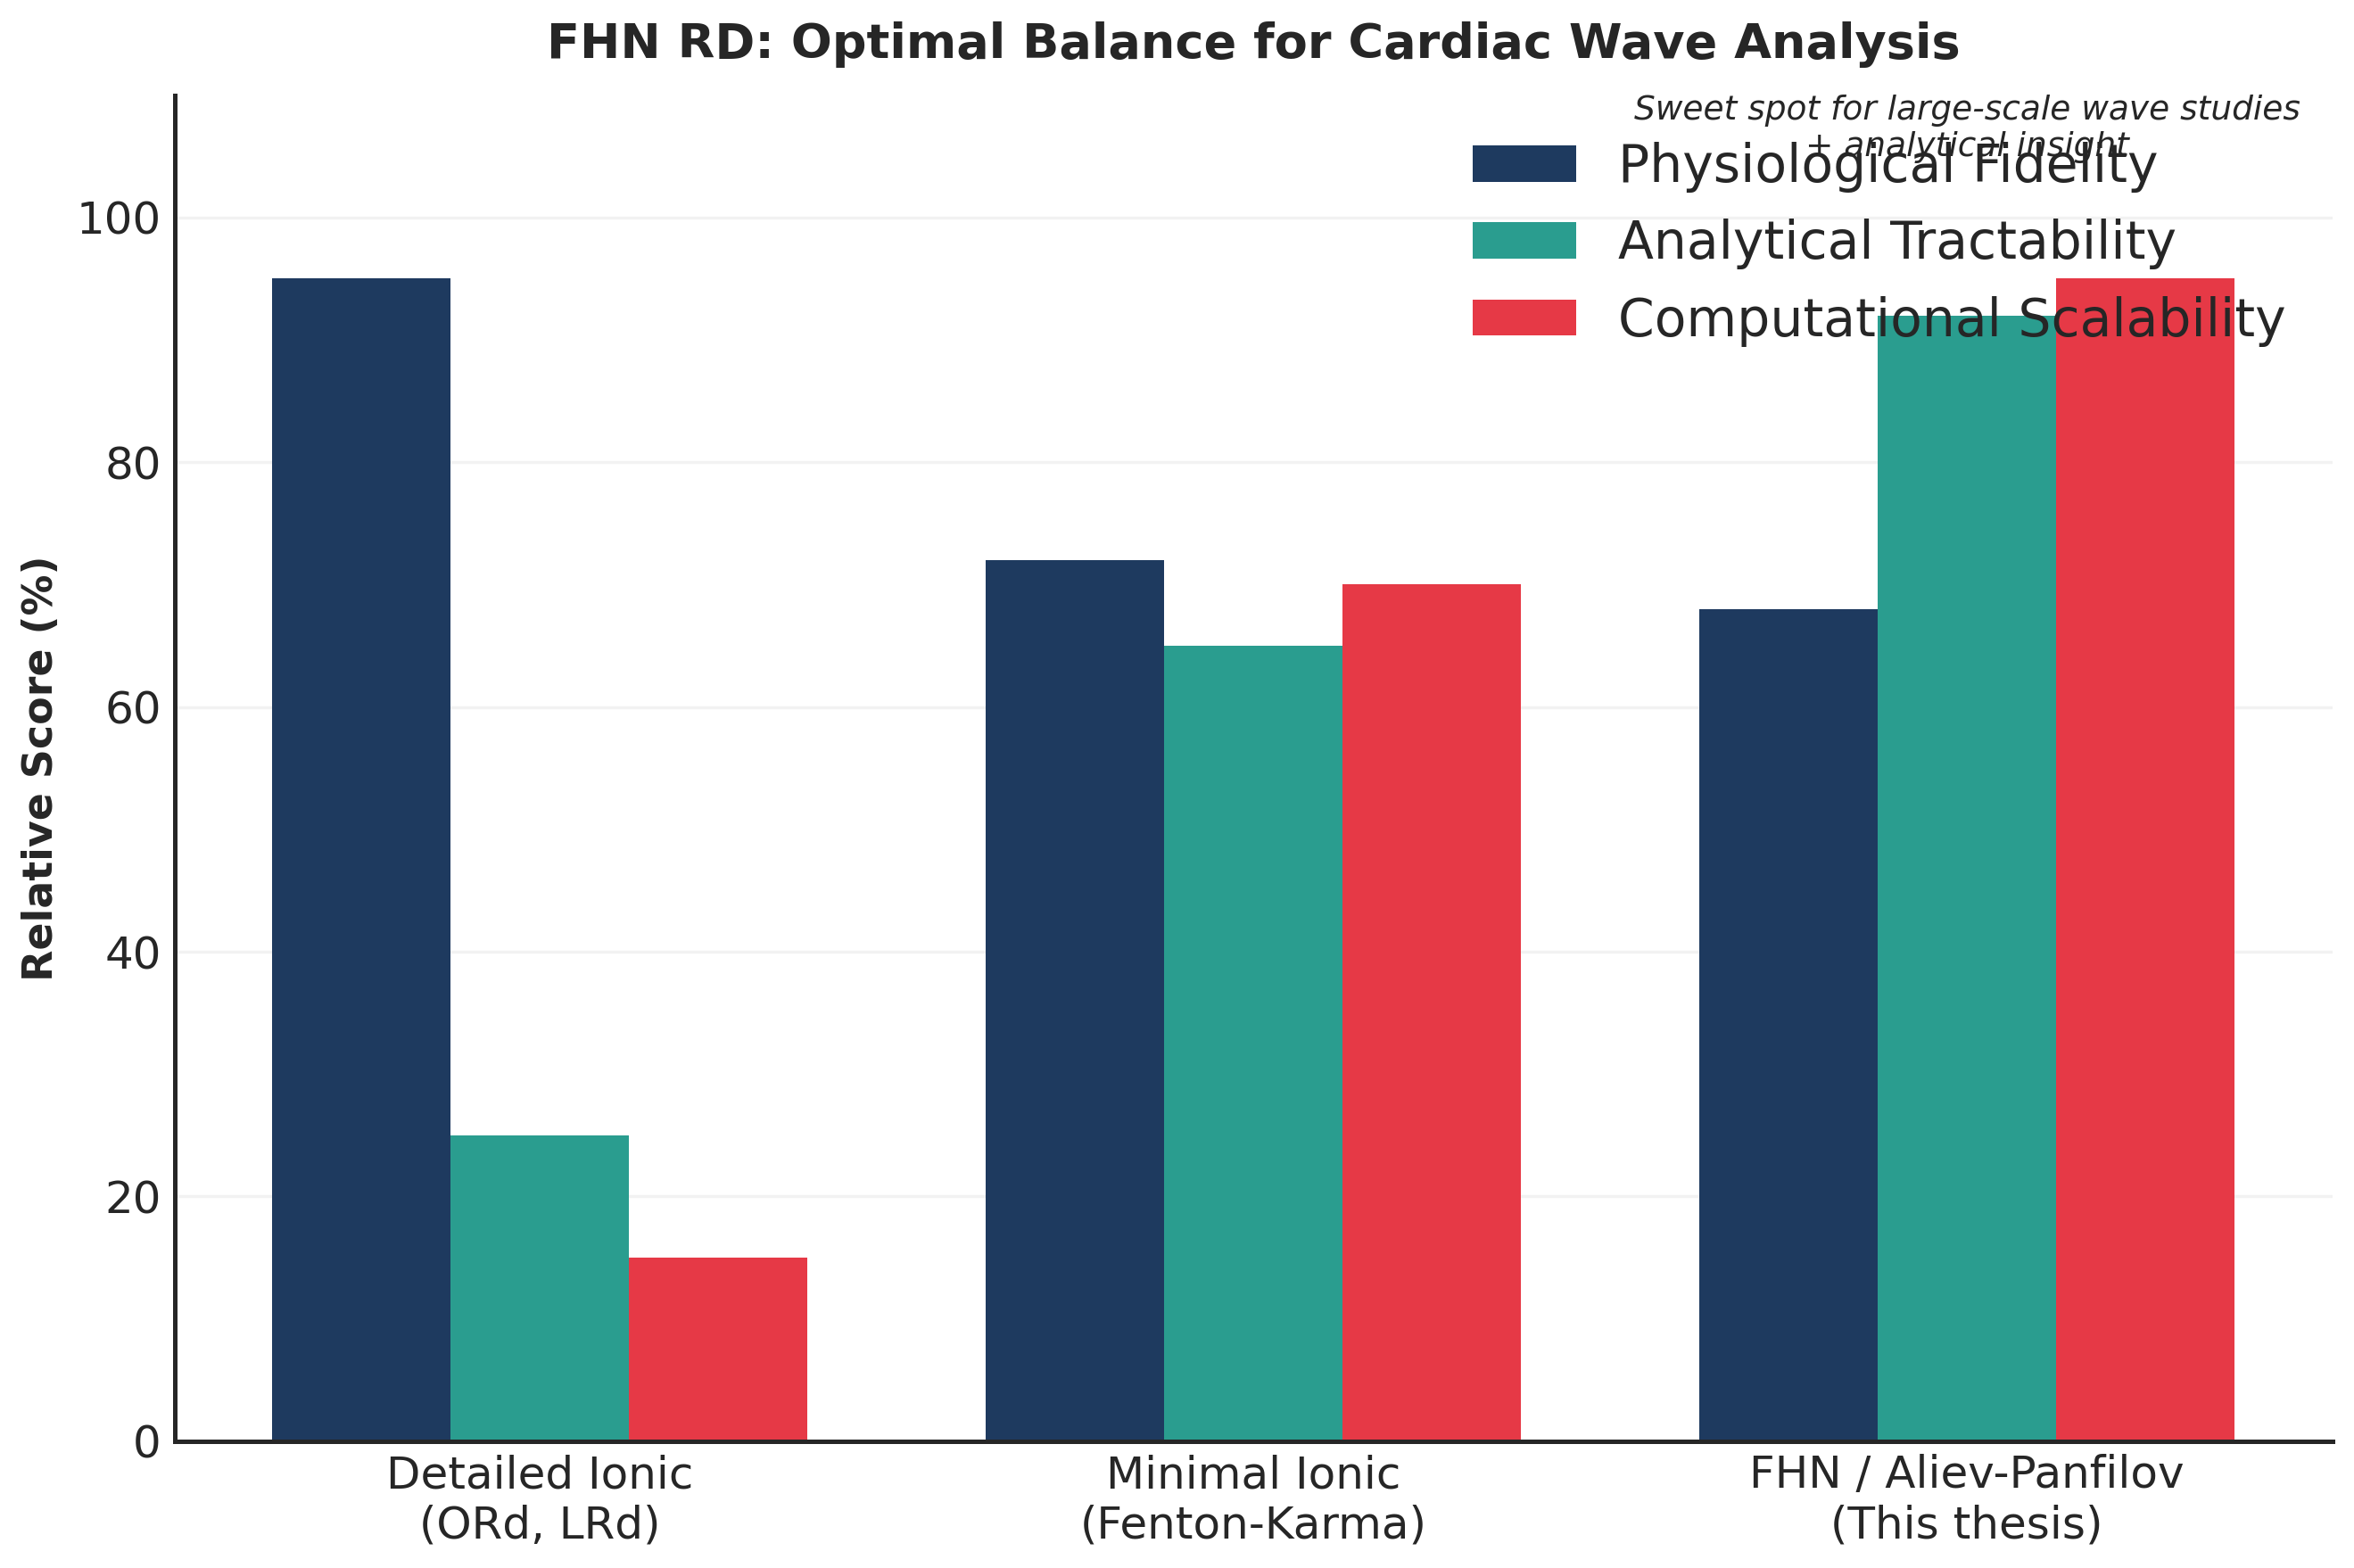

In [36]:
# Figure_5_5_Optimal_Balance.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(9, 6))

categories = ['Detailed Ionic\n(ORd, LRd)', 'Minimal Ionic\n(Fenton-Karma)', 'FHN / Aliev-Panfilov\n(This thesis)']
fidelity = [95, 72, 68]
tractability = [25, 65, 92]
scalability = [15, 70, 95]

x = np.arange(len(categories))
width = 0.25

ax.bar(x - width, fidelity, width, label='Physiological Fidelity', color=cardiac_palette['primary'])
ax.bar(x, tractability, width, label='Analytical Tractability', color=cardiac_palette['accent'])
ax.bar(x + width, scalability, width, label='Computational Scalability', color=cardiac_palette['excited'])

ax.set_ylabel('Relative Score (%)', fontweight='bold')
ax.set_title('FHN RD: Optimal Balance for Cardiac Wave Analysis', fontweight='bold', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(loc='upper right')
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.25, axis='y')

ax.text(2, 105, 'Sweet spot for large-scale wave studies\n+ analytical insight', ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('Figure_5_5_Optimal_Balance.pdf', format='pdf')
print("Figure 5.5 saved.")

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
from math import pi

def set_thesis_style():
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
        'font.size': 10,
        'axes.labelsize': 11,
        'axes.titlesize': 13,
        'figure.titlesize': 14,
        'axes.linewidth': 1.2,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.08,
    })

cardiac_palette = {
    'primary': '#1E3A5F',
    'excited': '#E63946',
    'recovery': '#457B9D',
    'accent': '#2A9D8F',
    'feedback': '#9B5DE5',
    'light': '#F8F9FA',
}

Figure 8.1 saved.


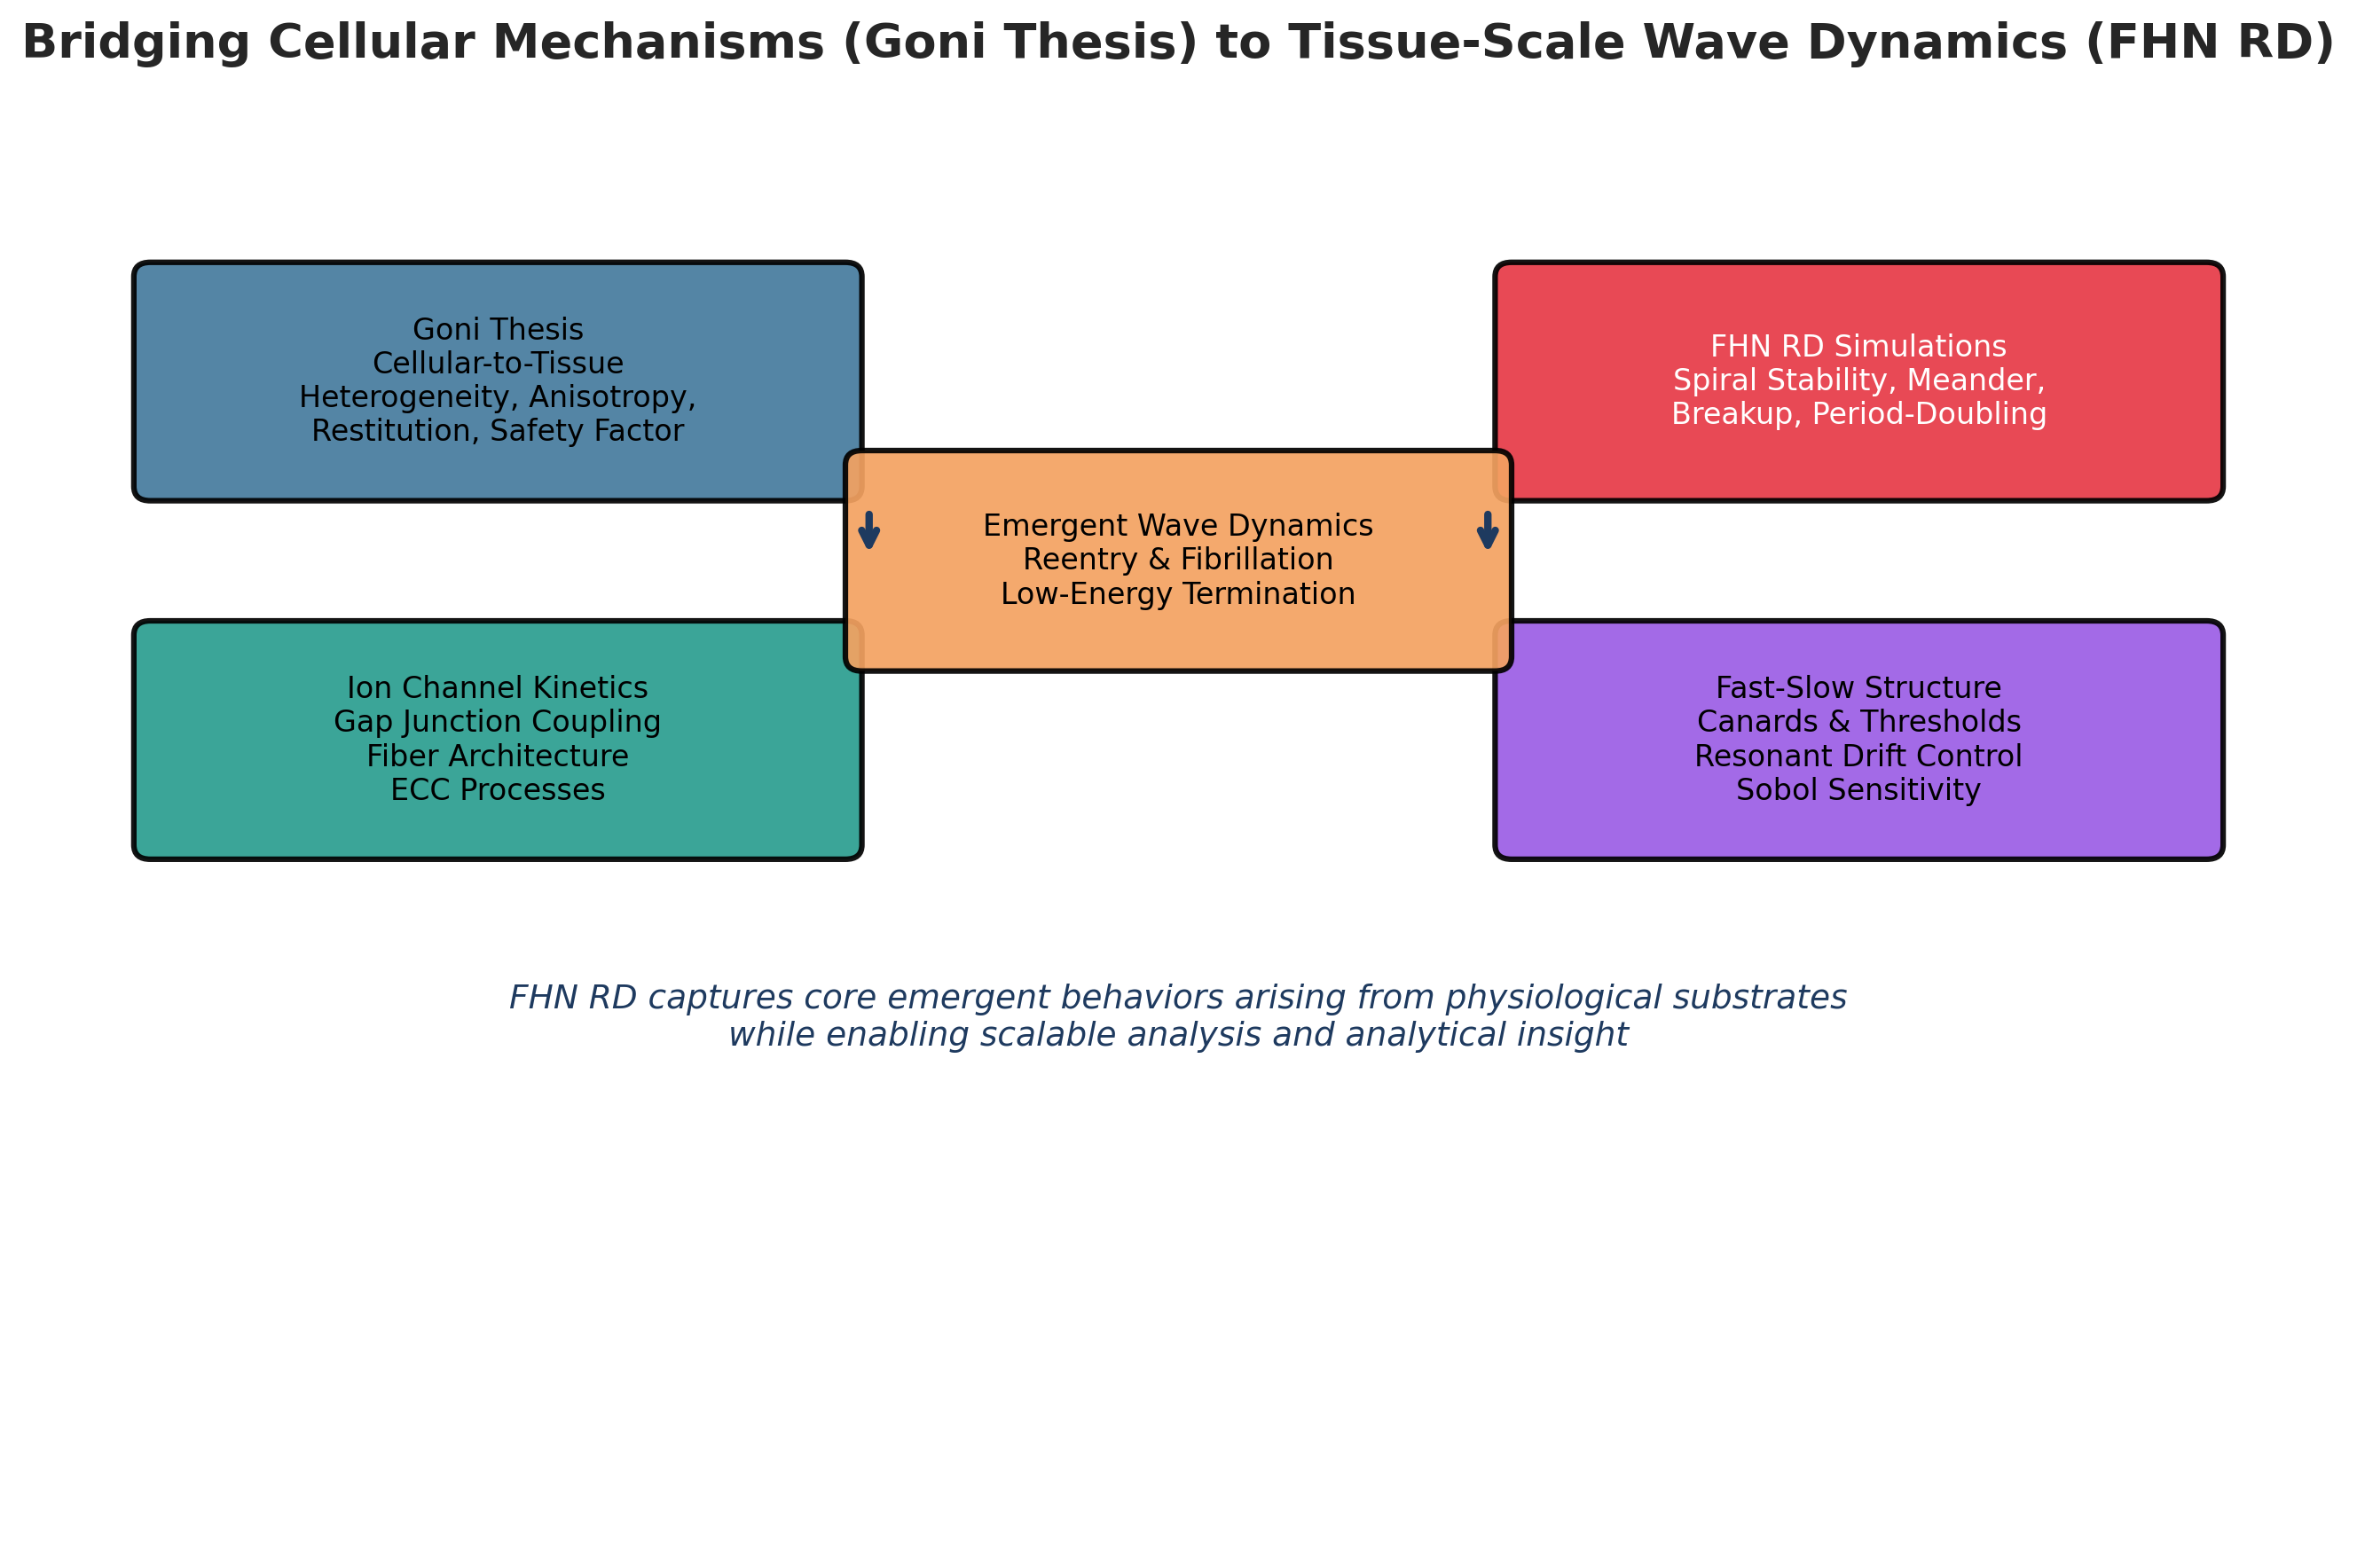

In [38]:
# Figure_8_1_Goni_FHN_Integration.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(11, 7))
ax.set_xlim(0, 11)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('Bridging Cellular Mechanisms (Goni Thesis) to Tissue-Scale Wave Dynamics (FHN RD)',
             fontweight='bold', fontsize=13, pad=15)

def add_box(ax, x, y, w, h, text, color, fontsize=8):
    box = FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle="round,pad=0.015,rounding_size=0.08",
                         facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.92)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, wrap=True,
            color='white' if color in ['#1E3A5F', '#E63946'] else 'black', fontweight='medium')

# Left column (Goni / Physiology)
add_box(ax, 2.2, 6.5, 3.5, 1.3, "Goni Thesis\nCellular-to-Tissue\nHeterogeneity, Anisotropy,\nRestitution, Safety Factor", '#457B9D')
add_box(ax, 2.2, 4.5, 3.5, 1.3, "Ion Channel Kinetics\nGap Junction Coupling\nFiber Architecture\nECC Processes", '#2A9D8F')

# Right column (FHN / This Thesis)
add_box(ax, 8.8, 6.5, 3.5, 1.3, "FHN RD Simulations\nSpiral Stability, Meander,\nBreakup, Period-Doubling", '#E63946')
add_box(ax, 8.8, 4.5, 3.5, 1.3, "Fast-Slow Structure\nCanards & Thresholds\nResonant Drift Control\nSobol Sensitivity", '#9B5DE5')

# Central bridge
add_box(ax, 5.5, 5.5, 3.2, 1.2, "Emergent Wave Dynamics\nReentry & Fibrillation\nLow-Energy Termination", '#F4A261')

# Arrows
ax.annotate('', xy=(4.0, 5.5), xytext=(4.0, 5.8), arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=2))
ax.annotate('', xy=(7.0, 5.5), xytext=(7.0, 5.8), arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=2))

ax.text(5.5, 2.8, 'FHN RD captures core emergent behaviors arising from physiological substrates\nwhile enabling scalable analysis and analytical insight',
        ha='center', fontsize=9, style='italic', color='#1E3A5F')

plt.savefig('Figure_8_1_Goni_FHN_Integration.pdf', format='pdf')
print("Figure 8.1 saved.")

Figure 8.2 saved.


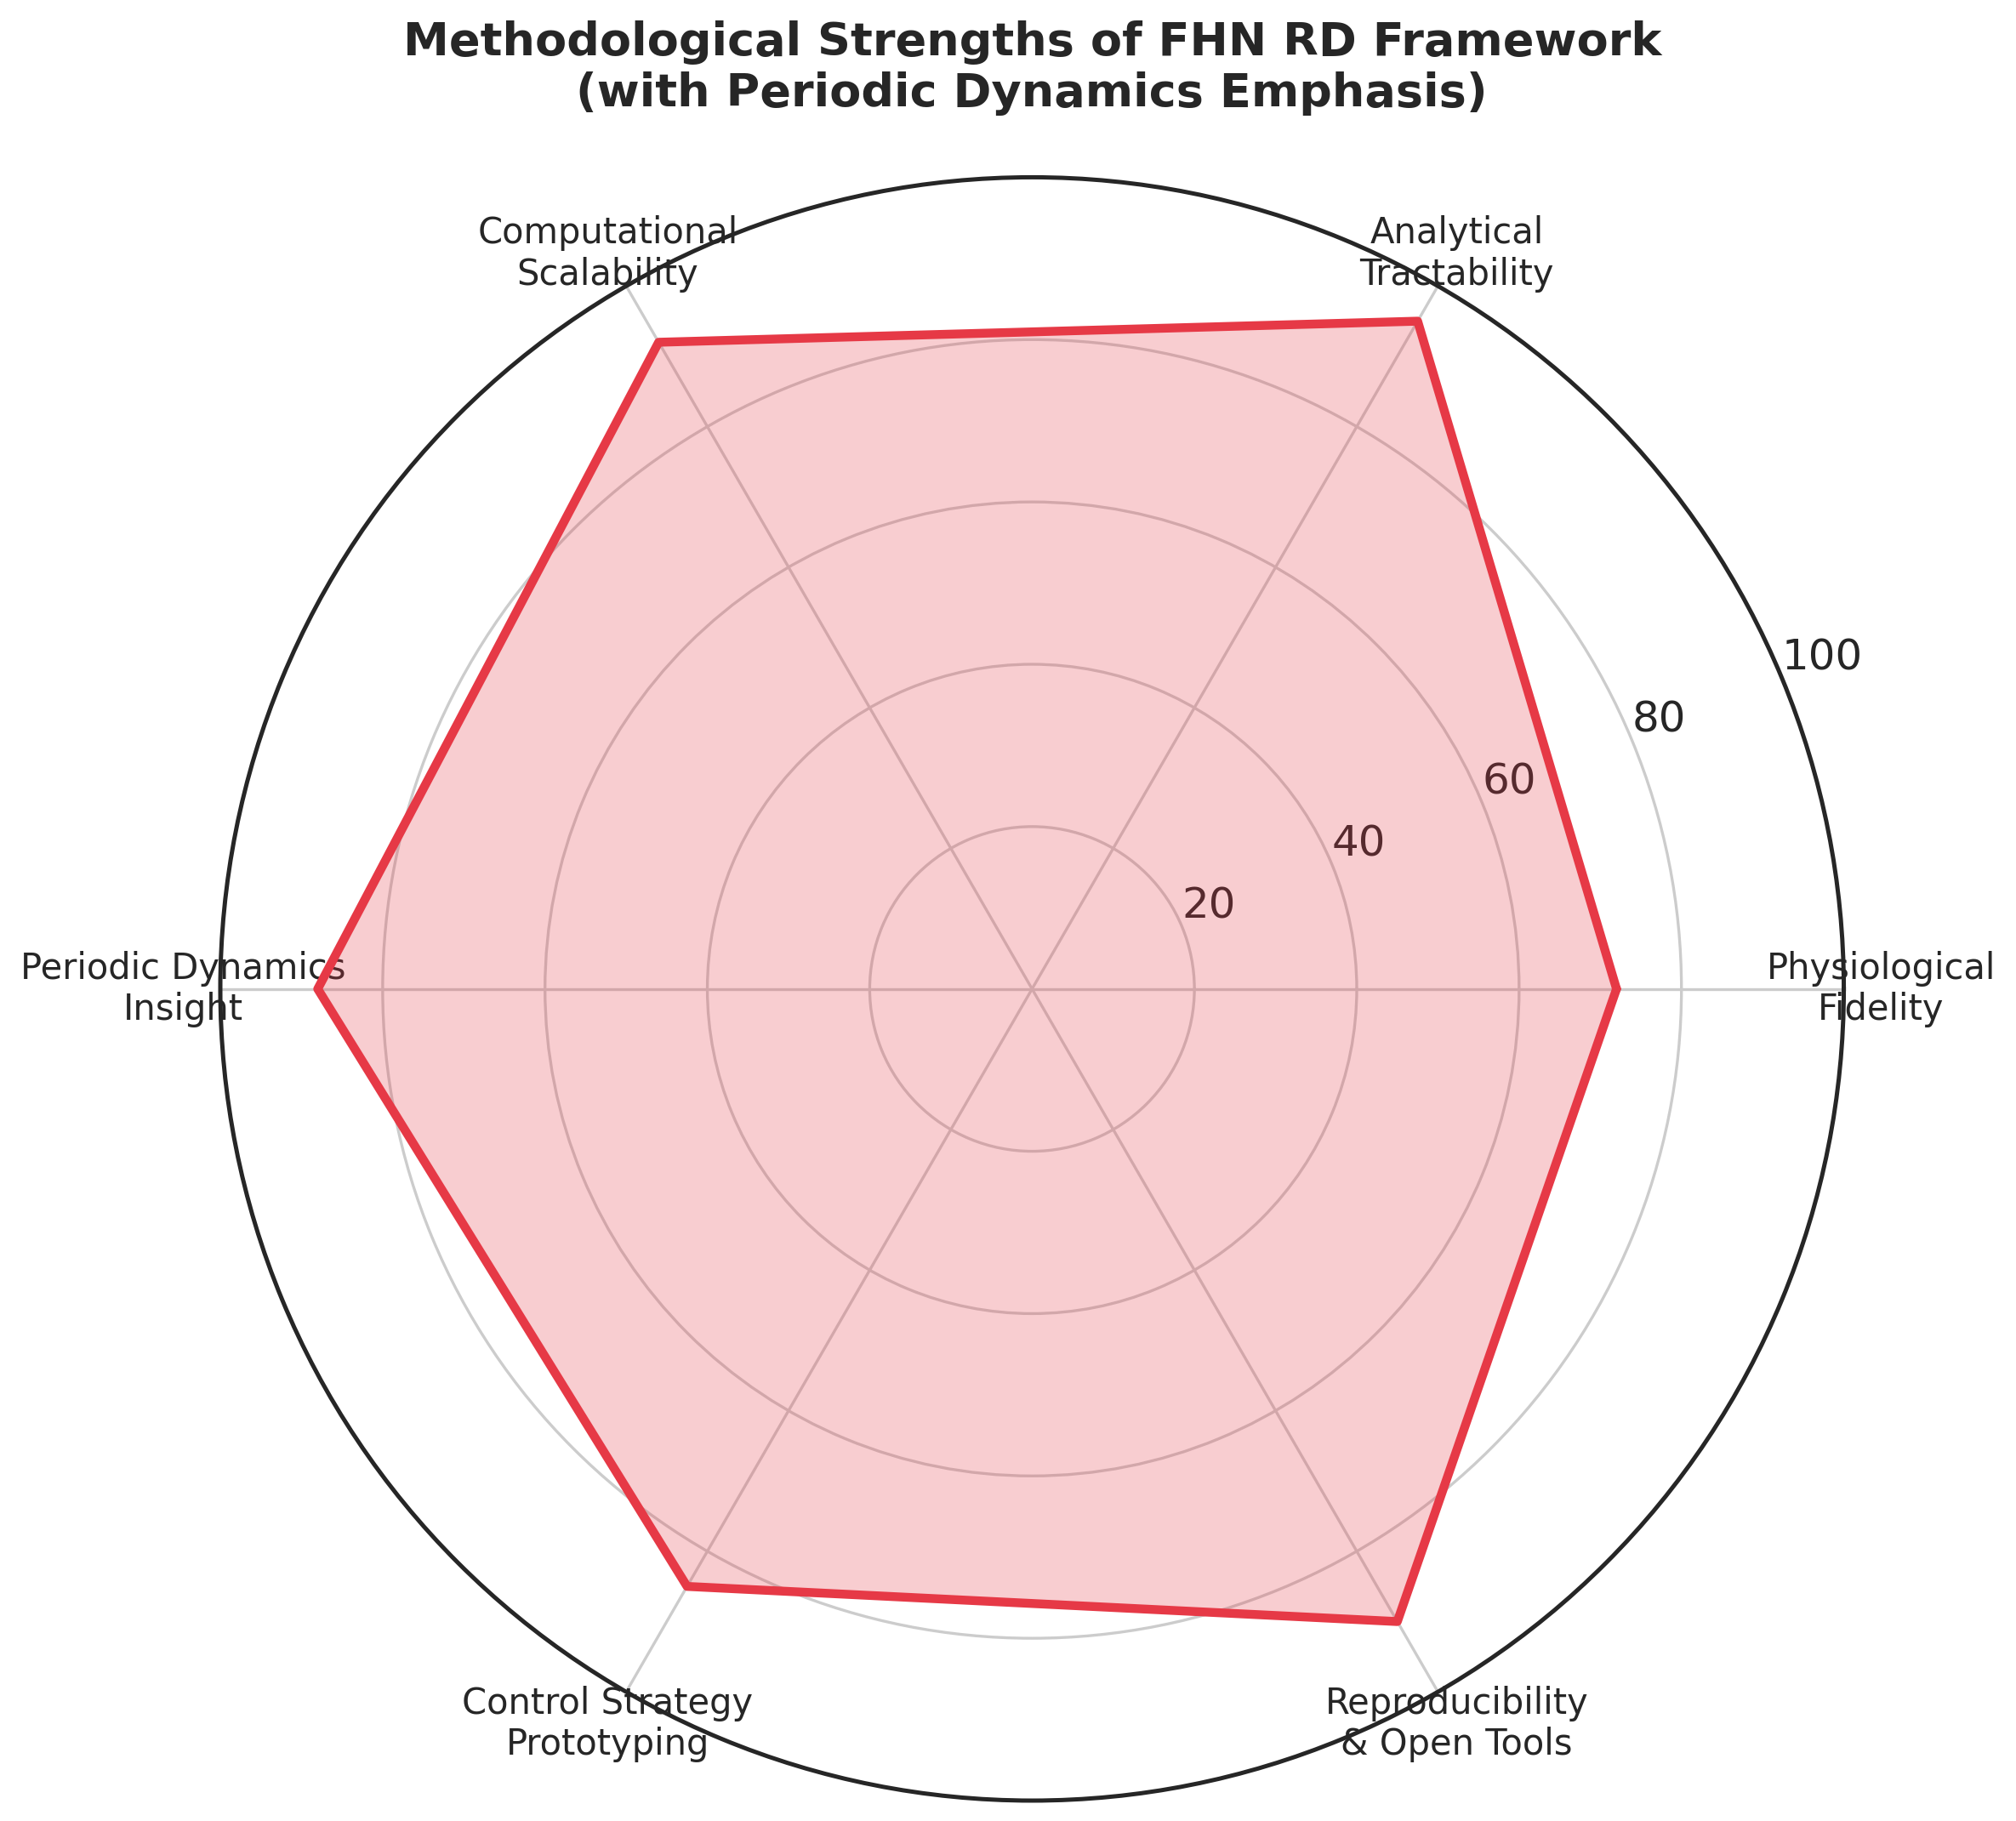

In [39]:
# Figure_8_2_Strengths_Radar.py
set_thesis_style()

categories = ['Physiological\nFidelity', 'Analytical\nTractability', 'Computational\nScalability',
              'Periodic Dynamics\nInsight', 'Control Strategy\nPrototyping', 'Reproducibility\n& Open Tools']
N = len(categories)

values = [72, 95, 92, 88, 85, 90]   # FHN scores (illustrative but realistic)
values += values[:1]

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, values, color=cardiac_palette['excited'], linewidth=2.5)
ax.fill(angles, values, color=cardiac_palette['excited'], alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 100)
ax.set_title('Methodological Strengths of FHN RD Framework\n(with Periodic Dynamics Emphasis)',
             fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('Figure_8_2_Strengths_Radar.pdf', format='pdf')
print("Figure 8.2 saved.")

Figure 8.3 saved.


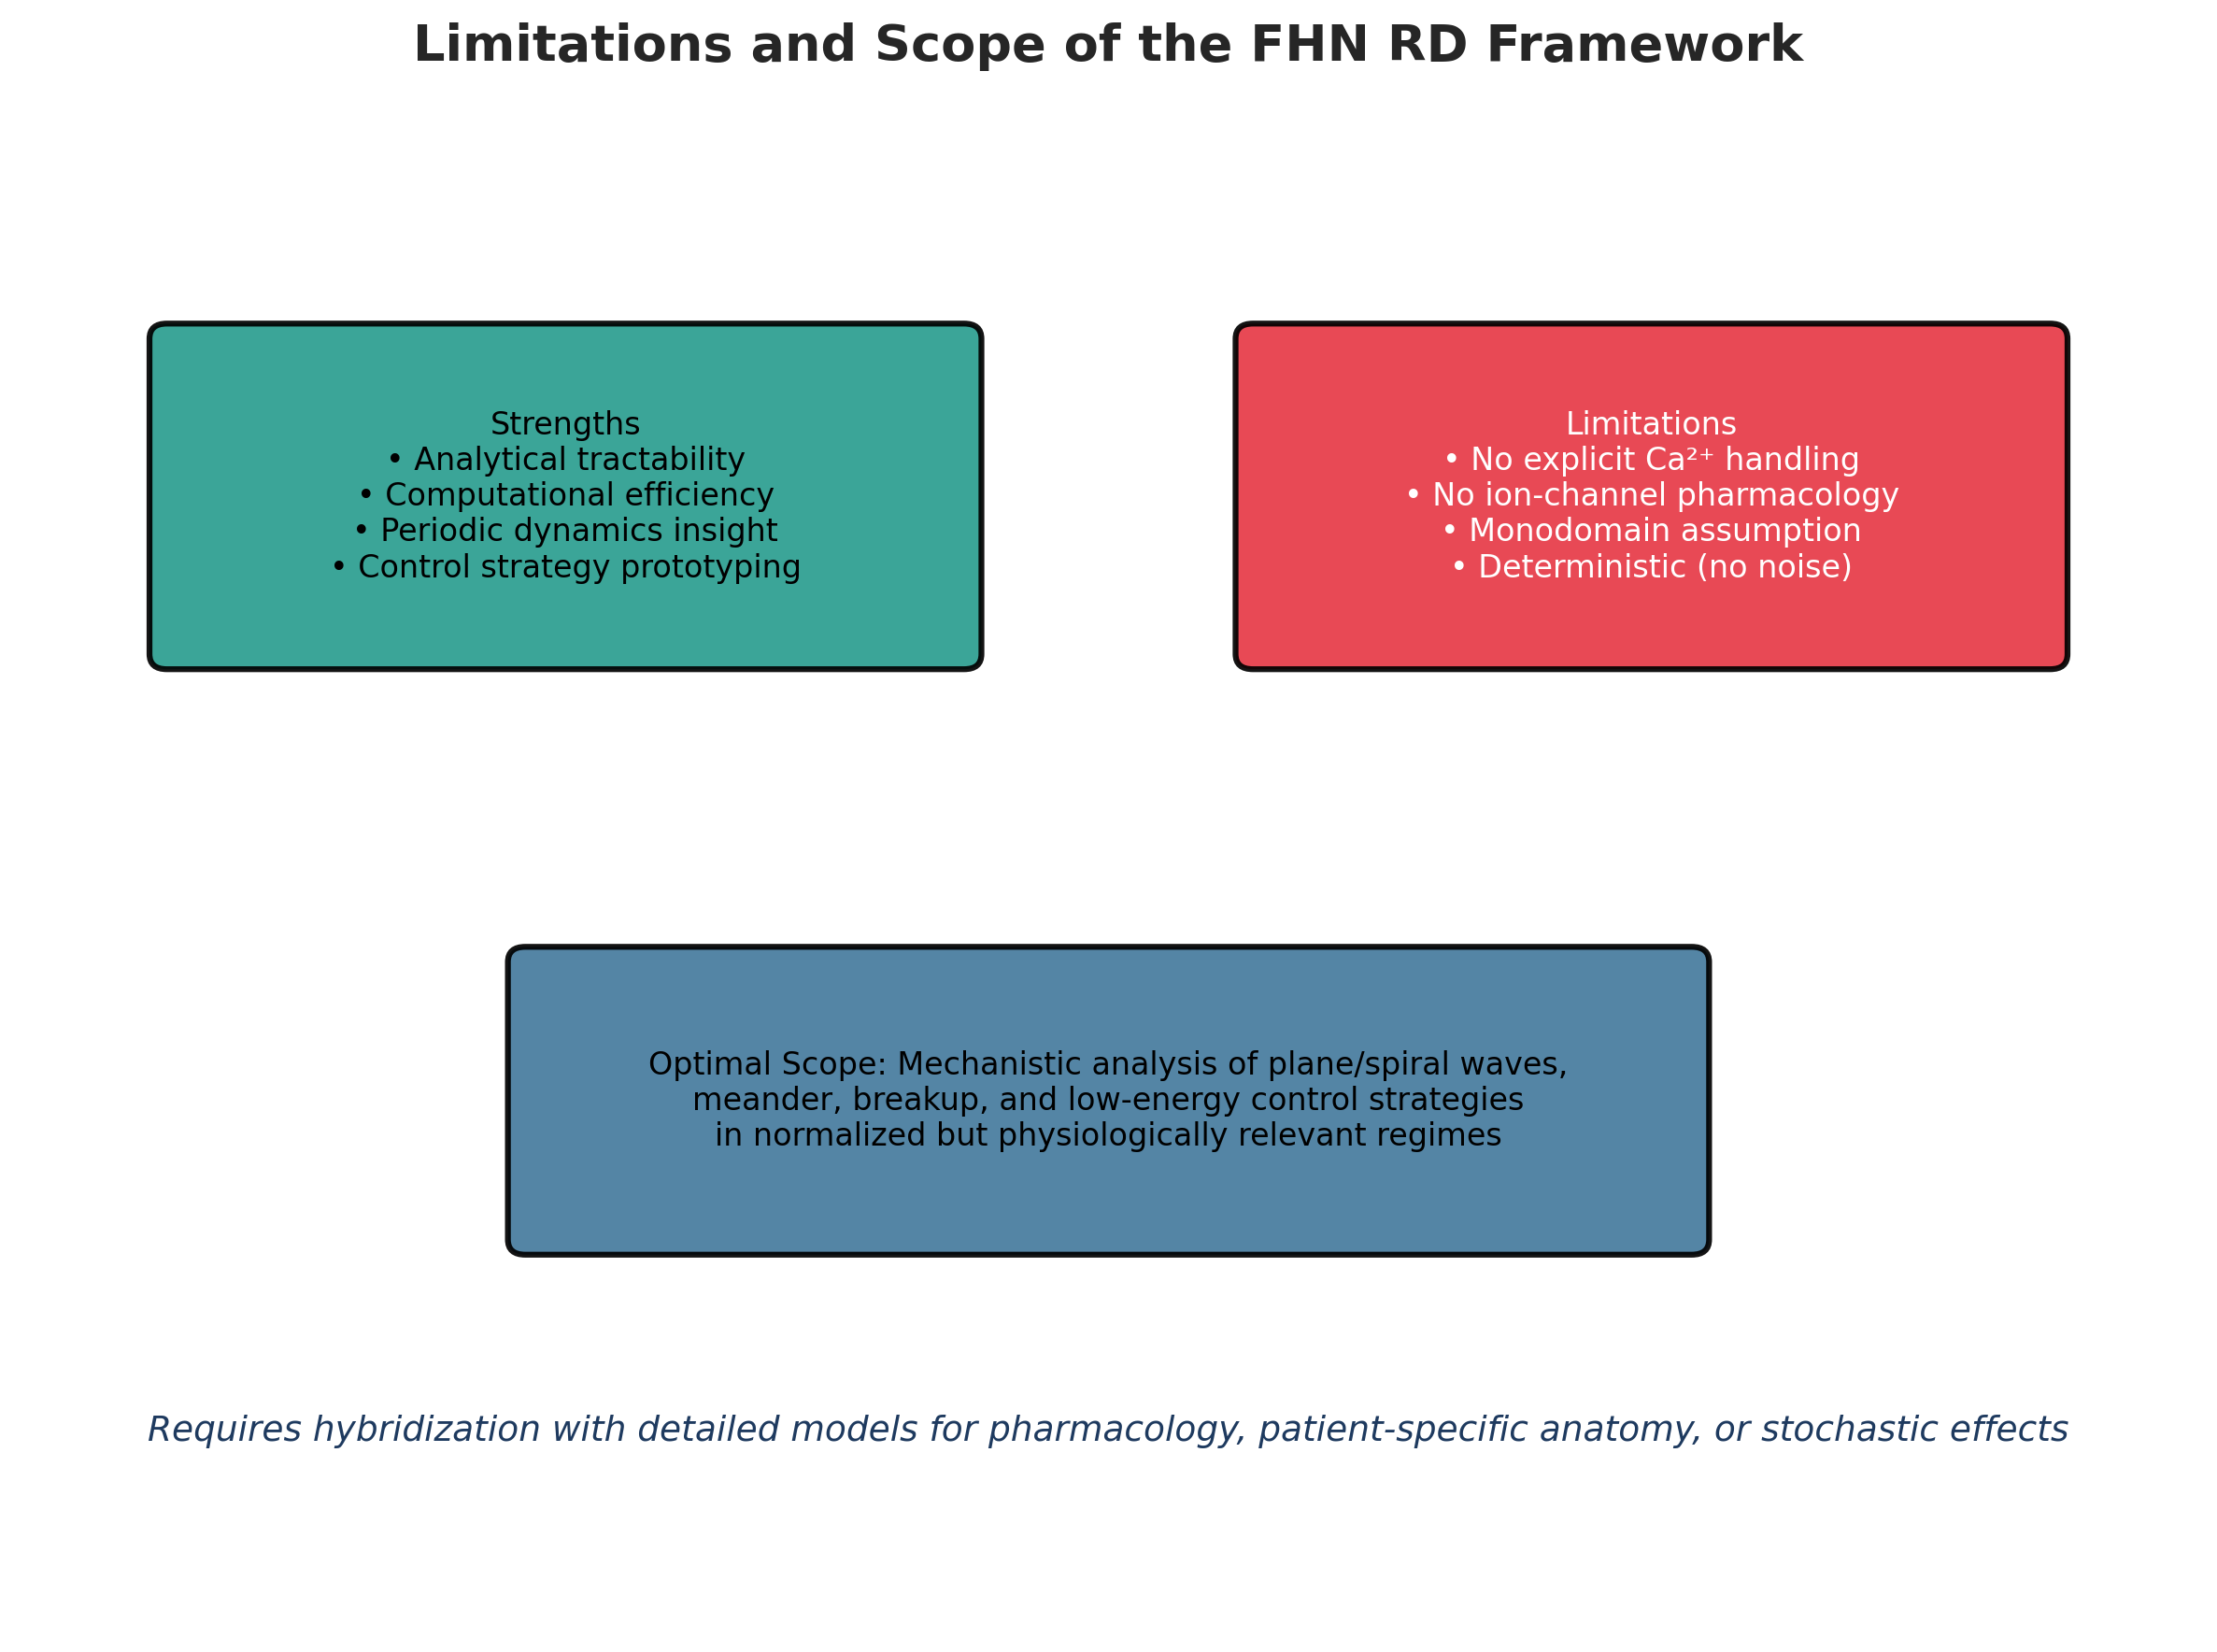

In [40]:
# Figure_8_3_Limitations_Scope.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('Limitations and Scope of the FHN RD Framework', fontweight='bold', pad=15)

def add_box(ax, x, y, w, h, text, color, fontsize=8):
    box = FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle="round,pad=0.015,rounding_size=0.08",
                         facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.92)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, wrap=True,
            color='white' if color in ['#E63946', '#1E3A5F'] else 'black', fontweight='medium')

# Strengths box
add_box(ax, 2.5, 6.0, 3.8, 1.8, "Strengths\n• Analytical tractability\n• Computational efficiency\n• Periodic dynamics insight\n• Control strategy prototyping", '#2A9D8F')

# Limitations box
add_box(ax, 7.5, 6.0, 3.8, 1.8, "Limitations\n• No explicit Ca²⁺ handling\n• No ion-channel pharmacology\n• Monodomain assumption\n• Deterministic (no noise)", '#E63946')

# Scope box
add_box(ax, 5, 2.8, 5.5, 1.6, "Optimal Scope: Mechanistic analysis of plane/spiral waves,\nmeander, breakup, and low-energy control strategies\nin normalized but physiologically relevant regimes", '#457B9D')

ax.text(5, 1.0, 'Requires hybridization with detailed models for pharmacology, patient-specific anatomy, or stochastic effects',
        ha='center', fontsize=9, style='italic', color='#1E3A5F')

plt.savefig('Figure_8_3_Limitations_Scope.pdf', format='pdf')
print("Figure 8.3 saved.")

Figure 8.4 saved.


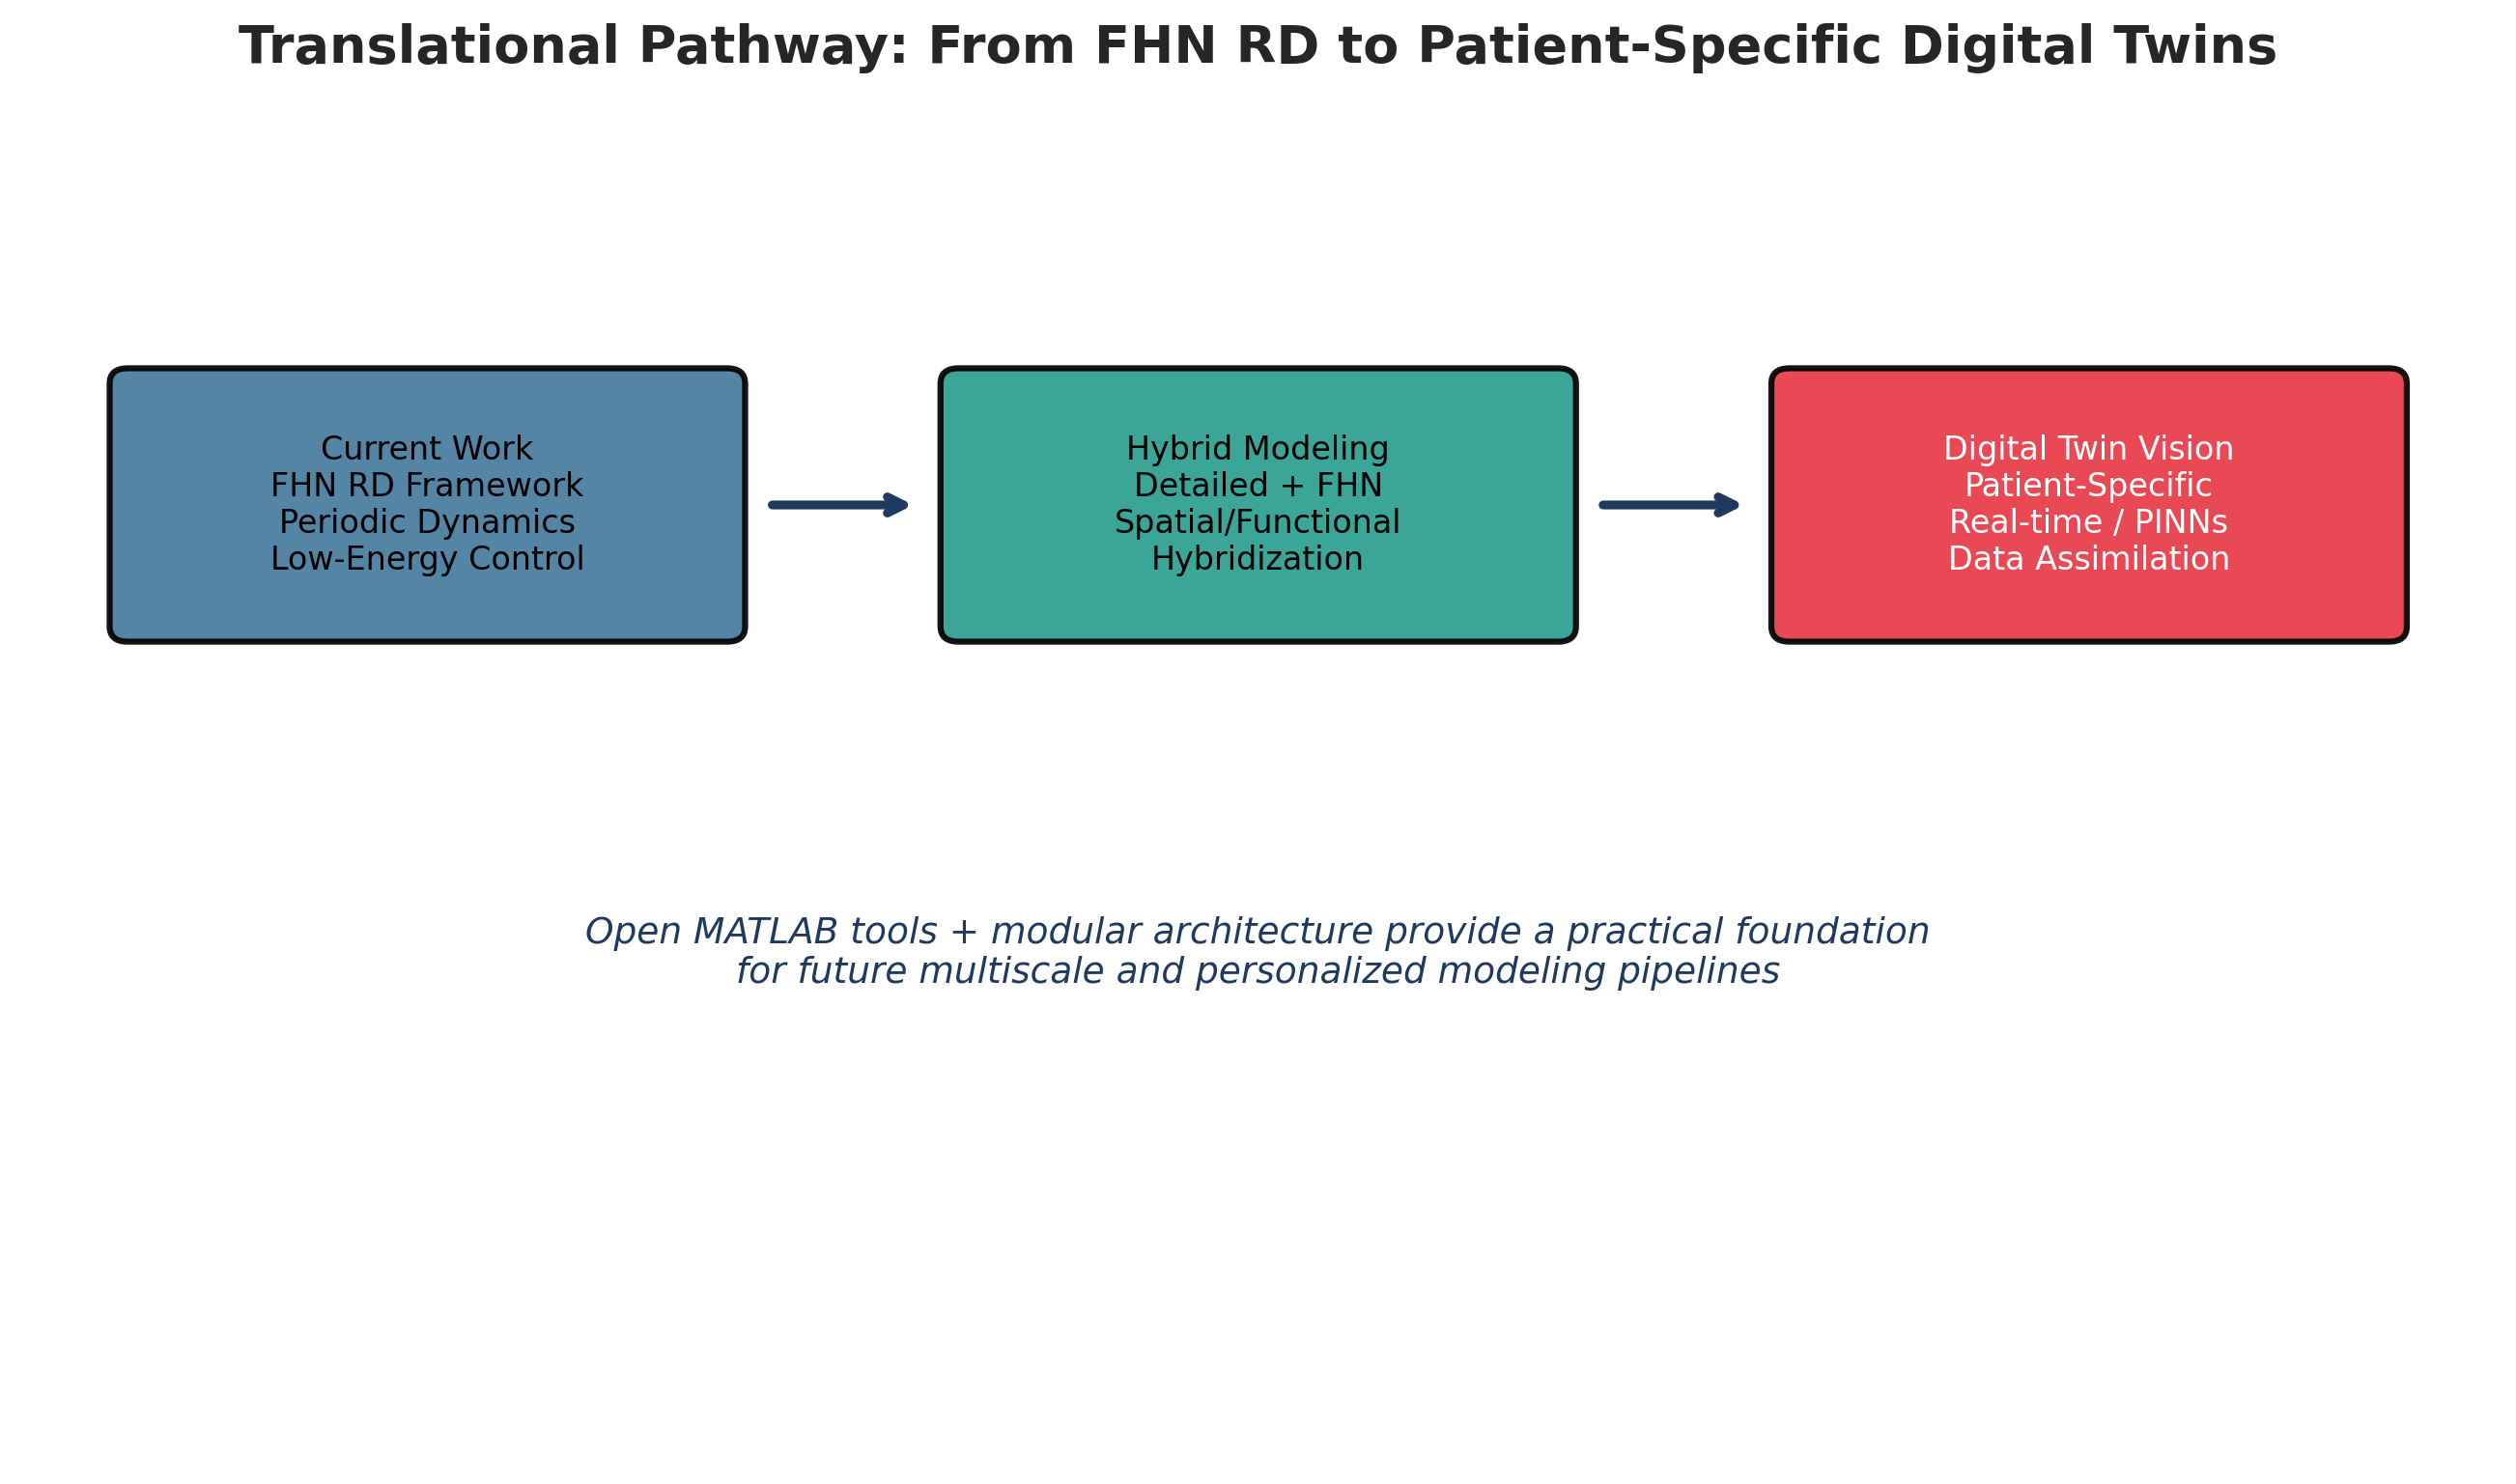

In [41]:
# Figure_8_4_Digital_Twin_Pathway.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, 11)
ax.set_ylim(0, 7)
ax.axis('off')
ax.set_title('Translational Pathway: From FHN RD to Patient-Specific Digital Twins', fontweight='bold', pad=15)

def add_box(ax, x, y, w, h, text, color, fontsize=8):
    box = FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle="round,pad=0.015,rounding_size=0.08",
                         facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.92)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, wrap=True,
            color='white' if color in ['#1E3A5F', '#E63946'] else 'black', fontweight='medium')

add_box(ax, 1.8, 5.0, 2.8, 1.4, "Current Work\nFHN RD Framework\nPeriodic Dynamics\nLow-Energy Control", '#457B9D')
add_box(ax, 5.5, 5.0, 2.8, 1.4, "Hybrid Modeling\nDetailed + FHN\nSpatial/Functional\nHybridization", '#2A9D8F')
add_box(ax, 9.2, 5.0, 2.8, 1.4, "Digital Twin Vision\nPatient-Specific\nReal-time / PINNs\nData Assimilation", '#E63946')

ax.annotate('', xy=(4.0, 5.0), xytext=(3.3, 5.0), arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=2.2))
ax.annotate('', xy=(7.7, 5.0), xytext=(7.0, 5.0), arrowprops=dict(arrowstyle='->', color='#1E3A5F', lw=2.2))

ax.text(5.5, 2.5, 'Open MATLAB tools + modular architecture provide a practical foundation\nfor future multiscale and personalized modeling pipelines',
        ha='center', fontsize=9, style='italic', color='#1E3A5F')

plt.savefig('Figure_8_4_Digital_Twin_Pathway.pdf', format='pdf')
print("Figure 8.4 saved.")

Figure 9.2 saved.


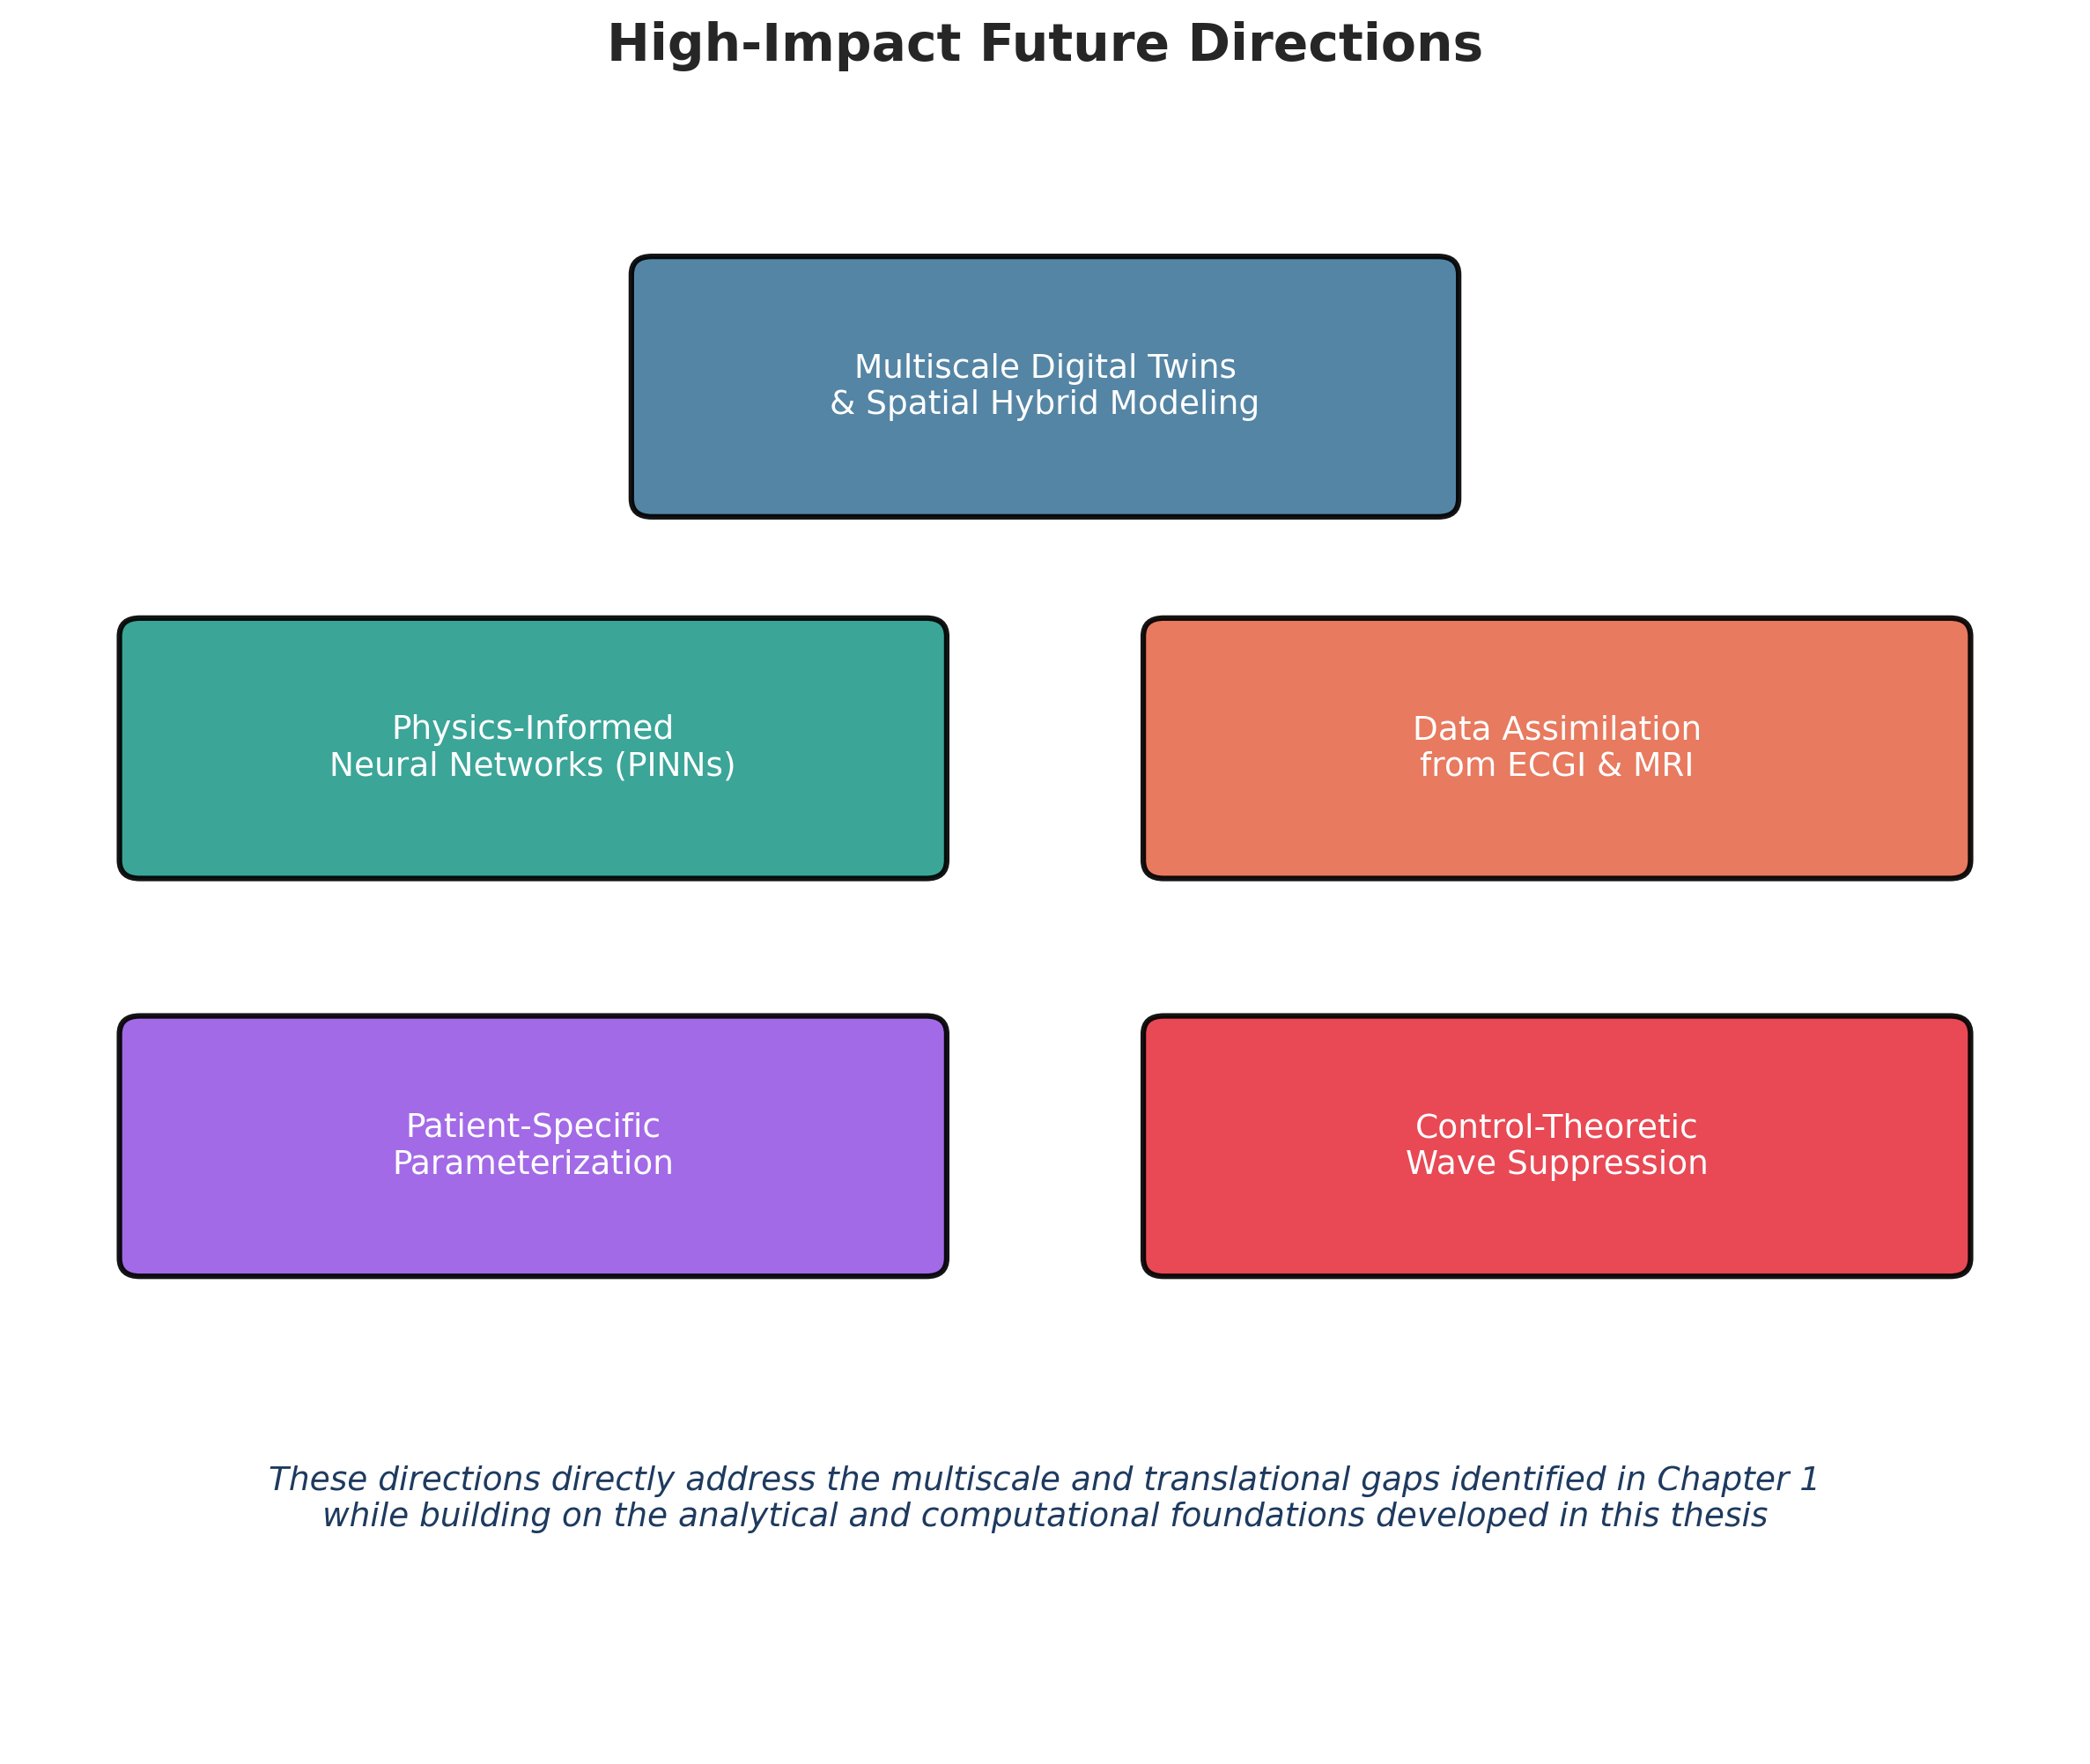

In [42]:
# Figure_9_2_Future_Directions.py
set_thesis_style()
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 9)
ax.axis('off')
ax.set_title('High-Impact Future Directions', fontweight='bold', fontsize=14, pad=15)

directions = [
    (5, 7.5, "Multiscale Digital Twins\n& Spatial Hybrid Modeling", '#457B9D'),
    (2.5, 5.5, "Physics-Informed\nNeural Networks (PINNs)", '#2A9D8F'),
    (7.5, 5.5, "Data Assimilation\nfrom ECGI & MRI", '#E76F51'),
    (2.5, 3.3, "Patient-Specific\nParameterization", '#9B5DE5'),
    (7.5, 3.3, "Control-Theoretic\nWave Suppression", '#E63946'),
]

for x, y, text, color in directions:
    box = FancyBboxPatch((x-2.0, y-0.7), 4.0, 1.4, boxstyle="round,pad=0.02,rounding_size=0.1",
                         facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.92)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=9, color='white', fontweight='medium')

ax.text(5, 1.2, 'These directions directly address the multiscale and translational gaps identified in Chapter 1\nwhile building on the analytical and computational foundations developed in this thesis',
        ha='center', fontsize=9, style='italic', color='#1E3A5F')

plt.savefig('Figure_9_2_Future_Directions.pdf', format='pdf')
print("Figure 9.2 saved.")